```Text
SENTINEL-2 CLASSIFICATION
          ✓
          │
          ▼
Verify all EE + Drive tasks
          │
          ▼
Collect HY2018–HY2025 GeoTIFFs
          │
          ▼
NoData/background correction
          │
          ▼
Annual class-area QC
          │
          ▼
Visual QC: 2018 / middle year / 2025
          │
          ▼
LANDSAT HY2025 PILOT
          │
          ▼
30-m reference sampling + 5-fold CV
          │
          ▼
Compare Landsat HY2025 with S2 HY2025
          │
          ▼
If satisfactory:
Landsat HY2008–HY2025 classification
          │
          ▼
HABITAT DYNAMICS
          │
          ├── extent
          ├── persistence
          ├── transitions
          ├── recurrent vs persistent change
          ├── fragmentation
          └── anthropogenic/climatic drivers

Detailed contemporary classification
--------------------------------------
Sentinel-2 SR Harmonized
10 m
Habitat Year 2025
Possibly extend to HY2018–HY2025


Long-term habitat dynamics
--------------------------
Landsat Collection 2 Level-2 SR
Landsat 5 + 7 + 8 + 9
30 m
Habitat Years 2008–2025


Recent-period sensitivity analysis
----------------------------------
NASA HLS L30 + S30
30 m
Recent overlap years only
Optional

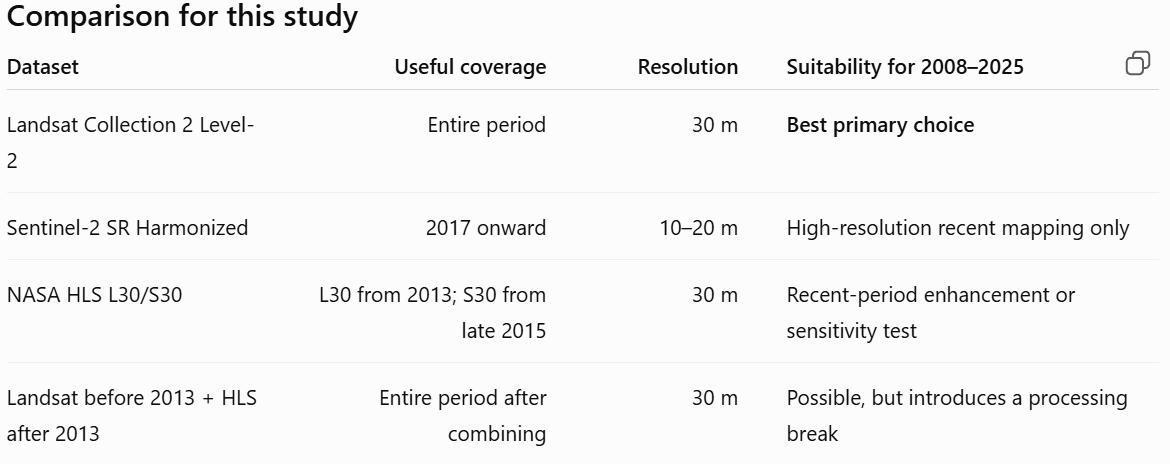

```Text
Eleven classes versus broader change classes

The Landsat model can initially predict all 11 classes, but the long-term change analysis should not assume that every class can be mapped equally reliably at 30 m.

I recommend retaining the complete legend for annual map production while using broader ecological groups for the primary trend analysis, such as:

Natural steppe:
Grass steppe
Shrub steppe
Wooded steppe
Salty steppe

Rocky/bare:
Bare rocky
Dune

Hydrological/alluvial:
Wadi and gullies
Spreading area
Water body

Anthropogenic:
Cultivated/fallow
Built-up

# 3rd Edition — Habitat Classification Workflow (S2 based) — Eastern Morocco
- Created on 9/10/2026
- Previous version was avilable at `Habitat mapping demo v1.ipynb`

- Finnal decision on dataset selections: **Landsat Collection 2 Level-2 surface reflectance as the primary**
- ```Text
    Because the 2008–2025 period is the priority, the most defensible design is:
    
    Use Landsat Collection 2 Level-2 surface reflectance as the primary, internally consistent 30 m dataset for the complete annual habitat series. Keep Sentinel-2 as the high-resolution contemporary product, and use HLS only as an optional recent-period sensitivity analysis.
    
    This gives the study two complementary products:
    
    Sentinel-2, 10 m: detailed Habitat Year 2025 classification and potentially recent maps from about 2018 onward.
    Landsat, 30 m: the complete and temporally consistent Habitat Year 2008–2025 series for persistence, transitions, fragmentation, and driver analysis.
    
    That is preferable to trying to splice together several products into one nominally continuous series.

    

## Overview

This notebook develops a **Random Forest habitat-classification model for Eastern Morocco** using *the finalized training dataset, multi-season Sentinel-2 imagery, terrain variables, and selected ancillary layers*.

**Habitat Year 2025 = September 2024–August 2025**, covering the full autumn–winter–spring vegetation cycle rather than relying on a single March composite.

---

## 1. Training Data

All training data were cleaned, harmonized, merged, and finalized in:

`Habitat Mapping_Preprocessing.ipynb`

Final dataset:

```text
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\
Vegetation Cover and Food Availability Studies\
Eastern_Morocco_Training_Final_2025.gpkg
```

Model-ready layer:

```text
training_final
```

Target 11-type habitat classes include:

* Grass steppe
* Shrub steppe
* Wooded steppe
* Salty steppe
* Spreading area
* Rocky area
* Dune
* Wadi & gullies
* Cultivated/fallow
* Open water
* Built-up

---

## 2. Remote-Sensing Predictors

### Sentinel-2

Use:

```text
COPERNICUS/S2_SR_HARMONIZED
```

Habitat Year 2025:

```text
2024-09-01 → 2025-08-31
```

Generate four seasonal composites:

* Autumn: Sep–Nov 2024
* Winter: Dec 2024–Feb 2025
* Spring: Mar–May 2025
* Summer: Jun–Aug 2025

Cloud and shadow masking will be applied before compositing.

### Spectral predictors

Core bands:

```text
B2, B3, B4, B8, B5, B6, B7, B8A, B11, B12
```

Indices:

```text
EVI
MSAVI
NDWI
BSI
```

Seasonal band names will be retained, for example:

```text
aut_NDVI
win_NDVI
spr_NDVI
sum_NDVI
```

Optional annual metrics may include NDVI maximum, minimum, amplitude, and variability.

---

## 3. Terrain and Ancillary Predictors

Use **Copernicus DEM GLO-30** to derive:

* Elevation
* Slope
* Northness
* Eastness
* Optional TRI / TPI

Additional predictors may include:

* Anthropized areas
* Waterways
* Buildings
* Populated areas
* Distance to anthropogenic or hydrological features

These layers will initially be treated as predictors rather than hard classification rules.

---

## 4. Predictor Stack

Combine:

```text
6 Sentinel-2 bands: B2 B3 B4 B8 B11 B12
4 indices:          EVI MSAVI NDWI BSI
4 terrain:          Elevation Slope Northness Eastness
--------------------------------------------------------
Total:              14 predictors
```

All predictor names and masks will be checked before sampling.

---

## 5. Training and Validation Sampling

Training and testing polygons will be separated **before pixel sampling** to avoid spatial data leakage.

Initial split:

```text
70% training
30% testing
```

or an 80/20 split if required for rare classes.

Sampling will be balanced so that very large polygons or common habitat classes do not dominate the RF model.

---

## 6. Random Forest Classification

Use:

```text
ee.Classifier.smileRandomForest
Number of trees: 500
Target field: class_id
```

Evaluate using the independent testing dataset:

* Confusion matrix
* Overall accuracy
* Kappa
* Producer's accuracy
* User's accuracy
* Precision / Recall / F1 by class
* Variable importance

Optional spatial-block validation will also be considered.

---

## 7. Final Classification

Once model performance is satisfactory:

1. Apply the RF classifier to Eastern Morocco.
2. Generate the **10 m Habitat Year 2025 map**.
3. Produce classification-confidence / probability information where possible.
4. Inspect major classification errors spatially.

---

## 8. Post-Processing

Post-processing will be conservative.

Possible refinements include:

* Persistent-water correction
* Built-up correction
* Small majority/focal-mode filter

A generic vegetation mask will **not** be applied because sparse vegetation and bare substrate are important habitat characteristics.

Both outputs will be retained:

```text
Raw RF classification
Final post-processed classification
```

---

## 9. Outputs

Primary outputs:

* Habitat Year 2025 classification
* Classification-confidence map
* Accuracy metrics
* Confusion matrix
* Per-class F1 scores
* Variable importance
* Habitat area statistics
* Bouarfa and Al Baten subsets

---

## 10. Multi-Year Extension

After validating the 2025 model, the same workflow can be applied to earlier habitat years:

```text
Habitat Year YYYY
=
September YYYY-1 → August YYYY
```

The seasonal definitions, predictor bands, preprocessing, classification approach, and output resolution should remain consistent across years.

This will support subsequent analysis of:

* Habitat persistence
* Habitat transitions
* Habitat gain/loss
* Fragmentation
* Long-term habitat change

---

## Notes

* Analysis will use the **Google Earth Engine Python API in JupyterLab**.
* Local processing will use the `python-gis-2026` Conda environment.
* Training/testing separation occurs before raster sampling.
* Predictor-band names must remain identical between training and classification.
* Multi-season Sentinel-2 information is preferred over a single-date composite.
* The Habitat Year 2025 model will be validated before extending classification to other years.


```Text
HY2025 training polygons
        ↓
17,175 fixed points
Eastern_Morocco_RF_Points_HY2025
        ↓
extract HY2025 predictor values ONCE
        ↓
local CSV/table
        ↓
5-fold polygon CV + tuning locally
        ↓
train final classifier once
        ↓
apply same classifier to annual predictor stacks
        ↓
annual habitat maps


LOCAL PYTHON
------------
sample table
5-fold CV
RF tuning
accuracy tables
confusion matrices
per-class metrics
variable importance


GOOGLE EARTH ENGINE
-------------------
annual satellite composites
annual predictor stacks
final RF training
wall-to-wall classification
GeoTIFF export
EE asset export

                         ONE-TIME
                         ========

RF_POINTS_HY2025
       ↓
HY2025 predictor extraction
       ↓
local CSV ──────────────→ local 5-fold CV
       ↓                         ↓
small GEE sample asset       accuracy tables
       ↓
500-tree classifier
       ↓
classifier asset


                       REPEATED BY YEAR
                       ================

satellite imagery HY20XX
       ↓
predictor stack HY20XX
       +
saved classifier asset
       ↓
habitat map HY20XX
       ↓
Drive GeoTIFF + EE Asset

```Text
python sentinel2_annual_habitat_classification_final.py
python landsat_annual_habitat_classification_final.py

# Benchmark in HY 2025

In [2]:
# ============================================================
# 0. Imports and configuration
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import ee
import geemap

print("GeoPandas:", gpd.__version__)
print("Earth Engine:", ee.__version__)
print("geemap:", geemap.__version__)

GeoPandas: 1.1.4
Earth Engine: 1.7.43
geemap: 0.38.4


### Pre-work for uploading the traning data to Asset

In [18]:
# ============================================================
# 1. Load final training dataset
# ============================================================
TRAINING_GPKG = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco"
    r"\Vegetation Cover and Food Availability Studies"
    r"\Eastern_Morocco_Training_Final_2025.gpkg"
)

TRAINING_LAYER = "training_final"

if not TRAINING_GPKG.exists():
    raise FileNotFoundError(f"Training dataset not found:\n{TRAINING_GPKG}")

gdf = gpd.read_file(
    TRAINING_GPKG,
    layer=TRAINING_LAYER
)

print("Training dataset loaded successfully.")
print("Number of features:", len(gdf))
print("CRS:", gdf.crs)
print("Geometry types:")
print(gdf.geom_type.value_counts())

print("\nColumns:")
print(gdf.columns.tolist())

Training dataset loaded successfully.
Number of features: 3435
CRS: EPSG:32630
Geometry types:
Polygon         3417
MultiPolygon      18
Name: count, dtype: int64

Columns:
['sample_id', 'site_id', 'source_id', 'class_raw', 'class', 'class_id', 'source', 'ref_year', 'field_sup', 'confidence', 'geom_rule', 'grid_id', 'source_qc_status', 'source_use_status', 'qc_status', 'use_status', 'poly_area', 'conflict_flag', 'geometry']


In [19]:
# ------------------------------------------------------------
# Basic QA
# ------------------------------------------------------------

if CLASS_FIELD not in gdf.columns:
    raise ValueError(f"'{CLASS_FIELD}' not found in training dataset.")

# Ensure class_id is integer
gdf[CLASS_FIELD] = pd.to_numeric(
    gdf[CLASS_FIELD],
    errors="raise"
).astype(int)

print("Missing geometries:", gdf.geometry.isna().sum())
print("Empty geometries:", gdf.geometry.is_empty.sum())
print("Invalid geometries:", (~gdf.geometry.is_valid).sum())
print("Missing class IDs:", gdf[CLASS_FIELD].isna().sum())

print("\nClass distribution:")
display(
    gdf[CLASS_FIELD]
    .value_counts()
    .sort_index()
    .rename("n_features")
    .to_frame()
)

Missing geometries: 0
Empty geometries: 0
Invalid geometries: 0
Missing class IDs: 0

Class distribution:


,n_features
class_id,
0,552
1,400
2,14
3,568
4,183
5,28
6,52
7,461
8,1031


In [20]:
print("Geometry types:")
print(gdf_ee.geom_type.value_counts())

print("\nNull:", gdf_ee.geometry.isna().sum())
print("Empty:", gdf_ee.geometry.is_empty.sum())
print("Invalid:", (~gdf_ee.geometry.is_valid).sum())

Geometry types:
Polygon         3417
MultiPolygon      18
Name: count, dtype: int64

Null: 0
Empty: 0
Invalid: 0


In [21]:
# 2. Find exactly which features Earth Engine rejects
import json

geojson = json.loads(gdf_ee.to_json(drop_id=True))

bad_features = []

for i, feature in enumerate(geojson["features"]):
    try:
        ee.Geometry(feature["geometry"])
    except Exception as e:
        bad_features.append({
            "row": i,
            "feature_id": feature["properties"].get("feature_id"),
            "class_id": feature["properties"].get("class_id"),
            "geom_type": (
                feature["geometry"].get("type")
                if feature["geometry"] is not None
                else None
            ),
            "error": str(e)
        })

print("EE-incompatible geometries:", len(bad_features))

pd.DataFrame(bad_features).head(20)

EE-incompatible geometries: 153


,row,feature_id,class_id,geom_type,error
0,1409,1409,8,Polygon,Invalid GeoJSON geometry.
1,1410,1410,8,Polygon,Invalid GeoJSON geometry.
2,1411,1411,8,Polygon,Invalid GeoJSON geometry.
3,1412,1412,8,Polygon,Invalid GeoJSON geometry.
4,1413,1413,8,Polygon,Invalid GeoJSON geometry.
5,1414,1414,8,Polygon,Invalid GeoJSON geometry.
6,1415,1415,8,Polygon,Invalid GeoJSON geometry.
7,1416,1416,8,Polygon,Invalid GeoJSON geometry.
8,1417,1417,8,Polygon,Invalid GeoJSON geometry.
9,1418,1418,8,Polygon,Invalid GeoJSON geometry.


In [ ]:
# 3. Clean the geometries robustly
from shapely import make_valid, force_2d
from shapely.geometry import MultiPolygon


def keep_polygonal_geometry(geom):
    """
    Repair geometry and retain only Polygon/MultiPolygon components.
    """

    if geom is None or geom.is_empty:
        return None

    # Remove Z coordinates if present
    geom = force_2d(geom)

    # Repair invalid geometries
    if not geom.is_valid:
        geom = make_valid(geom)

    if geom.is_empty:
        return None

    # Polygon
    if geom.geom_type == "Polygon":
        return geom

    # MultiPolygon
    if geom.geom_type == "MultiPolygon":
        return geom

    # make_valid() can generate GeometryCollection
    if geom.geom_type == "GeometryCollection":
        polygons = []

        for part in geom.geoms:
            if part.geom_type == "Polygon":
                polygons.append(part)

            elif part.geom_type == "MultiPolygon":
                polygons.extend(list(part.geoms))

        if len(polygons) == 1:
            return polygons[0]

        elif len(polygons) > 1:
            return MultiPolygon(polygons)

    return None

In [22]:
gdf_ee_clean = gdf_ee.copy()

gdf_ee_clean["geometry"] = (
    gdf_ee_clean.geometry
    .apply(keep_polygonal_geometry)
)

# Remove geometries that could not be retained
gdf_ee_clean = gdf_ee_clean[
    gdf_ee_clean.geometry.notna()
].copy()

gdf_ee_clean = gdf_ee_clean[
    ~gdf_ee_clean.geometry.is_empty
].copy()

gdf_ee_clean = gdf_ee_clean.reset_index(drop=True)

In [23]:
# Check again:
print("Original features:", len(gdf_ee))
print("Clean features:", len(gdf_ee_clean))

print("\nGeometry types:")
print(gdf_ee_clean.geom_type.value_counts())

print("\nInvalid geometries:",
      (~gdf_ee_clean.geometry.is_valid).sum())


Original features: 3435
Clean features: 3435

Geometry types:
Polygon         3417
MultiPolygon      18
Name: count, dtype: int64

Invalid geometries: 0


In [17]:
# Export the clearned traning GPKG to shp and upload to GEE Assets
from pathlib import Path
import geopandas as gpd
import numpy as np

OUT_DIR = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco"
    r"\Vegetation Cover and Food Availability Studies"
    r"\GEE_Training_2025"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)

out_shp = OUT_DIR / "Eastern_Morocco_Training_Final_2025.shp"

# Use the cleaned polygons
training_upload = gdf_ee_clean.copy()

# Keep only essential model fields
training_upload = training_upload[
    ["feature_id", "class_id", "geometry"]
].copy()

# Earth Engine recommends EPSG:4326
training_upload = training_upload.to_crs("EPSG:4326")

training_upload.to_file(out_shp)

print("Saved:", out_shp)
print("Features:", len(training_upload))

Saved: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\Vegetation Cover and Food Availability Studies\GEE_Training_2025\Eastern_Morocco_Training_Final_2025.shp
Features: 3435


## Main GEE code

In [6]:
import numpy as np
import pandas as pd

import ee
import geemap

# ============================================================
# Initialize Google Earth Engine
# ============================================================
# ee.Authenticate() #Only needs to run in first-run, and after that all set!
ee.Initialize(project='rse-global-wetlands') # this is the esential step!
print("Earth Engine authenticated and initialized.")

Earth Engine authenticated and initialized.


In [25]:
# ------------------------------------------------------------
# Project configuration
# ------------------------------------------------------------
import numpy as np
import pandas as pd

import ee
import geemap

TRAINING_ASSET = ("projects/rse-global-wetlands/assets/Eastern_Morocco_Training_Final_2025")
CLASS_FIELD = "class_id"
FEATURE_ID_FIELD = "feature_id"

training_fc = ee.FeatureCollection(TRAINING_ASSET)

print(
    "Earth Engine training features:",
    training_fc.size().getInfo()
)


# Habitat Year 2025
START_DATE = "2024-09-01"
END_DATE   = "2025-09-01"   # exclusive end date in GEE

# Sentinel-2 predictors
S2_BANDS = [
    "B2",   # Blue
    "B3",   # Green
    "B4",   # Red
    "B8",   # NIR
    "B11",  # SWIR1
    "B12",  # SWIR2
]

INDEX_BANDS = [
    "EVI",
    "MSAVI",
    "NDWI",
    "BSI",
]

TERRAIN_BANDS = [
    "Elevation",
    "Slope",
    "Northness",
    "Eastness",
]

PREDICTOR_BANDS = S2_BANDS + INDEX_BANDS + TERRAIN_BANDS

# Analysis parameters
SCALE = 10
CLEAR_THRESHOLD = 0.60 #Cloud Score+ with cs_cdf >= 0.60; Google currently notes that roughly 0.50–0.65 is generally useful
RANDOM_SEED = 42

print("Number of predictors:", len(PREDICTOR_BANDS))
print(PREDICTOR_BANDS)

Earth Engine training features: 3435
Number of predictors: 14
['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'EVI', 'MSAVI', 'NDWI', 'BSI', 'Elevation', 'Slope', 'Northness', 'Eastness']


### First stage with image and feature preparation

In [26]:
# ============================================================
# 1. Load final training FeatureCollection
# ============================================================

training_fc = ee.FeatureCollection(TRAINING_ASSET)

n_features = training_fc.size().getInfo()

print("Training asset loaded successfully.")
print("Number of training features:", n_features)
print("Asset:", TRAINING_ASSET)

Training asset loaded successfully.
Number of training features: 3435
Asset: projects/rse-global-wetlands/assets/Eastern_Morocco_Training_Final_2025


In [27]:
# ------------------------------------------------------------
# Inspect properties
# ------------------------------------------------------------

properties = (
    ee.Feature(training_fc.first())
    .propertyNames()
    .getInfo()
)

print("Properties:")
print(properties)

# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

class_counts = (
    training_fc
    .aggregate_histogram(CLASS_FIELD)
    .getInfo()
)

class_counts = dict(
    sorted(
        class_counts.items(),
        key=lambda x: int(x[0])
    )
)

print("Class distribution:")

for class_id, n in class_counts.items():
    print(f"Class {class_id}: {n}")

Properties:
['feature_id', 'system:index', 'class_id']
Class distribution:
Class 0: 552
Class 1: 400
Class 2: 14
Class 3: 568
Class 4: 183
Class 5: 28
Class 6: 52
Class 7: 461
Class 8: 1031
Class 9: 39
Class 10: 107


```text
The main concern is class imbalance. Classes 2, 5, and 9 have only 14, 28, and 39 polygons, while class 8 has 1,031. So I would definitely use the 70/30 polygon-level split, not 80/20, and make the split explicitly within each class rather than applying one global random threshold.

For example, class 2 will only have about 4 independent test polygons even with 70/30, so its class-specific accuracy will need to be interpreted cautiously.

In [29]:
# 3. Confirm class_id is numeric
sample_class = (
    ee.Feature(training_fc.first())
    .get(CLASS_FIELD)
    .getInfo()
)

print("Example class_id:", sample_class)
print("Python type:", type(sample_class))

Example class_id: 0
Python type: <class 'int'>


In [28]:
# ============================================================
# 4. Define development ROI
# ============================================================

training_geometry = training_fc.geometry()

roi = (
    training_geometry
    .bounds(maxError=100)
    .buffer(5000) #5 km around the training extent.
)

print("Development ROI created.")

Development ROI created.


In [30]:
# ============================================================
# 5. Sentinel-2 Habitat Year 2025
# ============================================================

S2_COLLECTION = "COPERNICUS/S2_SR_HARMONIZED"

CLOUD_COLLECTION = (
    "GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED"
)

QA_BAND = "cs_cdf"


# Sentinel-2
s2 = (
    ee.ImageCollection(S2_COLLECTION)
    .filterBounds(roi)
    .filterDate(START_DATE, END_DATE)
    .filter(
        ee.Filter.lt(
            "CLOUDY_PIXEL_PERCENTAGE",
            80
        )
    )
)


# Cloud Score+
# Cloud Score+ provides cs and cs_cdf scores from 0–1 and shares system:index with Sentinel-2, 
# specifically allowing this collection-linking approach. 
# Google suggests roughly 0.50–0.65 as a useful masking range, so our starting value of 0.60 is reasonable.
cloud_score = (
    ee.ImageCollection(CLOUD_COLLECTION)
    .filterBounds(roi)
    .filterDate(START_DATE, END_DATE)
)


# Link Cloud Score+ to Sentinel-2
s2_linked = s2.linkCollection(
    cloud_score,
    [QA_BAND]
)


print(
    "Sentinel-2 scenes:",
    s2_linked.size().getInfo()
)

Sentinel-2 scenes: 1737


In [31]:
# ============================================================
# 6. Sentinel-2 preprocessing
# ============================================================

def prepare_s2(image):

    # Cloud Score+ mask
    clear_mask = (
        image
        .select(QA_BAND)
        .gte(CLEAR_THRESHOLD)
    )

    # Scene Classification Layer
    scl = image.select("SCL")

    # Remove:
    # 0  = No data
    # 1  = Saturated / defective
    # 3  = Cloud shadow
    # 8  = Medium probability cloud
    # 9  = High probability cloud
    # 10 = Cirrus
    # 11 = Snow / ice

    scl_mask = (
        scl.neq(0)
        .And(scl.neq(1))
        .And(scl.neq(3))
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
        .And(scl.neq(11))
    )

    # Convert Sentinel-2 DN to reflectance
    reflectance = (
        image
        .select(S2_BANDS)
        .multiply(0.0001)
        .updateMask(clear_mask)
        .updateMask(scl_mask)
    )

    return reflectance.copyProperties(
        image,
        ["system:time_start"]
    )

In [32]:
s2_clean = s2_linked.map(prepare_s2)

print(
    "Clean collection size:",
    s2_clean.size().getInfo()
)

Clean collection size: 1737


In [33]:
# Create our single Habitat-Year 2025 median composite:
s2_composite = (
    s2_clean
    .median()
    .clip(roi)
)

print(
    "Composite bands:",
    s2_composite.bandNames().getInfo()
)

Composite bands: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']


In [34]:
# ============================================================
# 7. Spectral indices
# ============================================================

blue = s2_composite.select("B2")
green = s2_composite.select("B3")
red = s2_composite.select("B4")
nir = s2_composite.select("B8")
swir1 = s2_composite.select("B11")


# ------------------------------------------------------------
# EVI
# ------------------------------------------------------------

evi = (
    s2_composite.expression(
        """
        2.5 * ((NIR - RED) /
        (NIR + 6.0 * RED - 7.5 * BLUE + 1.0))
        """,
        {
            "NIR": nir,
            "RED": red,
            "BLUE": blue,
        }
    )
    .rename("EVI")
)


# ------------------------------------------------------------
# MSAVI
# ------------------------------------------------------------

msavi_term = nir.multiply(2).add(1)

msavi_discriminant = (
    msavi_term
    .pow(2)
    .subtract(
        nir.subtract(red).multiply(8)
    )
    .max(0)
)

msavi = (
    msavi_term
    .subtract(
        msavi_discriminant.sqrt()
    )
    .divide(2)
    .rename("MSAVI")
)


# ------------------------------------------------------------
# NDWI
# Green - NIR formulation
# ------------------------------------------------------------

ndwi = (
    s2_composite
    .normalizedDifference(["B3", "B8"])
    .rename("NDWI")
)


# ------------------------------------------------------------
# Bare Soil Index
# ------------------------------------------------------------

bsi = (
    s2_composite.expression(
        """
        ((SWIR + RED) - (NIR + BLUE)) /
        ((SWIR + RED) + (NIR + BLUE))
        """,
        {
            "SWIR": swir1,
            "RED": red,
            "NIR": nir,
            "BLUE": blue,
        }
    )
    .rename("BSI")
)


spectral_stack = (
    s2_composite
    .addBands(evi)
    .addBands(msavi)
    .addBands(ndwi)
    .addBands(bsi)
)

### Terrian datasets:
- Terrain source
--------------
Copernicus DEM GLO-30 2024_1

- Predictors
----------
Elevation
Slope
Northness
Eastness


 Here is the link visulized compare different Elevation datasets: `https://samapriya.users.earthengine.app/view/glob-elevation`
```text
Here are a few options for the DEM/DSM:
 1. awesome-gee-community-catalog: Copernicus Digital Elevation Model (GLO-30 DEM)
 2. FABDEM (Forest And Buildings removed Copernicus 30m DEM)


Hypothesis:
    FABDEM would perform better than the standard Copernicus GLO-30 for the terrain predictors.

The key distinction is conceptual:
Dataset	Represents	Relevance here
Copernicus GLO-30	DSM — terrain + vegetation + buildings	Excellent global DEM, but not purely terrain
FABDEM	Approximate DTM — Copernicus GLO-30 with forest/building height biases removed	Better matches the geomorphology we want

Let's test and compare
    Terrain source:
    FABDEM V1.2 (~30 m)
    
    Predictors:
    Elevation
    Slope
    Northness
    Eastness

In [ ]:
'projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area'
'projects/rse-global-wetlands/assets/Al_Baten_study_area'
'projects/rse-global-wetlands/assets/Bouarfa_study_area'

In [36]:
# ============================================================
# DEM comparison configuration
# ============================================================

REGION_ASSETS = {
    "Eastern Morocco":"projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area",
    "Bouarfa":"projects/rse-global-wetlands/assets/Bouarfa_study_area",
    "Al Baten":"projects/rse-global-wetlands/assets/Al_Baten_study_area",
}

TRAINING_ASSET = ("projects/rse-global-wetlands/assets/""Eastern_Morocco_Training_Final_2025")
GLO30_ASSET = "COPERNICUS/DEM/GLO30_2024_1"
FABDEM_ASSET = ("projects/sat-io/open-datasets/FABDEM")

DEM_SCALE = 30
DEM_RANDOM_SEED = 42

In [38]:
# ============================================================
# Load regions
# ============================================================

region_fcs = {
    name: ee.FeatureCollection(asset)
    for name, asset in REGION_ASSETS.items()
}

regions = {
    name: fc.geometry()
    for name, fc in region_fcs.items()
}

training_fc = ee.FeatureCollection(TRAINING_ASSET)


for name, fc in region_fcs.items():
    print(
        name,
        "| features:",
        fc.size().getInfo()
    )

Eastern Morocco | features: 1
Bouarfa | features: 1
Al Baten | features: 1


In [40]:
# ============================================================
# Load DEM datasets
# ============================================================
# REGION_ASSETS = {
#     "Eastern Morocco":"projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area",
#     "Bouarfa":"projects/rse-global-wetlands/assets/Bouarfa_study_area",
#     "Al Baten":"projects/rse-global-wetlands/assets/Al_Baten_study_area",
# }
eastern_roi = regions["Eastern Morocco"]

# ------------------------------------------------------------
# Copernicus GLO-30
# ------------------------------------------------------------

glo_ic = (
    ee.ImageCollection(GLO30_ASSET)
    .filterBounds(eastern_roi)
)

glo_first = ee.Image(glo_ic.first())

glo_projection = (
    glo_first
    .select("DEM")
    .projection()
)

glo30 = (
    glo_ic
    .select("DEM")
    .mosaic()
    .setDefaultProjection(glo_projection)
    .rename("GLO30_elev")
)


# Height Error Mask — useful supplementary information
# HEM represents the estimated relative height uncertainty from the interferometric processing.
glo30_hem = (
    glo_ic
    .select("HEM")
    .mosaic()
    .setDefaultProjection(glo_projection)
    .rename("GLO30_HEM")
)

In [41]:
# ------------------------------------------------------------
# FABDEM: https://gee-community-catalog.org/projects/fabdem/
# ------------------------------------------------------------

fab_ic = (
    ee.ImageCollection(FABDEM_ASSET)
    .filterBounds(eastern_roi)
)

fab_first = (
    ee.Image(fab_ic.first())
    .select([0])
)

fab_projection = fab_first.projection()


# Select first band safely because community dataset
# band naming may differ from Copernicus.

def select_fabdem(image):
    return (
        ee.Image(image)
        .select([0])
        .rename("FABDEM_elev")
    )


fabdem = (
    fab_ic
    .map(select_fabdem)
    .mosaic()
    .setDefaultProjection(fab_projection)
    .rename("FABDEM_elev")
)


print("GLO30 bands:", glo_first.bandNames().getInfo())
print(
    "FABDEM bands:",
    ee.Image(fab_ic.first()).bandNames().getInfo()
)

print(
    "GLO30 projection:",
    glo_projection.getInfo()
)

print(
    "FABDEM projection:",
    fab_projection.getInfo()
)

GLO30 bands: ['DEM', 'EDM', 'FLM', 'HEM', 'WBM']
FABDEM bands: ['b1']
GLO30 projection: {'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [0.0002777777777777778, 0, -4.0001388888888885, 0, -0.0002777777777777778, 32.00013888888889]}
FABDEM projection: {'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [0.0002777777777777778, 0, -4.0001388888888885, 0, -0.0002777777777777778, 32.00013888888889]}


In [42]:
# ============================================================
# Terrain derivatives
# ============================================================

def make_terrain(dem, prefix):

    slope = (
        ee.Terrain
        .slope(dem)
        .rename(f"{prefix}_slope")
    )

    aspect = ee.Terrain.aspect(dem)

    aspect_rad = aspect.multiply(np.pi / 180.0)

    northness = (
        aspect_rad
        .cos()
        .rename(f"{prefix}_northness")
    )

    eastness = (
        aspect_rad
        .sin()
        .rename(f"{prefix}_eastness")
    )

    return ee.Image.cat([
        dem,
        slope,
        northness,
        eastness
    ])


glo_terrain = make_terrain(
    glo30,
    "GLO30"
)

fab_terrain = make_terrain(
    fabdem,
    "FABDEM"
)

In [43]:
# ============================================================
# DEM differences
# Difference = FABDEM − GLO30
# ============================================================

# Continuous variables -> bilinear interpolation
glo_cmp = glo_terrain.resample("bilinear")
fab_cmp = fab_terrain.resample("bilinear")


elev_diff = (
    fab_cmp.select("FABDEM_elev")
    .subtract(
        glo_cmp.select("GLO30_elev")
    )
    .rename("elev_diff")
)

slope_diff = (
    fab_cmp.select("FABDEM_slope")
    .subtract(
        glo_cmp.select("GLO30_slope")
    )
    .rename("slope_diff")
)

northness_diff = (
    fab_cmp.select("FABDEM_northness")
    .subtract(
        glo_cmp.select("GLO30_northness")
    )
    .rename("northness_diff")
)

eastness_diff = (
    fab_cmp.select("FABDEM_eastness")
    .subtract(
        glo_cmp.select("GLO30_eastness")
    )
    .rename("eastness_diff")
)

# Add absolute and squared differences:
elev_absdiff = (
    elev_diff.abs()
    .rename("elev_absdiff")
)

elev_sqdiff = (
    elev_diff.pow(2)
    .rename("elev_sqdiff")
)

slope_absdiff = (
    slope_diff.abs()
    .rename("slope_absdiff")
)

slope_sqdiff = (
    slope_diff.pow(2)
    .rename("slope_sqdiff")
)

northness_absdiff = (
    northness_diff.abs()
    .rename("northness_absdiff")
)

eastness_absdiff = (
    eastness_diff.abs()
    .rename("eastness_absdiff")
)

In [45]:
# Final comparison stack:
dem_compare = ee.Image.cat([
    glo_cmp,
    fab_cmp,
    glo30_hem,
    elev_diff,
    elev_absdiff,
    elev_sqdiff,
    slope_diff,
    slope_absdiff,
    slope_sqdiff,
    northness_diff,
    northness_absdiff,
    eastness_diff,
    eastness_absdiff,
])

In [46]:
# ============================================================
# Regional DEM comparison
# ============================================================

REGION_SAMPLE_SIZE = {
    "Eastern Morocco": 40000,
    "Bouarfa": 20000,
    "Al Baten": 20000,
}

# Function:
def sample_dem_region(region_name):

    geom = regions[region_name]

    samples = dem_compare.sample(
        region=geom,
        scale=DEM_SCALE,
        projection=glo_projection,
        numPixels=REGION_SAMPLE_SIZE[region_name],
        seed=DEM_RANDOM_SEED,
        dropNulls=True,
        geometries=False,
        tileScale=4,
    )

    df = geemap.ee_to_df(samples)

    df["region"] = region_name

    return df

In [47]:
regional_samples = {}

for region_name in REGION_ASSETS:

    print("Sampling:", region_name)

    regional_samples[region_name] = (
        sample_dem_region(region_name)
    )

    print(
        "  samples:",
        len(regional_samples[region_name])
    )

Sampling: Eastern Morocco
  samples: 39890
Sampling: Bouarfa
  samples: 19935
Sampling: Al Baten
  samples: 19999


In [48]:
# 7. Calculate regional statistics
def summarize_dem_difference(df, region_name):

    d = df.dropna().copy()

    return {
        "Region": region_name,
        "N": len(d),

        # Elevation
        "GLO30_mean_m":
            d["GLO30_elev"].mean(),

        "FABDEM_mean_m":
            d["FABDEM_elev"].mean(),

        "Elev_bias_m":
            d["elev_diff"].mean(),

        "Elev_MAE_m":
            np.abs(d["elev_diff"]).mean(),

        "Elev_RMSE_m":
            np.sqrt(
                np.mean(d["elev_diff"] ** 2)
            ),

        "Elev_P05_m":
            d["elev_diff"].quantile(0.05),

        "Elev_P50_m":
            d["elev_diff"].quantile(0.50),

        "Elev_P95_m":
            d["elev_diff"].quantile(0.95),

        "Elev_r":
            d[
                ["GLO30_elev", "FABDEM_elev"]
            ].corr().iloc[0, 1],

        # Slope
        "Slope_bias_deg":
            d["slope_diff"].mean(),

        "Slope_MAE_deg":
            np.abs(d["slope_diff"]).mean(),

        "Slope_RMSE_deg":
            np.sqrt(
                np.mean(d["slope_diff"] ** 2)
            ),

        "Slope_r":
            d[
                ["GLO30_slope", "FABDEM_slope"]
            ].corr().iloc[0, 1],

        # Aspect components
        "Northness_MAE":
            np.abs(
                d["northness_diff"]
            ).mean(),

        "Eastness_MAE":
            np.abs(
                d["eastness_diff"]
            ).mean(),

        # Copernicus uncertainty
        "GLO30_mean_HEM_m":
            d["GLO30_HEM"].mean(),
    }

In [49]:
regional_stats = []

for region_name, df in regional_samples.items():

    regional_stats.append(
        summarize_dem_difference(
            df,
            region_name
        )
    )


regional_stats_df = pd.DataFrame(
    regional_stats
)

display(
    regional_stats_df.round(3)
)

,Region,N,GLO30_mean_m,FABDEM_mean_m,Elev_bias_m,Elev_MAE_m,Elev_RMSE_m,Elev_P05_m,Elev_P50_m,Elev_P95_m,Elev_r,Slope_bias_deg,Slope_MAE_deg,Slope_RMSE_deg,Slope_r,Northness_MAE,Eastness_MAE,GLO30_mean_HEM_m
0,Eastern Morocco,39890,1230.591,1230.581,-0.010,0.216,0.308,-0.464,-0.020,0.489,1.0,-0.234,0.297,0.417,0.999,0.142,0.150,0.400
1,Bouarfa,19935,1141.530,1141.521,-0.008,0.184,0.257,-0.395,-0.016,0.409,1.0,-0.207,0.258,0.359,0.999,0.201,0.232,0.417
2,Al Baten,19999,983.792,983.790,-0.003,0.188,0.268,-0.395,-0.019,0.455,1.0,-0.191,0.233,0.353,0.996,0.106,0.097,0.297


In [50]:
# ============================================================
# Habitat-specific DEM comparison
# ============================================================

habitat_diff_stack = ee.Image.cat([
    elev_diff,
    elev_absdiff,
    elev_sqdiff,

    slope_diff,
    slope_absdiff,
    slope_sqdiff,

    northness_absdiff,
    eastness_absdiff,

    glo30_hem,
])

def habitat_dem_comparison(region_name):

    region = regions[region_name]

    # Training polygons intersecting region
    habitat_fc = (
        training_fc
        .filterBounds(region)
    )

    # Clip polygons strictly to study region
    def clip_feature(feature):

        feature = ee.Feature(feature)

        return feature.setGeometry(
            feature.geometry().intersection(
                region,
                ee.ErrorMargin(10)
            )
        )

    habitat_fc = habitat_fc.map(
        clip_feature
    )

    print(
        region_name,
        "| training polygons:",
        habitat_fc.size().getInfo()
    )

    # Mean DEM differences within every polygon
    zonal = habitat_diff_stack.reduceRegions(
        collection=habitat_fc,
        reducer=ee.Reducer.mean(),
        scale=DEM_SCALE,
        crs=glo_projection,
        tileScale=4,
        maxPixelsPerRegion=1e7,
    )

    df = geemap.ee_to_df(zonal)

    df["region"] = region_name

    return df

In [51]:
# Run first for the entire Eastern Morocco region:
habitat_eastern = habitat_dem_comparison(
    "Eastern Morocco"
)

display(
    habitat_eastern.head()
)

Eastern Morocco | training polygons: 3435


,GLO30_HEM,class_id,eastness_absdiff,elev_absdiff,elev_diff,elev_sqdiff,feature_id,northness_absdiff,slope_absdiff,slope_diff,slope_sqdiff,region
0,0.559954,0,0.873320,0.102786,0.102786,0.013819,0,0.306154,0.161920,-0.161920,0.031951,Eastern Morocco
1,0.466756,0,1.405382,0.160129,0.109836,0.037236,3,0.418041,0.352372,-0.352372,0.159186,Eastern Morocco
2,0.584702,0,1.054773,0.216295,-0.216295,0.047462,13,0.341190,0.771035,-0.771035,0.595320,Eastern Morocco
3,1.353400,0,0.004402,0.300537,-0.300537,0.090323,14,0.003420,0.079712,0.079712,0.006354,Eastern Morocco
4,0.316632,0,0.165145,0.211298,0.211298,0.046664,18,0.372652,0.223010,-0.223010,0.051215,Eastern Morocco


In [52]:
# Then summarize by class:
def summarize_by_habitat(df):

    summary = (
        df
        .dropna(
            subset=[
                "class_id",
                "elev_diff",
                "elev_absdiff",
                "slope_diff",
                "slope_absdiff",
            ]
        )
        .groupby("class_id")
        .agg(
            n_polygons=("feature_id", "count"),

            elev_bias_m=(
                "elev_diff",
                "mean"
            ),

            elev_MAE_m=(
                "elev_absdiff",
                "mean"
            ),

            elev_MSE=(
                "elev_sqdiff",
                "mean"
            ),

            slope_bias_deg=(
                "slope_diff",
                "mean"
            ),

            slope_MAE_deg=(
                "slope_absdiff",
                "mean"
            ),

            slope_MSE=(
                "slope_sqdiff",
                "mean"
            ),

            northness_MAE=(
                "northness_absdiff",
                "mean"
            ),

            eastness_MAE=(
                "eastness_absdiff",
                "mean"
            ),

            GLO30_HEM_m=(
                "GLO30_HEM",
                "mean"
            ),
        )
        .reset_index()
    )

    summary["elev_RMSE_m"] = np.sqrt(
        summary["elev_MSE"]
    )

    summary["slope_RMSE_deg"] = np.sqrt(
        summary["slope_MSE"]
    )

    summary = summary.drop(
        columns=[
            "elev_MSE",
            "slope_MSE"
        ]
    )

    return summary

In [55]:
# export the summary table
CLASS_MAP = {
    0: "Grass steppe",
    1: "Shrub steppe",
    2: "Wooded steppe",
    3: "Bare rocky",
    4: "Spreading area",
    5: "Salty steppe",
    6: "Dune",
    7: "Wadi and gullies",
    8: "Cultivated field/fallow",
    9: "Water body",
    10: "Built-up",
}

habitat_summary_eastern = (
    summarize_by_habitat(
        habitat_eastern
    )
)

habitat_summary_eastern["Habitat"] = (
    habitat_summary_eastern["class_id"]
    .map(CLASS_MAP)
)

# Put habitat name next to class_id
cols = [
    "class_id",
    "Habitat",
] + [
    c for c in habitat_summary_eastern.columns
    if c not in ["class_id", "Habitat"]
]


habitat_summary_eastern = habitat_summary_eastern[cols]

display(
    habitat_summary_eastern.round(3)
)

# Save as CSV
from pathlib import Path

OUT_DIR = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping\DEM_Comparison"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

habitat_summary_eastern.to_csv(
    OUT_DIR / "DEM_Comparison_Habitat_Eastern_Morocco.csv",
    index=False
)

print("Saved to:", OUT_DIR)

,class_id,Habitat,n_polygons,elev_bias_m,elev_MAE_m,slope_bias_deg,slope_MAE_deg,northness_MAE,eastness_MAE,GLO30_HEM_m,elev_RMSE_m,slope_RMSE_deg
0,0,Grass steppe,552,-0.070,0.238,-0.239,0.300,0.138,0.179,0.384,0.522,0.456
1,1,Shrub steppe,400,-0.025,0.184,-0.205,0.238,0.225,0.242,0.403,0.250,0.322
2,2,Wooded steppe,14,-0.085,0.282,-0.120,0.266,0.007,0.014,0.461,0.346,0.371
3,3,Bare rocky,568,-0.113,0.209,-0.221,0.246,0.156,0.145,0.284,0.328,0.451
4,4,Spreading area,183,0.119,0.198,-0.119,0.176,0.211,0.215,0.439,0.274,0.273
5,5,Salty steppe,28,0.149,0.393,-0.464,0.465,0.229,0.296,0.441,0.510,0.597
6,6,Dune,52,-0.271,0.354,-0.607,0.623,0.348,0.356,0.728,0.502,0.752
7,7,Wadi and gullies,461,0.251,0.329,-0.285,0.335,0.143,0.161,0.389,0.450,0.493
8,8,Cultivated field/fallow,1031,0.036,0.168,-0.244,0.263,0.308,0.388,0.426,0.255,0.366
9,9,Water body,39,0.280,0.322,-0.297,0.299,0.402,0.381,0.566,0.403,0.376


Saved to: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\DEM_Comparison


In [54]:
# 9. Do the same for Bouarfa and Al Baten
habitat_results = {}

for region_name in REGION_ASSETS:

    df = habitat_dem_comparison(
        region_name
    )

    summary = summarize_by_habitat(df)

    habitat_results[region_name] = summary

    print("\n", "=" * 60)
    print(region_name)
    print("=" * 60)

    display(
        summary.round(3)
    )

Eastern Morocco | training polygons: 3435

Eastern Morocco


,class_id,n_polygons,elev_bias_m,elev_MAE_m,slope_bias_deg,slope_MAE_deg,northness_MAE,eastness_MAE,GLO30_HEM_m,elev_RMSE_m,slope_RMSE_deg
0,0,552,-0.070,0.238,-0.239,0.300,0.138,0.179,0.384,0.522,0.456
1,1,400,-0.025,0.184,-0.205,0.238,0.225,0.242,0.403,0.250,0.322
2,2,14,-0.085,0.282,-0.120,0.266,0.007,0.014,0.461,0.346,0.371
3,3,568,-0.113,0.209,-0.221,0.246,0.156,0.145,0.284,0.328,0.451
4,4,183,0.119,0.198,-0.119,0.176,0.211,0.215,0.439,0.274,0.273
5,5,28,0.149,0.393,-0.464,0.465,0.229,0.296,0.441,0.510,0.597
6,6,52,-0.271,0.354,-0.607,0.623,0.348,0.356,0.728,0.502,0.752
7,7,461,0.251,0.329,-0.285,0.335,0.143,0.161,0.389,0.450,0.493
8,8,1031,0.036,0.168,-0.244,0.263,0.308,0.388,0.426,0.255,0.366
9,9,39,0.280,0.322,-0.297,0.299,0.402,0.381,0.566,0.403,0.376


Bouarfa | training polygons: 1213

Bouarfa


,class_id,n_polygons,elev_bias_m,elev_MAE_m,slope_bias_deg,slope_MAE_deg,northness_MAE,eastness_MAE,GLO30_HEM_m,elev_RMSE_m,slope_RMSE_deg
0,0,122,-0.076,0.245,-0.226,0.298,0.316,0.436,0.472,0.920,0.505
1,1,65,-0.033,0.141,-0.219,0.233,0.356,0.385,0.427,0.187,0.291
2,2,13,-0.079,0.288,-0.112,0.258,0.007,0.015,0.445,0.355,0.370
3,3,81,-0.131,0.226,-0.331,0.373,0.386,0.426,0.508,0.315,0.450
4,4,16,0.124,0.183,-0.304,0.307,0.438,0.599,0.545,0.237,0.367
5,5,10,0.178,0.259,-0.434,0.435,0.237,0.410,0.415,0.391,0.542
6,6,41,-0.315,0.380,-0.670,0.675,0.414,0.412,0.721,0.523,0.791
7,7,200,0.071,0.193,-0.120,0.208,0.115,0.136,0.419,0.285,0.339
8,8,638,0.026,0.126,-0.224,0.233,0.396,0.522,0.469,0.167,0.288
9,9,13,0.075,0.179,-0.326,0.326,0.451,0.325,0.526,0.243,0.424


Al Baten | training polygons: 992

Al Baten


,class_id,n_polygons,elev_bias_m,elev_MAE_m,slope_bias_deg,slope_MAE_deg,northness_MAE,eastness_MAE,GLO30_HEM_m,elev_RMSE_m,slope_RMSE_deg
0,0,84,-0.117,0.208,-0.150,0.213,0.032,0.032,0.241,0.276,0.333
1,1,7,-0.146,0.172,-0.134,0.147,0.110,0.063,0.227,0.202,0.174
2,3,462,-0.114,0.208,-0.208,0.228,0.118,0.096,0.245,0.334,0.461
3,4,154,0.118,0.201,-0.102,0.163,0.185,0.163,0.428,0.274,0.265
4,5,2,-0.073,0.577,-0.438,0.438,0.282,0.160,0.370,0.595,0.515
5,7,92,0.390,0.418,-0.361,0.377,0.113,0.148,0.251,0.542,0.534
6,8,190,0.000,0.207,-0.228,0.267,0.135,0.131,0.304,0.332,0.402
7,10,1,0.032,0.072,-0.239,0.239,0.039,0.002,0.270,0.094,0.249


In [59]:
# ============================================================
# Save habitat-specific DEM comparison for all study areas
# ============================================================

import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# Habitat class names
# ------------------------------------------------------------

CLASS_MAP = {
    0: "Grass steppe",
    1: "Shrub steppe",
    2: "Wooded steppe",
    3: "Bare rocky",
    4: "Spreading area",
    5: "Salty steppe",
    6: "Dune",
    7: "Wadi and gullies",
    8: "Cultivated field/fallow",
    9: "Water body",
    10: "Built-up",
}


# ------------------------------------------------------------
# Combine summaries from all study areas
# habitat_results is assumed to contain:
# {
#     "Eastern Morocco": DataFrame,
#     "Bouarfa": DataFrame,
#     "Al Baten": DataFrame
# }
# ------------------------------------------------------------

summary_tables = []

for region_name, df in habitat_results.items():

    temp = df.copy()

    # Add region
    temp.insert(0, "Region", region_name)

    # Add habitat name
    temp["Habitat"] = temp["class_id"].map(CLASS_MAP)

    # Reorder columns
    cols = [
        "Region",
        "class_id",
        "Habitat",
    ] + [
        c for c in temp.columns
        if c not in ["Region", "class_id", "Habitat"]
    ]

    temp = temp[cols]

    summary_tables.append(temp)


# Combine all regions
habitat_summary_all = pd.concat(
    summary_tables,
    ignore_index=True
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(
    habitat_summary_all.round(3)
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

OUT_DIR = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping\DEM_Comparison"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

out_csv = (
    OUT_DIR /
    "DEM_Comparison_Habitat_by_Areas.csv"
)

habitat_summary_all.to_csv(
    out_csv,
    index=False
)

print("Saved to:", out_csv)

,Region,class_id,Habitat,n_polygons,elev_bias_m,elev_MAE_m,slope_bias_deg,slope_MAE_deg,northness_MAE,eastness_MAE,GLO30_HEM_m,elev_RMSE_m,slope_RMSE_deg
0,Eastern Morocco,0,Grass steppe,552,-0.070,0.238,-0.239,0.300,0.138,0.179,0.384,0.522,0.456
1,Eastern Morocco,1,Shrub steppe,400,-0.025,0.184,-0.205,0.238,0.225,0.242,0.403,0.250,0.322
2,Eastern Morocco,2,Wooded steppe,14,-0.085,0.282,-0.120,0.266,0.007,0.014,0.461,0.346,0.371
3,Eastern Morocco,3,Bare rocky,568,-0.113,0.209,-0.221,0.246,0.156,0.145,0.284,0.328,0.451
4,Eastern Morocco,4,Spreading area,183,0.119,0.198,-0.119,0.176,0.211,0.215,0.439,0.274,0.273
5,Eastern Morocco,5,Salty steppe,28,0.149,0.393,-0.464,0.465,0.229,0.296,0.441,0.510,0.597
6,Eastern Morocco,6,Dune,52,-0.271,0.354,-0.607,0.623,0.348,0.356,0.728,0.502,0.752
7,Eastern Morocco,7,Wadi and gullies,461,0.251,0.329,-0.285,0.335,0.143,0.161,0.389,0.450,0.493
8,Eastern Morocco,8,Cultivated field/fallow,1031,0.036,0.168,-0.244,0.263,0.308,0.388,0.426,0.255,0.366
9,Eastern Morocco,9,Water body,39,0.280,0.322,-0.297,0.299,0.402,0.381,0.566,0.403,0.376


Saved to: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\DEM_Comparison\DEM_Comparison_Habitat_by_Areas.csv


In [ ]:
# 10. Visual difference maps
Map = geemap.Map()

Map.centerObject(
    region_fcs["Eastern Morocco"],
    7
)


# GLO30
Map.addLayer(
    glo30,
    {
        "min": 500,
        "max": 1800,
    },
    "GLO30 elevation",
    False,
)


# FABDEM
Map.addLayer(
    fabdem,
    {
        "min": 500,
        "max": 1800,
    },
    "FABDEM elevation",
    False,
)


# Elevation difference
Map.addLayer(
    elev_diff,
    {
        "min": -10,
        "max": 10,
        "palette": [
            "0000ff",
            "ffffff",
            "ff0000"
        ],
    },
    "FABDEM - GLO30 elevation",
    True,
)


# Absolute elevation difference
Map.addLayer(
    elev_absdiff,
    {
        "min": 0,
        "max": 10,
        "palette": [
            "ffffff",
            "ffff00",
            "ff0000"
        ],
    },
    "Absolute elevation difference",
    False,
)


# Slope difference
Map.addLayer(
    slope_diff,
    {
        "min": -5,
        "max": 5,
        "palette": [
            "0000ff",
            "ffffff",
            "ff0000"
        ],
    },
    "FABDEM - GLO30 slope",
    False,
)


# Study areas
Map.addLayer(
    region_fcs["Eastern Morocco"],
    {},
    "Eastern Morocco",
    True,
)

Map.addLayer(
    region_fcs["Bouarfa"],
    {},
    "Bouarfa",
    True,
)

Map.addLayer(
    region_fcs["Al Baten"],
    {},
    "Al Baten",
    True,
)

Map

```Text
Based on these results, I would choose **Copernicus GLO-30 (2024_1)** for the baseline classifier.

The reason is that your comparison shows that FABDEM and GLO-30 are extremely similar across the landscapes that matter most for this study. For Eastern Morocco, elevation MAE is mostly only about 0.17–0.39 m, and slope MAE is generally 0.18–0.47°. Even for the terrain-sensitive classes, the differences are small:

Habitat	Elevation MAE	Slope MAE	Interpretation
Grass steppe	0.238 m	0.300°	negligible
Shrub steppe	0.184 m	0.238°	negligible
Bare rocky	0.209 m	0.246°	very small
Spreading area	0.198 m	0.176°	very small
Wadi & gullies	0.329 m	0.335°	small
Dune	0.354 m	0.623°	largest natural-class difference
Built-up	0.661 m	0.705°	largest overall difference

The built-up class showing the largest difference is exactly what we would expect from FABDEM, because FABDEM attempts to remove building heights. But built-up terrain morphology is not a major ecological target for our classifier, and we already have other information available for anthropized areas.

For wadi and rocky habitats, which were our main reason for caring about DEM quality, the differences are not large enough to justify switching to FABDEM:

Bare rocky:
Elevation MAE ≈ 0.21 m
Slope MAE ≈ 0.25°

Wadi & gullies:
Elevation MAE ≈ 0.33 m
Slope MAE ≈ 0.34°

Even in Al Baten, where the wadi difference is slightly larger:

Elevation MAE = 0.418 m
Slope MAE     = 0.377°

that is still very small relative to the actual topographic differences among wadis, plains, slopes, and rocky terrain.

### Continued

In [35]:
# ============================================================
# 8. Terrain predictors
# Terrain source
# --------------
# Copernicus DEM GLO-30 2024_1

# Predictors
# ----------
# Elevation
# Slope
# Northness
# Eastness
# ============================================================

DEM_COLLECTION = (
    "COPERNICUS/DEM/GLO30_2024_1"
)


glo30 = (
    ee.ImageCollection(DEM_COLLECTION)
    .filterBounds(roi)
)


# Obtain native projection before mosaicking
native_projection = (
    ee.Image(glo30.first())
    .select("DEM")
    .projection()
)


# Mosaic DEM tiles while preserving native projection
dem = (
    glo30
    .select("DEM")
    .mosaic()
    .setDefaultProjection(native_projection)
    .rename("Elevation")
)

# ------------------------------------------------------------
# Slope
# ------------------------------------------------------------

slope = (
    ee.Terrain
    .slope(dem)
    .rename("Slope")
)


# ------------------------------------------------------------
# Aspect -> Northness / Eastness
# ------------------------------------------------------------

aspect = ee.Terrain.aspect(dem)

aspect_rad = (
    aspect
    .multiply(np.pi / 180.0)
)


northness = (
    aspect_rad
    .cos()
    .rename("Northness")
)


eastness = (
    aspect_rad
    .sin()
    .rename("Eastness")
)


terrain_stack = (
    dem
    .addBands(slope)
    .addBands(northness)
    .addBands(eastness)
)

terrain_stack = terrain_stack.resample("bilinear")

In [36]:
# ============================================================
# 9. Assemble final predictor stack
# ============================================================

predictor_stack = (
    spectral_stack
    .select(S2_BANDS + INDEX_BANDS)
    .addBands(terrain_stack)
    .select(PREDICTOR_BANDS)
    .float()
)


actual_bands = (
    predictor_stack
    .bandNames()
    .getInfo()
)


print(
    "Final predictor count:",
    len(actual_bands)
)

print("\nPredictor bands:")

for i, band in enumerate(
    actual_bands,
    start=1
):
    print(f"{i:02d}. {band}")

Final predictor count: 14

Predictor bands:
01. B2
02. B3
03. B4
04. B8
05. B11
06. B12
07. EVI
08. MSAVI
09. NDWI
10. BSI
11. Elevation
12. Slope
13. Northness
14. Eastness


In [64]:
# ============================================================
# 10. Visual QA
# ============================================================

Map = geemap.Map()

Map.centerObject(
    training_fc,
    7
)


# True-color Sentinel-2
Map.addLayer(
    s2_composite,
    {
        "bands": ["B4", "B3", "B2"],
        "min": 0.02,
        "max": 0.35,
    },
    "S2 Habitat Year 2025",
)


# EVI
Map.addLayer(
    predictor_stack.select("EVI"),
    {
        "min": -0.1,
        "max": 0.5,
        "palette": [
            "brown",
            "white",
            "green"
        ],
    },
    "EVI",
    False,
)


# Slope
Map.addLayer(
    predictor_stack.select("Slope"),
    {
        "min": 0,
        "max": 30,
        "palette": [
            "white",
            "orange",
            "red"
        ],
    },
    "Slope",
    False,
)


# Training polygons
Map.addLayer(
    training_fc,
    {},
    "Training polygons",
    True,
)


Map

Map(center=[32.5909400331704, -2.625904386738084], controls=(WidgetControl(options=['position', 'transparent_b…

#### Saving the established raster prediction stack
```Text
1. Eastern_Morocco_S2_Spectral_HY2025
   B2 B3 B4 B8 B11 B12 + EVI MSAVI NDWI BSI

2. Eastern_Morocco_Terrain_GLO30
   Elevation Slope Northness Eastness

3. Eastern_Morocco_PredictorStack_HY2025
   all 14 model predictors

In [29]:
# ============================================================
# 10. Export predictor layers to Earth Engine Assets
# ============================================================

EASTERN_MOROCCO_ASSET = ("projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area")

eastern_morocco_fc = ee.FeatureCollection(EASTERN_MOROCCO_ASSET)

# EXPORT_ROI = eastern_morocco_fc.geometry()
EXPORT_ROI = roi

# ============================================================
# 4. Define development ROI
# ============================================================
training_geometry = training_fc.geometry()

roi = (
    training_geometry
    .bounds(maxError=100)
    .buffer(5000) #5 km around the training extent.
)

EXPORT_ROI = roi

In [37]:
# ------------------------------------------------------------
# Export Sentinel-2 + spectral indices
# ------------------------------------------------------------

SPECTRAL_ASSET = (
    "projects/rse-global-wetlands/assets/"
    "Eastern_Morocco_S2_Spectral_HY2025"
)

spectral_export = (
    spectral_stack
    .select(S2_BANDS + INDEX_BANDS)
    .float()
)

spectral_task = ee.batch.Export.image.toAsset(
    image=spectral_export,

    description=(
        "Eastern_Morocco_S2_Spectral_HY2025"
    ),

    assetId=SPECTRAL_ASSET,

    region=EXPORT_ROI,

    scale=10,

    maxPixels=1e13,

    pyramidingPolicy={
        ".default": "mean"
    }
)

spectral_task.start()

print("Spectral export started.")
print("Task ID:", spectral_task.id)
print("Asset:", SPECTRAL_ASSET)

Spectral export started.
Task ID: UNFP5RHJSCYRJQU6PZEKROIS
Asset: projects/rse-global-wetlands/assets/Eastern_Morocco_S2_Spectral_HY2025


In [38]:
# ------------------------------------------------------------
# Export terrain stack
# ------------------------------------------------------------

TERRAIN_ASSET = (
    "projects/rse-global-wetlands/assets/"
    "Eastern_Morocco_Terrain_GLO30"
)

terrain_export = (
    terrain_stack
    .select(TERRAIN_BANDS)
    .float()
)

terrain_task = ee.batch.Export.image.toAsset(
    image=terrain_export,

    description=(
        "Eastern_Morocco_Terrain_GLO30"
    ),

    assetId=TERRAIN_ASSET,

    region=EXPORT_ROI,

    scale=30,

    maxPixels=1e13,

    pyramidingPolicy={
        ".default": "mean"
    }
)

terrain_task.start()

print("Terrain export started.")
print("Task ID:", terrain_task.id)
print("Asset:", TERRAIN_ASSET)

Terrain export started.
Task ID: AN44JTJ53QQ6JSFSGH4MCRCN
Asset: projects/rse-global-wetlands/assets/Eastern_Morocco_Terrain_GLO30


In [39]:
# ------------------------------------------------------------
# Export complete 14-band predictor stack
# ------------------------------------------------------------

PREDICTOR_ASSET = (
    "projects/rse-global-wetlands/assets/"
    "Eastern_Morocco_PredictorStack_HY2025"
)

predictor_export = (
    predictor_stack
    .select(PREDICTOR_BANDS)
    .float()
)

predictor_task = ee.batch.Export.image.toAsset(
    image=predictor_export,

    description=(
        "Eastern_Morocco_PredictorStack_HY2025"
    ),

    assetId=PREDICTOR_ASSET,

    region=EXPORT_ROI,

    scale=10,

    maxPixels=1e13,

    pyramidingPolicy={
        ".default": "mean"
    }
)

predictor_task.start()

print("Predictor-stack export started.")
print("Task ID:", predictor_task.id)
print("Asset:", PREDICTOR_ASSET)

Predictor-stack export started.
Task ID: TJJRO6YURQJ5V5NBN724SCXH
Asset: projects/rse-global-wetlands/assets/Eastern_Morocco_PredictorStack_HY2025


In [ ]:
print("Spectral:")
print(spectral_task.status())

print("\nTerrain:")
print(terrain_task.status())

print("\nPredictor stack:")
print(predictor_task.status())

In [40]:
# ============================================================
# Export settings to Driver
# Eastern_Morocco_Habitat_2025/
# │
# ├── Eastern_Morocco_S2_Spectral_HY2025.tif
# ├── Eastern_Morocco_Terrain_GLO30.tif
# └── Eastern_Morocco_PredictorStack_HY2025.tif
# ============================================================

DRIVE_FOLDER = "Eastern_Morocco_Habitat_2025"

# Use the official Eastern Morocco boundary
eastern_morocco_fc = ee.FeatureCollection(
    "projects/rse-global-wetlands/assets/"
    "Eastern_Morocco_Working_Area"
)

EXPORT_ROI = eastern_morocco_fc.geometry()

In [41]:
# ============================================================
# Export spectral stack
# ============================================================

task_spectral_drive = ee.batch.Export.image.toDrive(
    image=(
        spectral_stack
        .select(S2_BANDS + INDEX_BANDS)
        .float()
    ),
    description="Eastern_Morocco_S2_Spectral_HY2025",
    folder=DRIVE_FOLDER,
    fileNamePrefix="Eastern_Morocco_S2_Spectral_HY2025",
    region=EXPORT_ROI,
    scale=10,
    maxPixels=1e13,
    fileFormat="GeoTIFF",
    formatOptions={
        "cloudOptimized": True
    }
)

task_spectral_drive.start()

print("Spectral stack export started:")
print(task_spectral_drive.id)

Spectral stack export started:
BE2EN6RZMRNPKVS5YVZUD5LK


In [42]:
# ============================================================
# Export terrain stack
# ============================================================

task_terrain_drive = ee.batch.Export.image.toDrive(
    image=(
        terrain_stack
        .select(TERRAIN_BANDS)
        .float()
    ),
    description="Eastern_Morocco_Terrain_GLO30",
    folder=DRIVE_FOLDER,
    fileNamePrefix="Eastern_Morocco_Terrain_GLO30",
    region=EXPORT_ROI,
    scale=30,
    maxPixels=1e13,
    fileFormat="GeoTIFF",
    formatOptions={
        "cloudOptimized": True
    }
)

task_terrain_drive.start()

print("Terrain export started:")
print(task_terrain_drive.id)

Terrain export started:
ZG6XRLEK2GYM6PL75EQRNNBO


In [43]:
# ============================================================
# Export 14-band predictor stack
# ============================================================

task_predictor_drive = ee.batch.Export.image.toDrive(
    image=(
        predictor_stack
        .select(PREDICTOR_BANDS)
        .float()
    ),
    description="Eastern_Morocco_PredictorStack_HY2025",
    folder=DRIVE_FOLDER,
    fileNamePrefix="Eastern_Morocco_PredictorStack_HY2025",
    region=EXPORT_ROI,
    scale=10,
    maxPixels=1e13,
    fileFormat="GeoTIFF",
    formatOptions={
        "cloudOptimized": True
    }
)

task_predictor_drive.start()

print("Predictor stack export started:")
print(task_predictor_drive.id)

Predictor stack export started:
CTH5D4R2Q34FEOBRJ2W773MR


### Traning sets and validation
- **14 predictors + 5 pixels/polygon + stratified 5-fold polygon CV + 500-tree RF**
- a stratified 5-fold cross-validation at the polygon level would be more fit!
- 
```Text
The main concern is class imbalance. Classes 2, 5, and 9 have only 14, 28, and 39 polygons, while class 8 has 1,031. So I would definitely use the 70/30 polygon-level split, not 80/20, and make the split explicitly within each class rather than applying one global random threshold. --> due to this reality, a stratified 5-fold cross-validation at the polygon level would be more fit!

The modeling rule

training polygons
       ↓
sample predictor pixels
       ↓
RF training

testing polygons
       ↓
sample predictor pixels separately
       ↓
independent validation

#### The 70/30 split train/test set (discarded)

In [65]:
# ============================================================
# 11. Stratified polygon-level train/test split (discard)
# ============================================================

TRAIN_FRACTION = 0.70

train_fc = ee.FeatureCollection([])
test_fc = ee.FeatureCollection([])

split_summary = []

for class_id_str, n_total in class_counts.items():

    class_id = int(class_id_str)
    n_total = int(n_total)

    # Number reserved for independent testing
    n_test = max(1, round(n_total * (1 - TRAIN_FRACTION)))
    n_train = n_total - n_test

    # Select this habitat class
    class_fc = (
        training_fc
        .filter(ee.Filter.eq(CLASS_FIELD, class_id))
        .randomColumn(
            columnName="split_random",
            seed=RANDOM_SEED + class_id
        )
        .sort("split_random")
    )

    # Exact train/test subsets
    class_train = ee.FeatureCollection(
        class_fc.toList(n_train, 0)
    )

    class_test = ee.FeatureCollection(
        class_fc.toList(n_test, n_train)
    )

    train_fc = train_fc.merge(class_train)
    test_fc = test_fc.merge(class_test)

    split_summary.append({
        "class_id": class_id,
        "total": n_total,
        "train": n_train,
        "test": n_test
    })

In [68]:
# Then inspect it:
split_df = pd.DataFrame(split_summary)

display(split_df)

print("Total polygons:", training_fc.size().getInfo())
print("Training polygons:", train_fc.size().getInfo())
print("Testing polygons:", test_fc.size().getInfo())

# And verify that every class is represented:
print("\nTraining distribution:")
print(
    train_fc
    .aggregate_histogram(CLASS_FIELD)
    .getInfo()
)

print("\nTesting distribution:")
print(
    test_fc
    .aggregate_histogram(CLASS_FIELD)
    .getInfo()
)

,class_id,total,train,test
0,0,552,386,166
1,1,400,280,120
2,2,14,10,4
3,3,568,398,170
4,4,183,128,55
5,5,28,20,8
6,6,52,36,16
7,7,461,323,138
8,8,1031,722,309
9,9,39,27,12


Total polygons: 3435
Training polygons: 2405
Testing polygons: 1030

Training distribution:
{'0': 386, '1': 280, '10': 75, '2': 10, '3': 398, '4': 128, '5': 20, '6': 36, '7': 323, '8': 722, '9': 27}

Testing distribution:
{'0': 166, '1': 120, '10': 32, '2': 4, '3': 170, '4': 55, '5': 8, '6': 16, '7': 138, '8': 309, '9': 12}


#### 5-fold Cross-Validation (discarded)

- stratified 5-fold cross-validation at the polygon level

In [69]:
# ============================================================
# 11. Stratified 5-fold cross-validation at polygon level
# ============================================================

K_FOLDS = 5

CLASS_IDS = sorted(
    [int(k) for k in class_counts.keys()]
)

fold_collections = []

for class_id in CLASS_IDS:

    class_fc = (
        training_fc
        .filter(ee.Filter.eq(CLASS_FIELD, class_id))
        .randomColumn(
            columnName="cv_random",
            seed=RANDOM_SEED + class_id
        )
        .sort("cv_random")
    )

    n_class = int(class_counts[str(class_id)])

    feature_list = class_fc.toList(n_class)

    indices = ee.List.sequence(
        0,
        n_class - 1
    )

    def assign_fold(i):
        i = ee.Number(i)

        feature = ee.Feature(
            feature_list.get(i)
        )

        return feature.set(
            "cv_fold",
            i.mod(K_FOLDS)
        )

    folded_class = ee.FeatureCollection(
        indices.map(assign_fold)
    )

    fold_collections.append(folded_class)


# Merge all classes
training_cv = fold_collections[0]

for fc in fold_collections[1:]:
    training_cv = training_cv.merge(fc)


print(
    "Total CV polygons:",
    training_cv.size().getInfo()
)

Total CV polygons: 3435


In [70]:
cv_classes = training_cv.aggregate_array(
    CLASS_FIELD
).getInfo()

cv_folds = training_cv.aggregate_array(
    "cv_fold"
).getInfo()

cv_check = pd.DataFrame({
    "class_id": cv_classes,
    "fold": cv_folds
})

fold_table = pd.crosstab(
    cv_check["class_id"],
    cv_check["fold"]
)

display(fold_table)

fold,0,1,2,3,4
class_id,,,,,
0,111,111,110,110,110
1,80,80,80,80,80
2,3,3,3,3,2
3,114,114,114,113,113
4,37,37,37,36,36
5,6,6,6,5,5
6,11,11,10,10,10
7,93,92,92,92,92
8,207,206,206,206,206


In [71]:
# ============================================================
# 12. Rasterize polygon IDs, classes, and CV folds
# ============================================================

feature_id_img = (
    training_cv
    .reduceToImage(
        properties=[FEATURE_ID_FIELD],
        reducer=ee.Reducer.first()
    )
    .rename("feature_id")
    .toInt32()
)


class_img = (
    training_cv
    .reduceToImage(
        properties=[CLASS_FIELD],
        reducer=ee.Reducer.first()
    )
    .rename("class_id")
    .toInt16()
)


fold_img = (
    training_cv
    .reduceToImage(
        properties=["cv_fold"],
        reducer=ee.Reducer.first()
    )
    .rename("cv_fold")
    .toInt8()
)

In [72]:
# # Combine these with our 14 predictors:
# sampling_stack = (
#     predictor_stack
#     .select(PREDICTOR_BANDS)
#     .addBands(class_img)
#     .addBands(fold_img)
#     .addBands(feature_id_img)
# )

In [74]:
# ============================================================
# 12A. Balanced sampling: 5 pixels per training polygon
# 14 predictors
# ↓
# 3,435 independent polygons
# ↓
# ≤ 5 pixels per polygon
# ↓
# ~17,000 samples
# ↓
# 5-fold polygon CV
# ============================================================

PIXELS_PER_POLYGON = 5

# Native Sentinel-2 B2 projection
SAMPLE_PROJECTION = (
    ee.Image(s2.first())
    .select("B2")
    .projection()
)

# Stack predictors + labels
sampling_stack = (
    predictor_stack
    .select(PREDICTOR_BANDS)
    .addBands(class_img)
    .addBands(fold_img)
    .addBands(feature_id_img)
)

# Restrict computation to training polygons
sampling_stack = sampling_stack.updateMask(
    feature_id_img.mask()
)

print("Sampling stack prepared.")

Sampling stack prepared.


In [75]:
# Then create the samples:
sample_pool = sampling_stack.stratifiedSample(
    numPoints=PIXELS_PER_POLYGON,
    classBand="feature_id",
    region=training_cv.geometry(maxError=100),
    scale=SCALE,
    projection=SAMPLE_PROJECTION,
    seed=RANDOM_SEED,
    dropNulls=True,
    tileScale=8,
    geometries=True
)

print("Sampling computation defined.")

Sampling computation defined.


In [76]:
# ============================================================
# 12B. Export sample pool to Earth Engine Asset
# ============================================================

SAMPLE_ASSET = (
    "projects/rse-global-wetlands/assets/"
    "Eastern_Morocco_RF_Samples_HY2025_5px"
)

task = ee.batch.Export.table.toAsset(
    collection=sample_pool,
    description="Eastern_Morocco_RF_Samples_HY2025_5px",
    assetId=SAMPLE_ASSET
)

task.start()

print("Export started.")
print("Task ID:", task.id)
print("Target asset:", SAMPLE_ASSET)

Export started.
Task ID: 2UR64M5F33W7MSE4B3UP6HYM
Target asset: projects/rse-global-wetlands/assets/Eastern_Morocco_RF_Samples_HY2025_5px


In [86]:
task.status()

{'state': 'RUNNING',
 'description': 'Eastern_Morocco_RF_Samples_HY2025_5px',
 'priority': 100,
 'creation_timestamp_ms': 1789069578149,
 'update_timestamp_ms': 1789072643158,
 'start_timestamp_ms': 1789069662855,
 'task_type': 'EXPORT_FEATURES',
 'attempt': 1,
 'batch_eecu_usage_seconds': 1.56868124,
 'id': '2UR64M5F33W7MSE4B3UP6HYM',
 'name': 'projects/rse-global-wetlands/operations/2UR64M5F33W7MSE4B3UP6HYM'}

In [ ]:
# ============================================================
# 12C. Load stored RF sample pool
# ============================================================

sample_pool = ee.FeatureCollection(
    "projects/rse-global-wetlands/assets/"
    "Eastern_Morocco_RF_Samples_HY2025_5px"
)

print(
    "Total sampled pixels:",
    sample_pool.size().getInfo()
)

print(
    "Training polygons represented:",
    sample_pool
    .aggregate_count_distinct("feature_id")
    .getInfo()
)
  

In [ ]:
# Check whether actually captured all 3,435 polygons
n_sampled_polygons = (
    sample_pool
    .aggregate_count_distinct("feature_id")
    .getInfo()
)

n_training_polygons = (
    training_cv
    .aggregate_count_distinct("feature_id")
    .getInfo()
)

print("Original polygons:", n_training_polygons)
print("Sampled polygons:", n_sampled_polygons)
print(
    "Missing polygons:",
    n_training_polygons - n_sampled_polygons
)

In [ ]:
# Check sample distributions:
# BY CLASS
print("Samples by class:")

class_sample_counts = (
    sample_pool
    .aggregate_histogram("class_id")
    .getInfo()
)

for k, v in sorted(
    class_sample_counts.items(),
    key=lambda x: int(x[0])
):
    print(f"Class {k}: {v}")

# AND BY CV FOLD
print("Samples by CV fold:")

fold_sample_counts = (
    sample_pool
    .aggregate_histogram("cv_fold")
    .getInfo()
)

print(fold_sample_counts)  

#### Efficiency-Enhanced Version for the 5-fold Cross-Validation SAMPLE_ASSET (Adopted)
```Text
Old method

Search millions of raster pixels to identify 5 pixels belonging to each of 3,435 rasterized IDs.

New method

Visit ~17,175 known coordinates and read 14 band values.

    Training polygons
          ↓
    5 fixed points / polygon
          ↓
    Eastern_Morocco_RF_Points_HY2025
          ↓
    extract 14 predictor values
          ↓
    Eastern_Morocco_RF_Samples_HY2025
          ↓
    5-fold polygon CV
          ↓
    RF evaluation
          ↓
    final RF trained on all samples
          ↓
    Eastern Morocco classification

In [94]:
# 1. Load the local final training polygons
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path

TRAINING_GPKG = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Reneco\Vegetation Cover and Food Availability Studies"
    r"\Eastern_Morocco_Training_Final_2025.gpkg"
)

TRAINING_LAYER = "training_final"

gdf = gpd.read_file(
    TRAINING_GPKG,
    layer=TRAINING_LAYER
)

print("Polygons:", len(gdf))
# print(gdf["class_id"].value_counts().sort_index())

Polygons: 3435


In [95]:
# 2. Assign stratified 5-fold CV locally
# ============================================================
# Stratified polygon-level 5-fold CV
# ============================================================

K_FOLDS = 5
RANDOM_SEED = 42

gdf = gdf.copy()

gdf["class_id"] = (
    pd.to_numeric(gdf["class_id"])
    .astype(int)
)

gdf["cv_fold"] = -1

# ============================================================
# Ensure a unique polygon ID exists
# ============================================================

gdf = gdf.reset_index(drop=True).copy()

if "feature_id" not in gdf.columns:
    gdf["feature_id"] = np.arange(len(gdf), dtype=int)

print("Features:", len(gdf))
print("Unique feature IDs:", gdf["feature_id"].nunique())
print("Columns:")
print(gdf.columns.tolist())

for class_id in sorted(gdf["class_id"].unique()):

    idx = gdf.index[
        gdf["class_id"] == class_id
    ].to_numpy()

    rng = np.random.default_rng(
        RANDOM_SEED + int(class_id)
    )

    idx = rng.permutation(idx)

    folds = (
        np.arange(len(idx))
        % K_FOLDS
    )

    gdf.loc[idx, "cv_fold"] = folds


gdf["cv_fold"] = gdf["cv_fold"].astype(int)

Features: 3435
Unique feature IDs: 3435
Columns:
['sample_id', 'site_id', 'source_id', 'class_raw', 'class', 'class_id', 'source', 'ref_year', 'field_sup', 'confidence', 'geom_rule', 'grid_id', 'source_qc_status', 'source_use_status', 'qc_status', 'use_status', 'poly_area', 'conflict_flag', 'geometry', 'cv_fold', 'feature_id']


In [91]:
fold_table = pd.crosstab(
    gdf["class_id"],
    gdf["cv_fold"]
)

# display(fold_table)

In [99]:
# ============================================================
# Stratified polygon-level 5-fold CV
# ============================================================

K_FOLDS = 5
RANDOM_SEED = 42

gdf["class_id"] = pd.to_numeric(
    gdf["class_id"]
).astype(int)

gdf["cv_fold"] = -1

for class_id in sorted(gdf["class_id"].unique()):

    idx = gdf.index[
        gdf["class_id"] == class_id
    ].to_numpy()

    rng = np.random.default_rng(
        RANDOM_SEED + int(class_id)
    )

    idx = rng.permutation(idx)

    folds = np.arange(len(idx)) % K_FOLDS

    gdf.loc[idx, "cv_fold"] = folds

gdf["cv_fold"] = gdf["cv_fold"].astype(int)

# display(
#     pd.crosstab(
#         gdf["class_id"],
#         gdf["cv_fold"]
#     )
# )

# Then project:
utm_crs = gdf.estimate_utm_crs()

print("Sampling CRS:", utm_crs)

gdf_utm = gdf.to_crs(utm_crs)

Sampling CRS: EPSG:32630


In [100]:
# Generate the sampling geometry
INNER_BUFFER = 5  # metres

def make_sampling_geometry(geom):

    inner = geom.buffer(-INNER_BUFFER)

    # Use the interior wherever possible
    if not inner.is_empty:
        return inner

    # Very small/narrow polygon: retain original
    return geom


gdf_utm["sampling_geometry"] = (
    gdf_utm.geometry.apply(
        make_sampling_geometry
    )
)

# Then generate the five points:
PIXELS_PER_POLYGON = 5

sampling_geoms = gpd.GeoSeries(
    gdf_utm["sampling_geometry"],
    crs=gdf_utm.crs
)

sampled_points = sampling_geoms.sample_points(
    size=PIXELS_PER_POLYGON,
    rng=RANDOM_SEED
)

In [101]:
# ============================================================
# Convert MultiPoints to individual point records
# 3435 polygons × 5 points = 17,175 points
# ============================================================

points_gdf = gpd.GeoDataFrame(
    gdf_utm[
        [
            "feature_id",
            "class_id",
            "cv_fold"
        ]
    ].copy(),
    geometry=sampled_points,
    crs=gdf_utm.crs
)

points_gdf = (
    points_gdf
    .explode(index_parts=False)
    .reset_index(drop=True)
)

points_gdf["sample_id"] = np.arange(
    len(points_gdf),
    dtype=int
)

print("Generated points:", len(points_gdf))
print(
    "Polygons represented:",
    points_gdf["feature_id"].nunique()
)

print("\nPoints by class:")
display(
    points_gdf["class_id"]
    .value_counts()
    .sort_index()
)

Generated points: 17175
Polygons represented: 3435

Points by class:


class_id
0     2760
1     2000
2       70
3     2840
4      915
5      140
6      260
7     2305
8     5155
9      195
10     535
Name: count, dtype: int64

In [104]:
# 4. Save the point dataset
points_out = points_gdf.to_crs("EPSG:4326").copy()

OUT_DIR = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping\RF_Sampling"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# GeoPackage
# ------------------------------------------------------------
POINT_GPKG = (
    OUT_DIR /
    "Eastern_Morocco_RF_Points_HY2025.gpkg"
)

points_gdf.to_crs("EPSG:4326").to_file(
    POINT_GPKG,
    layer="rf_points",
    driver="GPKG"
)

# ------------------------------------------------------------
# Shapefile
# ------------------------------------------------------------

POINT_SHP = (
    OUT_DIR /
    "Eastern_Morocco_RF_Points_HY2025.shp"
)

points_out.to_file(
    POINT_SHP,
    driver="ESRI Shapefile"
)


print("Saved GPKG:", POINT_GPKG)
print("Saved SHP: ", POINT_SHP)

print("Points:", len(points_out))
print(
    "Polygons represented:",
    points_out["feature_id"].nunique()
)


Saved GPKG: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\RF_Sampling\Eastern_Morocco_RF_Points_HY2025.gpkg
Saved SHP:  C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\RF_Sampling\Eastern_Morocco_RF_Points_HY2025.shp
Points: 17175
Polygons represented: 3435


In [105]:
# 5. Convert/Load the points to Earth Engine
# points_ee_gdf = (
#     points_gdf[
#         [
#             "sample_id",
#             "feature_id",
#             "class_id",
#             "cv_fold",
#             "geometry"
#         ]
#     ]
#     .to_crs("EPSG:4326")
# )


# sample_points_fc = geemap.gdf_to_ee(
#     points_ee_gdf
# )


RF_POINTS_ASSET = ("projects/rse-global-wetlands/assets/Eastern_Morocco_RF_Points_HY2025")
sample_points_fc = ee.FeatureCollection(RF_POINTS_ASSET)

print("Sampling points:",sample_points_fc.size().getInfo())
# Sampling points: 17175 = 3435 polygons × 5 points = 17,175 points
print(
    "Properties:",
    ee.Feature(sample_points_fc.first())
    .propertyNames()
    .getInfo()
)


Sampling points: 17175
Properties: ['feature_id', 'cv_fold', 'system:index', 'class_id', 'sample_id']


In [106]:
# ============================================================
# 13. Extract predictor values at fixed RF sampling points
# ============================================================
# Use Sentinel-2 10 m projection as the sampling grid
SAMPLE_PROJECTION = (
    predictor_stack
    .select("B2")
    .projection()
)

# sample_pool = predictor_stack.sampleRegions(
#     collection=sample_points_fc,
#     properties=[
#         "sample_id",
#         "feature_id",
#         "class_id",
#         "cv_fold"
#     ],
#     scale=SCALE,
#     geometries=True,
#     tileScale=4
# )

sample_pool = (
    predictor_stack
    .select(PREDICTOR_BANDS)
    .sampleRegions(
        collection=sample_points_fc,
        properties=[
            "sample_id",
            "feature_id",
            "class_id",
            "cv_fold",
        ],
        scale=SCALE,
        projection=SAMPLE_PROJECTION,
        geometries=True,
        tileScale=4,
    )
)

print("Predictor sampling computation created.")

Predictor sampling computation created.


In [108]:
# # Important QA:Run out the time
# print(
#     "Input sampling points:",
#     sample_points_fc.size().getInfo()
# )

# print(
#     "Valid predictor samples:",
#     sample_pool.size().getInfo()
# )


In [110]:
# # check represented polygons: Don't run
# print(
#     "Polygons with valid predictor samples:",
#     sample_pool
#     .aggregate_count_distinct("feature_id")
#     .getInfo()
# )

# # And classes:
# print("\nValid samples by class:")

# sample_counts = (
#     sample_pool
#     .aggregate_histogram("class_id")
#     .getInfo()
# )

# for class_id, n in sorted(
#     sample_counts.items(),
#     key=lambda x: int(x[0])
# ):
#     print(
#         f"Class {class_id}: {n}"
#     )

In [112]:
# ============================================================
# Save predictor samples as permanent EE Asset
# ============================================================
SAMPLE_ASSET = ("projects/rse-global-wetlands/assets/Eastern_Morocco_RF_Samples_HY2025_5px")

task = ee.batch.Export.table.toAsset(
    collection=sample_pool,
    description="Eastern_Morocco_RF_Samples_HY2025_5px",
    assetId=SAMPLE_ASSET
)

task.start()

print("Export started.")
print("Task ID:", task.id)
print("Output asset:", SAMPLE_ASSET)

Export started.
Task ID: ORELLGD4A6QWYDBAXMUMMLAB
Output asset: projects/rse-global-wetlands/assets/Eastern_Morocco_RF_Samples_HY2025_5px


In [ ]:
task.status()

### Continue
- Due to the always crush-out of the computation load, Earth Engine explicitly recommends batch classifier export when RF training is too expensive for interactive computation.
- The robust workflow is:
```Test
5 batch CV exports → compute CV metrics locally in pandas/scikit-learn → train/export final RF classifier as an EE asset → classify the full Eastern Morocco raster.

In [3]:
import numpy as np
import pandas as pd

import ee
import geemap

# ============================================================
# Initialize Google Earth Engine
# ============================================================
# ee.Authenticate() #Only needs to run in first-run, and after that all set!
ee.Initialize(project='rse-global-wetlands') # this is the esential step!
print("Earth Engine authenticated and initialized.")


Earth Engine authenticated and initialized.


#### Discarded

In [6]:
# # ============================================================
# # 13. Five-fold Random Forest cross-validation (Discarded)
# # ============================================================
# # SAMPLE_ASSET = ("projects/rse-global-wetlands/assets/Eastern_Morocco_RF_Samples_HY2025")
# # projects/rse-global-wetlands/assets/Eastern_Morocco_RF_Samples_HY2025_5px
# RF_SAMPLE_ASSET = ("projects/rse-global-wetlands/assets/Eastern_Morocco_RF_Samples_HY2025_5px")

# rf_samples = ee.FeatureCollection(RF_SAMPLE_ASSET)

# K_FOLDS = 5
# N_TREES = 500
# CLASS_IDS = list(range(11))

# CLASS_MAP = {
#     0: "Grass steppe",
#     1: "Shrub steppe",
#     2: "Wooded steppe",
#     3: "Bare rocky",
#     4: "Spreading area",
#     5: "Salty steppe",
#     6: "Dune",
#     7: "Wadi and gullies",
#     8: "Cultivated field/fallow",
#     9: "Water body",
#     10: "Built-up",
# }

# # Ensure required attributes/predictors are present
# required_fields = (
#     PREDICTOR_BANDS
#     + ["class_id", "cv_fold", "feature_id"]
# )

# rf_samples = rf_samples.filter(
#     ee.Filter.notNull(required_fields)
# )

# n_samples = rf_samples.size().getInfo()

# fold_counts = {
#     int(k): int(v)
#     for k, v in (
#         rf_samples
#         .aggregate_histogram("cv_fold")
#         .getInfo()
#         .items()
#     )
# }

# print("Valid RF samples:", n_samples)
# print("Samples by fold:", fold_counts)

Valid RF samples: 17175
Samples by fold: {0: 3460, 1: 3450, 2: 3435, 3: 3420, 4: 3410}


In [7]:
# Use a local helper for overall accuracy and Kappa:
def confusion_summary(cm):
    """Calculate OA and Kappa from a NumPy confusion matrix."""

    n = cm.sum()

    if n == 0:
        return np.nan, np.nan

    observed = np.trace(cm) / n

    row_totals = cm.sum(axis=1)
    col_totals = cm.sum(axis=0)

    expected = (
        np.sum(row_totals * col_totals)
        / (n ** 2)
    )

    kappa = (
        (observed - expected) /
        (1 - expected)
        if expected != 1
        else np.nan
    )

    return observed, kappa

In [8]:
# Run the folds:
cv_results = []
cv_matrices = []

for fold in range(K_FOLDS):

    print(
        f"\nRunning fold {fold + 1}/{K_FOLDS} ..."
    )

    # All polygons assigned to this fold are validation
    validation_samples = rf_samples.filter(
        ee.Filter.eq("cv_fold", fold)
    )

    # Remaining polygon groups are training
    train_samples = rf_samples.filter(
        ee.Filter.neq("cv_fold", fold)
    )

    # Train RF
    classifier = (
        ee.Classifier
        .smileRandomForest(
            numberOfTrees=N_TREES,
            seed=RANDOM_SEED + fold
        )
        .train(
            features=train_samples,
            classProperty=CLASS_FIELD,
            inputProperties=PREDICTOR_BANDS
        )
    )

    # Out-of-fold prediction
    predicted = validation_samples.classify(
        classifier,
        "prediction"
    )

    # Confusion matrix
    cm_ee = predicted.errorMatrix(
        CLASS_FIELD,
        "prediction",
        CLASS_IDS
    )

    cm = np.array(
        cm_ee.array().getInfo(),
        dtype=np.int64
    )

    cv_matrices.append(cm)

    accuracy, kappa = confusion_summary(cm)

    n_validation = fold_counts.get(fold, 0)

    cv_results.append({
        "fold": fold + 1,
        "n_train": n_samples - n_validation,
        "n_validation": n_validation,
        "accuracy": accuracy,
        "kappa": kappa,
    })

    print(
        f"Accuracy = {accuracy:.3f} | "
        f"Kappa = {kappa:.3f}"
    )


Running fold 1/5 ...


EEException: Computed value is too large.

#### Revised version for runding the 5-fold RF CV

In [11]:
# ============================================================
# 13. Load RF samples locally
# Download the permanent sample table to pandas
# ============================================================

RF_SAMPLE_ASSET = ("projects/rse-global-wetlands/assets/Eastern_Morocco_RF_Samples_HY2025_5px")

rf_samples = ee.FeatureCollection(RF_SAMPLE_ASSET)

KEEP_FIELDS = (
    PREDICTOR_BANDS
    + [
        "class_id",
        "cv_fold",
        "feature_id",
        "sample_id",
    ]
)

# Remove geometry to keep transfer small
rf_samples_slim = rf_samples.select(
    KEEP_FIELDS,
    retainGeometry=False
)

samples_df = geemap.ee_to_df(
    rf_samples_slim
)

print("Samples downloaded:", len(samples_df))
display(samples_df.head())

Samples downloaded: 17175


,B11,B12,B2,B3,B4,B8,BSI,EVI,Eastness,Elevation,MSAVI,NDWI,Northness,Slope,class_id,cv_fold,feature_id,sample_id
0,0.482237,0.432608,0.126945,0.198833,0.31104,0.399382,0.202295,0.095462,-0.536689,1128.794922,0.104269,-0.335245,-0.827698,0.96885,7,0,2,10
1,0.482237,0.432608,0.126945,0.198833,0.31104,0.399382,0.202295,0.095462,-0.536689,1128.794922,0.104269,-0.335245,-0.827698,0.96885,7,0,2,11
2,0.482237,0.432608,0.126945,0.198833,0.31104,0.399382,0.202295,0.095462,-0.536689,1128.794922,0.104269,-0.335245,-0.827698,0.96885,7,0,2,12
3,0.482237,0.432608,0.126945,0.198833,0.31104,0.399382,0.202295,0.095462,-0.536689,1128.794922,0.104269,-0.335245,-0.827698,0.96885,7,0,2,13
4,0.482237,0.432608,0.126945,0.198833,0.31104,0.399382,0.202295,0.095462,-0.536689,1128.794922,0.104269,-0.335245,-0.827698,0.96885,7,0,2,14


In [44]:
# ============================================================
# 13B. Save RF samples locally
# ============================================================
from pathlib import Path

LOCAL_OUT_DIR = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping\RF_Sampling"
)

LOCAL_OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Save as csv
samples_csv = (
    LOCAL_OUT_DIR /
    "Eastern_Morocco_RF_Samples_HY2025.csv"
)

samples_df.to_csv(
    samples_csv,
    index=False
)

print("Saved CSV:")
print(samples_csv)

# And Excel
samples_xlsx = (
    LOCAL_OUT_DIR /
    "Eastern_Morocco_RF_Samples_HY2025.xlsx"
)

samples_df.to_excel(
    samples_xlsx,
    index=False
)

print("Saved Excel:")
print(samples_xlsx)

Saved CSV:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\RF_Sampling\Eastern_Morocco_RF_Samples_HY2025.csv
Saved Excel:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\RF_Sampling\Eastern_Morocco_RF_Samples_HY2025.xlsx


In [45]:
# Also export to Google Drive

task_samples_drive = ee.batch.Export.table.toDrive(
    collection=rf_samples_slim,
    description="Eastern_Morocco_RF_Samples_HY2025",
    folder=DRIVE_FOLDER,
    fileNamePrefix="Eastern_Morocco_RF_Samples_HY2025",
    fileFormat="CSV"
)

task_samples_drive.start()

print("RF sample table export started:")
print(task_samples_drive.id)

RF sample table export started:
E4IBKWJSHCUAMYXCMPE2L7CI


In [12]:
for col in PREDICTOR_BANDS:
    samples_df[col] = pd.to_numeric(
        samples_df[col],
        errors="coerce"
    )

for col in [
    "class_id",
    "cv_fold",
    "feature_id",
]:
    samples_df[col] = pd.to_numeric(
        samples_df[col],
        errors="coerce"
    ).astype("Int64")

samples_df = samples_df.dropna(
    subset=PREDICTOR_BANDS
    + ["class_id", "cv_fold", "feature_id"]
).copy()

samples_df[
    ["class_id", "cv_fold", "feature_id"]
] = samples_df[
    ["class_id", "cv_fold", "feature_id"]
].astype(int)

print("Valid samples:", len(samples_df))

Valid samples: 17175


In [13]:
# ============================================================
# 14. Run the 5-fold RF locally
# Five-fold polygon-grouped RF cross-validation
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
)

K_FOLDS = 5
N_TREES = 500
RANDOM_SEED = 42
CLASS_IDS = list(range(11))

oof_predictions = []
fold_results = []
importance_results = []

for fold in range(K_FOLDS):

    print(f"Running fold {fold + 1}/{K_FOLDS}")

    train_df = samples_df[
        samples_df["cv_fold"] != fold
    ].copy()

    val_df = samples_df[
        samples_df["cv_fold"] == fold
    ].copy()

    X_train = train_df[PREDICTOR_BANDS]
    y_train = train_df["class_id"]

    X_val = val_df[PREDICTOR_BANDS]
    y_val = val_df["class_id"]

    rf = RandomForestClassifier(
        n_estimators=N_TREES,
        random_state=RANDOM_SEED + fold,
        n_jobs=-1,
        max_features="sqrt",
        class_weight=None,
    )

    rf.fit(
        X_train,
        y_train
    )

    pred = rf.predict(X_val)

    fold_results.append({
        "Fold": fold + 1,
        "N_train": len(train_df),
        "N_validation": len(val_df),
        "Overall_Accuracy": accuracy_score(
            y_val, pred
        ),
        "Kappa": cohen_kappa_score(
            y_val, pred
        ),
        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_val, pred
            ),
    })

    temp = val_df[
        [
            "sample_id",
            "feature_id",
            "class_id",
            "cv_fold",
        ]
    ].copy()

    temp["prediction"] = pred

    oof_predictions.append(temp)

    importance_results.append(
        pd.Series(
            rf.feature_importances_,
            index=PREDICTOR_BANDS,
            name=f"Fold_{fold + 1}"
        )
    )


Running fold 1/5
Running fold 2/5
Running fold 3/5
Running fold 4/5
Running fold 5/5


In [14]:
# ============================================================
# 15.Fold-level results
# ============================================================
cv_results_df = pd.DataFrame(
    fold_results
)

display(
    cv_results_df.round(3)
)

,Fold,N_train,N_validation,Overall_Accuracy,Kappa,Balanced_Accuracy
0,1,13715,3460,0.635,0.549,0.466
1,2,13725,3450,0.657,0.575,0.508
2,3,13740,3435,0.629,0.540,0.420
3,4,13755,3420,0.654,0.568,0.474
4,5,13765,3410,0.643,0.555,0.458


In [15]:
# Summary
cv_summary = pd.DataFrame({
    "Metric": [
        "Overall Accuracy",
        "Kappa",
        "Balanced Accuracy",
    ],

    "Mean": [
        cv_results_df[
            "Overall_Accuracy"
        ].mean(),

        cv_results_df[
            "Kappa"
        ].mean(),

        cv_results_df[
            "Balanced_Accuracy"
        ].mean(),
    ],

    "SD": [
        cv_results_df[
            "Overall_Accuracy"
        ].std(),

        cv_results_df[
            "Kappa"
        ].std(),

        cv_results_df[
            "Balanced_Accuracy"
        ].std(),
    ]
})

display(
    cv_summary.round(3)
)

,Metric,Mean,SD
0,Overall Accuracy,0.643,0.012
1,Kappa,0.557,0.014
2,Balanced Accuracy,0.465,0.032


In [16]:
# ============================================================
# 16. Pool all out-of-fold predictions
# ============================================================
oof_df = pd.concat(
    oof_predictions,
    ignore_index=True
)

print(
    "Total OOF predictions:",
    len(oof_df)
)

Total OOF predictions: 17175


In [17]:
# Confusion matrix:
CLASS_MAP = {
    0: "Grass steppe",
    1: "Shrub steppe",
    2: "Wooded steppe",
    3: "Bare rocky",
    4: "Spreading area",
    5: "Salty steppe",
    6: "Dune",
    7: "Wadi and gullies",
    8: "Cultivated field/fallow",
    9: "Water body",
    10: "Built-up",
}

class_names = [
    CLASS_MAP[i]
    for i in CLASS_IDS
]

pooled_cm = confusion_matrix(
    oof_df["class_id"],
    oof_df["prediction"],
    labels=CLASS_IDS
)

pooled_cm_df = pd.DataFrame(
    pooled_cm,
    index=class_names,
    columns=class_names
)

pooled_cm_df.index.name = "Actual"
pooled_cm_df.columns.name = "Predicted"

display(pooled_cm_df)

Predicted,Grass steppe,Shrub steppe,Wooded steppe,Bare rocky,Spreading area,Salty steppe,Dune,Wadi and gullies,Cultivated field/fallow,Water body,Built-up
Actual,,,,,,,,,,,
Grass steppe,1538,358,8,239,12,6,9,135,429,0,26
Shrub steppe,515,684,0,134,19,0,5,195,413,8,27
Wooded steppe,44,0,26,0,0,0,0,0,0,0,0
Bare rocky,181,16,2,2228,122,0,3,70,218,0,0
Spreading area,12,19,0,178,546,0,1,29,130,0,0
Salty steppe,17,28,0,0,4,5,5,4,68,0,9
Dune,58,13,0,21,0,0,111,21,36,0,0
Wadi and gullies,242,167,1,32,27,2,0,1413,357,6,58
Cultivated field/fallow,209,150,0,233,89,0,2,147,4274,10,41


In [18]:
# ============================================================
# 17. Per-class Precision / Recall / F1
# ============================================================
precision, recall, f1, support = (
    precision_recall_fscore_support(
        oof_df["class_id"],
        oof_df["prediction"],
        labels=CLASS_IDS,
        zero_division=0
    )
)

class_metrics = pd.DataFrame({
    "class_id": CLASS_IDS,
    "Habitat": class_names,
    "N_validation": support,
    "Precision_UserAcc": precision,
    "Recall_ProducerAcc": recall,
    "F1": f1,
})

display(
    class_metrics.round(3)
)



,class_id,Habitat,N_validation,Precision_UserAcc,Recall_ProducerAcc,F1
0,0,Grass steppe,2760,0.530,0.557,0.543
1,1,Shrub steppe,2000,0.459,0.342,0.392
2,2,Wooded steppe,70,0.703,0.371,0.486
3,3,Bare rocky,2840,0.725,0.785,0.753
4,4,Spreading area,915,0.667,0.597,0.630
5,5,Salty steppe,140,0.333,0.036,0.065
6,6,Dune,260,0.816,0.427,0.561
7,7,Wadi and gullies,2305,0.668,0.613,0.639
8,8,Cultivated field/fallow,5155,0.693,0.829,0.755
9,9,Water body,195,0.632,0.221,0.327


In [19]:
# Overall:
print(
    "Pooled OA:",
    round(
        accuracy_score(
            oof_df["class_id"],
            oof_df["prediction"]
        ),
        3
    )
)

print(
    "Pooled Kappa:",
    round(
        cohen_kappa_score(
            oof_df["class_id"],
            oof_df["prediction"]
        ),
        3
    )
)

print(
    "Balanced Accuracy:",
    round(
        balanced_accuracy_score(
            oof_df["class_id"],
            oof_df["prediction"]
        ),
        3
    )
)

print(
    "Macro F1:",
    round(
        class_metrics["F1"].mean(),
        3
    )
)

Pooled OA: 0.643
Pooled Kappa: 0.557
Balanced Accuracy: 0.465
Macro F1: 0.506


In [20]:
# ============================================================
# 18. Variable importance across folds
# ============================================================
importance_cv = pd.concat(
    importance_results,
    axis=1
)

importance_summary = pd.DataFrame({
    "Importance_mean":
        importance_cv.mean(axis=1),

    "Importance_SD":
        importance_cv.std(axis=1),
})

importance_summary = (
    importance_summary
    .sort_values(
        "Importance_mean",
        ascending=False
    )
)

display(
    importance_summary.round(4)
)

,Importance_mean,Importance_SD
Elevation,0.1520,0.0022
BSI,0.0916,0.0014
Slope,0.0860,0.0015
B11,0.0795,0.0015
B12,0.0702,0.0003
EVI,0.0692,0.0028
MSAVI,0.0666,0.0011
NDWI,0.0661,0.0014
Northness,0.0600,0.0009
B2,0.0574,0.0012


In [21]:
# ============================================================
# 19. Polygon-level majority validation
# as the actual independent unit is the training polygon, not an individual 10 m pixel.
# ============================================================
def majority_vote(x):
    return x.value_counts().idxmax()


polygon_oof = (
    oof_df
    .groupby(
        ["feature_id", "class_id"],
        as_index=False
    )
    .agg(
        prediction=(
            "prediction",
            majority_vote
        ),
        n_points=(
            "prediction",
            "size"
        )
    )
)

print(
    "Independent polygons:",
    len(polygon_oof)
)

Independent polygons: 3435


In [22]:
print(
    "Polygon Overall Accuracy:",
    round(
        accuracy_score(
            polygon_oof["class_id"],
            polygon_oof["prediction"]
        ),
        3
    )
)

print(
    "Polygon Balanced Accuracy:",
    round(
        balanced_accuracy_score(
            polygon_oof["class_id"],
            polygon_oof["prediction"]
        ),
        3
    )
)

print(
    "Polygon Kappa:",
    round(
        cohen_kappa_score(
            polygon_oof["class_id"],
            polygon_oof["prediction"]
        ),
        3
    )
)

Polygon Overall Accuracy: 0.659
Polygon Balanced Accuracy: 0.472
Polygon Kappa: 0.576


### Apply the trained classifer at GEE

In [ ]:
# ============================================================
# Load saved raster and traning polygons/points assets
# ============================================================

spectral_stack = ee.Image(
    "projects/rse-global-wetlands/assets/"
    "Eastern_Morocco_S2_Spectral_HY2025"
)

terrain_stack = ee.Image(
    "projects/rse-global-wetlands/assets/"
    "Eastern_Morocco_Terrain_GLO30"
)

predictor_stack = ee.Image(
    "projects/rse-global-wetlands/assets/"
    "Eastern_Morocco_PredictorStack_HY2025"
)

print(
    "Predictors:",
    predictor_stack.bandNames().getInfo()
)

rf_samples = ee.FeatureCollection(
    "projects/rse-global-wetlands/assets/"
    "Eastern_Morocco_RF_Samples_HY2025_5px"
)

print("Valid samples:", len(rf_samples))

In [23]:
# ============================================================
# 20. Train the final RF on all available samples
# CV can use 500 locally, but for GEE deployment would start with 100 trees:
# Final Random Forest model
# ============================================================

FINAL_N_TREES = 100

final_classifier = (
    ee.Classifier
    .smileRandomForest(
        numberOfTrees=FINAL_N_TREES,
        variablesPerSplit=4,
        minLeafPopulation=2,
        bagFraction=0.6,
        seed=RANDOM_SEED
    )
    .train(
        features=rf_samples,
        classProperty=CLASS_FIELD,
        inputProperties=PREDICTOR_BANDS
    )
)

print("Final RF classifier trained.")


Final RF classifier trained.


In [55]:
# Test the trained RF classifier at the two focal areas:
REGION_ASSETS = {
    "Eastern Morocco":"projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area",
    "Bouarfa":"projects/rse-global-wetlands/assets/Bouarfa_study_area",
    "Al Baten":"projects/rse-global-wetlands/assets/Al_Baten_study_area",
}

region_fcs = {
    name: ee.FeatureCollection(asset)
    for name, asset in REGION_ASSETS.items()
}

regions = {
    name: fc.geometry()
    for name, fc in region_fcs.items()
}

eastern = regions["Eastern Morocco"]
al_baten = regions["Al Baten"]
bouarfa = regions["Bouarfa"]

# AI Baten
# al_baten = ee.FeatureCollection("projects/rse-global-wetlands/assets/Al_Baten_study_area").geometry()

classified_aibaten = (
    predictor_stack
    .select(PREDICTOR_BANDS)
    .classify(final_classifier)
    .clip(al_baten)
)

# Bouarfa
# bouarfa = ee.FeatureCollection("projects/rse-global-wetlands/assets/Bouarfa_study_area").geometry()
classified_bouarfa = (
    predictor_stack
    .select(PREDICTOR_BANDS)
    .classify(final_classifier)
    .clip(bouarfa)
)

# Eastern Morocco
eastern = ee.FeatureCollection("projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area").geometry()
classified_eastern = (
    predictor_stack
    .select(PREDICTOR_BANDS)
    .classify(final_classifier)
    .clip(eastern)
)

In [58]:
# ============================================================
# 21. Visualization
# ============================================================

CLASS_PALETTE = [
    "B8D96B",  # 0 Grass steppe
    "6BAF5E",  # 1 Shrub steppe
    "2E7D32",  # 2 Wooded steppe
    "8C8C8C",  # 3 Bare rocky
    "D8C07A",  # 4 Spreading area
    "C9B458",  # 5 Salty steppe
    "E8C547",  # 6 Dune
    "5AA7D9",  # 7 Wadi and gullies
    "E89A61",  # 8 Cultivated field/fallow
    "2166AC",  # 9 Water body
    "D73027",  # 10 Built-up
]

CLASS_MAP = {
    0: "Grass steppe",
    1: "Shrub steppe",
    2: "Wooded steppe",
    3: "Bare rocky",
    4: "Spreading area",
    5: "Salty steppe",
    6: "Dune",
    7: "Wadi and gullies",
    8: "Cultivated field/fallow",
    9: "Water body",
    10: "Built-up",
}

# class_vis = {
#     "min": 0,
#     "max": 10,
#     "palette": CLASS_PALETTE
# }


Map = geemap.Map()
Map.centerObject(eastern, 9)
# Map.centerObject(al_baten, 10)

# Sentinel-2 reference
Map.addLayer(
    s2_composite.clip(eastern),
    {
        "bands": ["B4", "B3", "B2"],
        "min": 0.02,
        "max": 0.35,
    },
    "Sentinel-2 HY2025",
    False,
)

Map.addLayer(
    classified_aibaten,
    {
        "min": 0,
        "max": 10,
        "palette": CLASS_PALETTE
    },
    "Al Baten RF", False
)

Map.addLayer(
    classified_bouarfa,
    {
        "min": 0,
        "max": 10,
        "palette": CLASS_PALETTE
    },
    "Bouarfa RF", False
)

Map.addLayer(
    classified_eastern,
    {
        "min": 0,
        "max": 10,
        "palette": CLASS_PALETTE
    },
    "Eastern RF"
)
LEGEND_DICT = {
    CLASS_MAP[i]: "#" + CLASS_PALETTE[i]
    for i in CLASS_MAP
}

Map.add_legend(
    title="Habitat",
    legend_dict=LEGEND_DICT
)

Map


Map(center=[33.02552868804279, -2.7811818811490863], controls=(WidgetControl(options=['position', 'transparent…

### Export

In [59]:
# ============================================================
# 21. Export Final Habitat Year 2025 classifications
#     - Earth Engine Assets
#     - Google Drive
# ============================================================

# ------------------------------------------------------------
# Study-area assets
# ------------------------------------------------------------

REGION_ASSETS = {
    "Eastern_Morocco":
        "projects/rse-global-wetlands/assets/Eastern_Morocco_Working_Area",

    "Bouarfa":
        "projects/rse-global-wetlands/assets/Bouarfa_study_area",

    "Al_Baten":
        "projects/rse-global-wetlands/assets/Al_Baten_study_area",
}


# Load region geometries
region_fcs = {
    name: ee.FeatureCollection(asset)
    for name, asset in REGION_ASSETS.items()
}

regions = {
    name: fc.geometry()
    for name, fc in region_fcs.items()
}


# ------------------------------------------------------------
# Classified images
# ------------------------------------------------------------

CLASSIFIED_IMAGES = {
    "Eastern_Morocco": classified_eastern,
    "Bouarfa": classified_bouarfa,
    "Al_Baten": classified_aibaten,
}


# ------------------------------------------------------------
# Output settings
# ------------------------------------------------------------

ASSET_ROOT = (
    "projects/rse-global-wetlands/assets"
)

DRIVE_FOLDER = (
    "Eastern_Morocco_Habitat_2025"
)

EXPORT_SCALE = 10


# ------------------------------------------------------------
# Export tasks
# ------------------------------------------------------------

asset_tasks = {}
drive_tasks = {}


for region_name, image in CLASSIFIED_IMAGES.items():

    region = regions[region_name]

    output_name = (
        f"{region_name}_Habitat_RF_HY2025"
    )

    asset_id = (
        f"{ASSET_ROOT}/{output_name}"
    )

    # --------------------------------------------------------
    # Clip image to region
    # Prepare categorical raster for Drive export
    # Classes = 0-10
    # NoData = 255
    # --------------------------------------------------------

    NODATA_VALUE = 255

    image_export = (
        image
        .rename("class_id")
        .toUint8()
        .clip(region)
    )

    # Explicit NoData for GeoTIFF
    drive_image = (
        image_export.unmask(
            value=NODATA_VALUE,
            sameFootprint=False
        )
    )

    # --------------------------------------------------------
    # Export to Earth Engine Asset
    # --------------------------------------------------------

    asset_task = ee.batch.Export.image.toAsset(
        image=image_export,

        description=output_name,

        assetId=asset_id,

        region=region,

        scale=EXPORT_SCALE,

        maxPixels=1e13,

        # Categorical raster
        pyramidingPolicy={
            ".default": "mode"
        }
    )

    asset_task.start()

    asset_tasks[region_name] = asset_task


    # --------------------------------------------------------
    # Export to Google Drive
    # --------------------------------------------------------
    
    drive_task = ee.batch.Export.image.toDrive(
        # image=image_export,
        # drive_image, masked the NODATA Value
        image=drive_image,
        
        description=(
            f"{output_name}_Drive"
        ),

        folder=DRIVE_FOLDER,

        fileNamePrefix=output_name,

        region=region,

        # crs="EPSG:32630",
        # crsTransform=EXPORT_TRANSFORM,
        
        scale=EXPORT_SCALE,

        maxPixels=1e13,

        fileFormat="GeoTIFF",

        formatOptions={
            "cloudOptimized": True,
            "noData": NODATA_VALUE
        }
    )

    drive_task.start()

    drive_tasks[region_name] = drive_task


    print(
        f"{region_name}: exports started"
    )

    print(
        "  Asset:",
        asset_id
    )

    print(
        "  Asset task:",
        asset_task.id
    )

    print(
        "  Drive task:",
        drive_task.id
    )

    print()

Eastern_Morocco: exports started
  Asset: projects/rse-global-wetlands/assets/Eastern_Morocco_Habitat_RF_HY2025
  Asset task: YU5M4WIZM2ROV6IJTYZ3LFDF
  Drive task: IA3LPBEAKVF5V2VQAUPVJED7

Bouarfa: exports started
  Asset: projects/rse-global-wetlands/assets/Bouarfa_Habitat_RF_HY2025
  Asset task: OJO7RIMYP5AENX3MN3SZDPP7
  Drive task: GEEMU6IEPFY5AYMVPU4RFQFQ

Al_Baten: exports started
  Asset: projects/rse-global-wetlands/assets/Al_Baten_Habitat_RF_HY2025
  Asset task: QEB4WJH4JYMUVTVAD4Z6QI5V
  Drive task: HWMHA2P2X5KIFXGB37KWV5DH



## Post-classfication: Interpertions
- **this new CV is testing a harder and more scientifically defensible question: can the classifier correctly identify habitat in polygons it has never seen before?**
```Text
    I would not interpret 64.3% as “the new classifier suddenly became much worse.” 
    The current number is based on a much stricter and more realistic validation design than the earlier workflow, 
    so the ~88% and 64% are probably not directly comparable.

    The current results tell a coherent story:

    Metric	Result	Interpretation
    Overall accuracy	0.643 ± 0.012	Moderate classification performance
    Kappa	0.557 ± 0.014	Clearly better than chance, but still substantial confusion
    Balanced accuracy	0.465 ± 0.032	Weak performance across classes when each class is weighted equally
    Macro F1	0.506	Several rare/difficult habitats remain poorly classified

The very small SD across five folds is actually important. Accuracy stays around 0.63–0.66 in every fold, so this is not because one train/test split happened to be unlucky. It is a stable estimate of what this current baseline model can generalize to.


    The classifier is actually good for several important classes

    The strongest classes are:
    
    Cultivated/fallow     F1 = 0.755
    Bare rocky            F1 = 0.753
    Wadi & gullies        F1 = 0.639
    Spreading area        F1 = 0.630
    Dune                  F1 = 0.561
    Grass steppe          F1 = 0.543

## Post-classificaion: Adjustment
1. Compare several sensible RF configurations
   ```Text
   Tuning result is useful: **Balanced_Features6_Leaf2** is the best local CV model, improving OA from 0.643→0.652 and, more importantly, Balanced Accuracy from 0.465→0.517 and Macro F1 from 0.506→0.544.

In [60]:
# ============================================================
# RF model comparison
# Same polygon-level 5-fold CV for every model
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
)
import pandas as pd
import numpy as np


RF_CONFIGS = {
    
    # Current baseline
    "Baseline": {
        "n_estimators": 500,
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "class_weight": None,
    },

    # Correct for class imbalance
    "Balanced": {
        "n_estimators": 500,
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "class_weight": "balanced_subsample",
    },

    # Slight regularization
    "Leaf2": {
        "n_estimators": 500,
        "max_features": "sqrt",
        "min_samples_leaf": 2,
        "class_weight": None,
    },

    # Let each split consider more predictors
    "Features6": {
        "n_estimators": 500,
        "max_features": 6,
        "min_samples_leaf": 1,
        "class_weight": None,
    },

    # More predictors + mild regularization
    "Features6_Leaf2": {
        "n_estimators": 500,
        "max_features": 6,
        "min_samples_leaf": 2,
        "class_weight": None,
    },

    # Balanced + moderately regularized
    "Balanced_Features6_Leaf2": {
        "n_estimators": 500,
        "max_features": 6,
        "min_samples_leaf": 2,
        "class_weight": "balanced_subsample",
    },
}

In [61]:
def evaluate_rf_config(
    config_name,
    params,
    samples_df,
    predictor_bands,
    k_folds=5,
    seed=42
):

    fold_results = []
    oof_frames = []

    for fold in range(k_folds):

        train_df = samples_df[
            samples_df["cv_fold"] != fold
        ].copy()

        val_df = samples_df[
            samples_df["cv_fold"] == fold
        ].copy()

        X_train = train_df[predictor_bands]
        y_train = train_df["class_id"]

        X_val = val_df[predictor_bands]
        y_val = val_df["class_id"]

        model = RandomForestClassifier(
            random_state=seed + fold,
            n_jobs=-1,
            **params
        )

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(X_val)

        fold_results.append({
            "Model": config_name,
            "Fold": fold + 1,
            "OA": accuracy_score(
                y_val,
                pred
            ),
            "Kappa": cohen_kappa_score(
                y_val,
                pred
            ),
            "Balanced_Accuracy":
                balanced_accuracy_score(
                    y_val,
                    pred
                )
        })

        temp = val_df[
            [
                "feature_id",
                "class_id",
                "cv_fold"
            ]
        ].copy()

        temp["prediction"] = pred

        oof_frames.append(temp)


    # --------------------------------------------------------
    # Pool all out-of-fold predictions
    # --------------------------------------------------------

    oof = pd.concat(
        oof_frames,
        ignore_index=True
    )

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            oof["class_id"],
            oof["prediction"],
            labels=CLASS_IDS,
            zero_division=0
        )
    )

    summary = {
        "Model": config_name,

        "OA": accuracy_score(
            oof["class_id"],
            oof["prediction"]
        ),

        "Kappa": cohen_kappa_score(
            oof["class_id"],
            oof["prediction"]
        ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                oof["class_id"],
                oof["prediction"]
            ),

        "Macro_F1": np.mean(f1),
    }

    class_metrics = pd.DataFrame({
        "class_id": CLASS_IDS,
        "Habitat": [
            CLASS_MAP[i]
            for i in CLASS_IDS
        ],
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Support": support
    })

    return (
        summary,
        pd.DataFrame(fold_results),
        class_metrics,
        oof
    )

In [62]:
# 2. Run all six experiments
model_summaries = []
model_class_results = {}

for name, params in RF_CONFIGS.items():

    print(f"Running: {name}")

    summary, folds, classes, oof = (
        evaluate_rf_config(
            config_name=name,
            params=params,
            samples_df=samples_df,
            predictor_bands=PREDICTOR_BANDS,
            k_folds=K_FOLDS,
            seed=RANDOM_SEED
        )
    )

    model_summaries.append(summary)

    model_class_results[name] = classes


model_comparison = pd.DataFrame(
    model_summaries
)

display(
    model_comparison
    .sort_values(
        "Macro_F1",
        ascending=False
    )
    .round(3)
)

Running: Baseline
Running: Balanced
Running: Leaf2
Running: Features6
Running: Features6_Leaf2
Running: Balanced_Features6_Leaf2


,Model,OA,Kappa,Balanced_Accuracy,Macro_F1
5,Balanced_Features6_Leaf2,0.652,0.572,0.517,0.544
4,Features6_Leaf2,0.649,0.565,0.479,0.519
3,Features6,0.648,0.563,0.476,0.514
1,Balanced,0.641,0.552,0.466,0.507
0,Baseline,0.643,0.557,0.465,0.506
2,Leaf2,0.643,0.557,0.461,0.503


In [63]:
# Compare habitat-specific changes directly
comparison_f1 = pd.DataFrame({
    name: df.set_index("Habitat")["F1"]
    for name, df in model_class_results.items()
})

display(
    comparison_f1.round(3)
)

,Baseline,Balanced,Leaf2,Features6,Features6_Leaf2,Balanced_Features6_Leaf2
Habitat,,,,,,
Grass steppe,0.543,0.553,0.544,0.543,0.546,0.558
Shrub steppe,0.392,0.382,0.399,0.421,0.427,0.429
Wooded steppe,0.486,0.579,0.466,0.452,0.474,0.652
Bare rocky,0.753,0.748,0.751,0.755,0.755,0.757
Spreading area,0.630,0.610,0.628,0.626,0.630,0.621
Salty steppe,0.065,0.066,0.053,0.086,0.088,0.158
Dune,0.561,0.560,0.543,0.578,0.592,0.578
Wadi and gullies,0.639,0.629,0.636,0.639,0.642,0.637
Cultivated field/fallow,0.755,0.747,0.756,0.760,0.759,0.767


### GEE parameters

In [64]:
# ============================================================
# Final GEE Random Forest
# Closest equivalent to Features6_Leaf2
# ============================================================

GEE_N_TREES = 500

final_classifier_gee = (
    ee.Classifier
    .smileRandomForest(
        numberOfTrees=GEE_N_TREES,
        variablesPerSplit=6,
        minLeafPopulation=2,
        bagFraction=0.632,
        seed=RANDOM_SEED
    )
    .train(
        features=rf_samples,
        classProperty=CLASS_FIELD,
        inputProperties=PREDICTOR_BANDS
    )
)

print("Final GEE RF trained.")

Final GEE RF trained.


In [65]:
# ============================================================
# GEE training accuracy
# ============================================================

gee_train_cm = final_classifier_gee.confusionMatrix()

gee_train_oa = gee_train_cm.accuracy().getInfo()
gee_train_kappa = gee_train_cm.kappa().getInfo()

gee_train_cm_np = np.array(
    gee_train_cm.array().getInfo(),
    dtype=int
)

print(
    "GEE Training Overall Accuracy:",
    round(gee_train_oa, 3)
)

print(
    "GEE Training Kappa:",
    round(gee_train_kappa, 3)
)

GEE Training Overall Accuracy: 0.988
GEE Training Kappa: 0.985


In [66]:
# Confusion matrix
gee_train_cm_df = pd.DataFrame(
    gee_train_cm_np,
    index=class_names,
    columns=class_names
)

gee_train_cm_df.index.name = "Actual"
gee_train_cm_df.columns.name = "Predicted"

display(gee_train_cm_df)

Predicted,Grass steppe,Shrub steppe,Wooded steppe,Bare rocky,Spreading area,Salty steppe,Dune,Wadi and gullies,Cultivated field/fallow,Water body,Built-up
Actual,,,,,,,,,,,
Grass steppe,2755,5,0,0,0,0,0,0,0,0,0
Shrub steppe,2,1996,0,0,0,0,0,1,1,0,0
Wooded steppe,1,0,69,0,0,0,0,0,0,0,0
Bare rocky,0,0,0,2840,0,0,0,0,0,0,0
Spreading area,0,0,0,9,903,0,0,0,3,0,0
Salty steppe,0,0,0,0,0,140,0,0,0,0,0
Dune,0,0,0,0,0,0,260,0,0,0,0
Wadi and gullies,11,4,0,4,0,0,0,2282,4,0,0
Cultivated field/fallow,9,2,0,33,14,0,0,10,5087,0,0


In [67]:
# GEE per-class accuracy and F1
# ============================================================
# GEE per-class training metrics
# ============================================================

tp = np.diag(gee_train_cm_np)

actual_total = gee_train_cm_np.sum(axis=1)
predicted_total = gee_train_cm_np.sum(axis=0)

gee_recall = np.divide(
    tp,
    actual_total,
    out=np.zeros(len(tp), dtype=float),
    where=actual_total != 0
)

gee_precision = np.divide(
    tp,
    predicted_total,
    out=np.zeros(len(tp), dtype=float),
    where=predicted_total != 0
)

gee_f1 = np.divide(
    2 * gee_precision * gee_recall,
    gee_precision + gee_recall,
    out=np.zeros(len(tp), dtype=float),
    where=(gee_precision + gee_recall) != 0
)

gee_class_metrics = pd.DataFrame({
    "class_id": CLASS_IDS,
    "Habitat": class_names,
    "Precision_UserAcc": gee_precision,
    "Recall_ProducerAcc": gee_recall,
    "F1": gee_f1,
})

display(
    gee_class_metrics.round(3)
)

,class_id,Habitat,Precision_UserAcc,Recall_ProducerAcc,F1
0,0,Grass steppe,0.984,0.998,0.991
1,1,Shrub steppe,0.988,0.998,0.993
2,2,Wooded steppe,1.000,0.986,0.993
3,3,Bare rocky,0.982,1.000,0.991
4,4,Spreading area,0.985,0.987,0.986
5,5,Salty steppe,1.000,1.000,1.000
6,6,Dune,1.000,1.000,1.000
7,7,Wadi and gullies,0.990,0.990,0.990
8,8,Cultivated field/fallow,0.991,0.987,0.989
9,9,Water body,1.000,0.867,0.929


In [68]:
gee_macro_f1 = gee_class_metrics["F1"].mean()
gee_balanced_accuracy = gee_class_metrics[
    "Recall_ProducerAcc"
].mean()

print(
    "GEE Training Balanced Accuracy:",
    round(gee_balanced_accuracy, 3)
)

print(
    "GEE Training Macro F1:",
    round(gee_macro_f1, 3)
)

GEE Training Balanced Accuracy: 0.971
GEE Training Macro F1: 0.981


In [69]:
# ============================================================
# GEE RF diagnostics
# ============================================================

gee_explain = (
    final_classifier_gee
    .explain()
    .getInfo()
)

print("Available diagnostics:")
print(gee_explain.keys())

Available diagnostics:
dict_keys(['classes', 'importance', 'numberOfTrees', 'outOfBagErrorEstimate', 'trees'])


In [70]:
gee_importance = gee_explain.get(
    "importance",
    {}
)

gee_importance_df = (
    pd.DataFrame({
        "Predictor": list(
            gee_importance.keys()
        ),
        "Importance": list(
            gee_importance.values()
        )
    })
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

gee_importance_df["Importance_percent"] = (
    100
    * gee_importance_df["Importance"]
    / gee_importance_df["Importance"].sum()
)

display(
    gee_importance_df.round(3)
)

,Predictor,Importance,Importance_percent
0,Elevation,7088.813,12.544
1,Slope,4895.191,8.662
2,B12,4355.135,7.707
3,Northness,4240.554,7.504
4,Eastness,4176.366,7.390
5,B11,4020.699,7.115
6,NDWI,3952.495,6.994
7,BSI,3918.183,6.933
8,B8,3501.704,6.196
9,B2,3415.141,6.043


In [71]:
oob_error = gee_explain.get(
    "outOfBagErrorEstimate",
    None
)

if oob_error is not None:
    print(
        "GEE OOB error:",
        round(oob_error, 3)
    )

    print(
        "Approx. OOB accuracy:",
        round(1 - oob_error, 3)
    )

GEE OOB error: 0.113
Approx. OOB accuracy: 0.887


In [72]:
# ============================================================
# Export GEE accuracy results locally
# ============================================================

from pathlib import Path

ACCURACY_DIR = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping\RF_Accuracy"
)

ACCURACY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [73]:
# Overall summary:
gee_accuracy_summary = pd.DataFrame({
    "Model": [
        "GEE_SmileRF_Features6_Leaf2"
    ],

    "Trees": [
        GEE_N_TREES
    ],

    "VariablesPerSplit": [
        6
    ],

    "MinLeafPopulation": [
        2
    ],

    "BagFraction": [
        0.632
    ],

    "Training_OA": [
        gee_train_oa
    ],

    "Training_Kappa": [
        gee_train_kappa
    ],

    "Training_Balanced_Accuracy": [
        gee_balanced_accuracy
    ],

    "Training_Macro_F1": [
        gee_macro_f1
    ],

    "OOB_Error": [
        oob_error
    ]
})

display(
    gee_accuracy_summary.round(3)
)

,Model,Trees,VariablesPerSplit,MinLeafPopulation,BagFraction,Training_OA,Training_Kappa,Training_Balanced_Accuracy,Training_Macro_F1,OOB_Error
0,GEE_SmileRF_Features6_Leaf2,200,6,2,0.632,0.988,0.985,0.971,0.981,0.113


In [74]:
# Save everything:
gee_accuracy_summary.to_csv(
    ACCURACY_DIR /
    "GEE_RF_Accuracy_Summary_HY2025.csv",
    index=False
)

gee_class_metrics.to_csv(
    ACCURACY_DIR /
    "GEE_RF_PerClass_Accuracy_HY2025.csv",
    index=False
)

gee_train_cm_df.to_csv(
    ACCURACY_DIR /
    "GEE_RF_Training_ConfusionMatrix_HY2025.csv"
)

gee_importance_df.to_csv(
    ACCURACY_DIR /
    "GEE_RF_VariableImportance_HY2025.csv",
    index=False
)

print("Saved to:", ACCURACY_DIR)

Saved to: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\RF_Accuracy


In [77]:
accuracy_overview = pd.DataFrame({
    "Evaluation": [
        "Training / resubstitution",
        "Out-of-bag",
        "5-fold polygon CV"
    ],
    
    "Overall_Accuracy": [
        gee_train_oa,
        1 - oob_error,
        0.652
    ],
    
    "Interpretation": [
        "Model fit to training samples",
        "Internal sample-level RF validation",
        "Independent unseen-polygon validation"
    ]
})

display(
    accuracy_overview.round(2)
)

,Evaluation,Overall_Accuracy,Interpretation
0,Training / resubstitution,0.99,Model fit to training samples
1,Out-of-bag,0.89,Internal sample-level RF validation
2,5-fold polygon CV,0.65,Independent unseen-polygon validation


In [75]:
model_comparison.to_csv(
    ACCURACY_DIR /
    "RF_Model_Comparison_5FoldCV_HY2025.csv",
    index=False
)

class_metrics.to_csv(
    ACCURACY_DIR /
    "RF_5FoldCV_PerClass_Accuracy_HY2025.csv",
    index=False
)

pooled_cm_df.to_csv(
    ACCURACY_DIR /
    "RF_5FoldCV_ConfusionMatrix_HY2025.csv"
)

## Local: Post analysis

```Text
Raster
+
corresponding AOI polygon
↓
pixels outside AOI → 255 NoData
pixels inside AOI → unchanged

In [ ]:
# "C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\GEE_result_map\Bouarfa_Habitat_RF_HY2025.tif"
# "C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\GEE_result_map\Al_Baten_Habitat_RF_HY2025.tif"
# "C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\GEE_result_map\Eastern_Morocco_Habitat_RF_HY2025.tif"

In [79]:
# ============================================================
# Mask downloaded habitat maps to study-area boundary
# Preserve class 0 = Grass steppe
# Set outside boundary = NoData 255
# ============================================================

from pathlib import Path

import numpy as np
import geopandas as gpd
import rasterio

from rasterio.features import geometry_mask


NODATA_VALUE = 255

def mask_habitat_raster(
    raster_path,
    boundary_path,
    output_path,
    nodata=255
):
    """
    Mask a categorical habitat raster using a polygon boundary.

    Habitat classes 0-10 are preserved.
    Pixels outside the boundary are written as NoData=255.
    """

    raster_path = Path(raster_path)
    boundary_path = Path(boundary_path)
    output_path = Path(output_path)

    # --------------------------------------------------------
    # Read raster
    # --------------------------------------------------------

    with rasterio.open(raster_path) as src:

        data = src.read(1)

        profile = src.profile.copy()

        raster_crs = src.crs
        transform = src.transform

        height = src.height
        width = src.width


        # ----------------------------------------------------
        # Read boundary
        # ----------------------------------------------------

        boundary = gpd.read_file(
            boundary_path
        )

        if boundary.crs != raster_crs:
            boundary = boundary.to_crs(
                raster_crs
            )


        # ----------------------------------------------------
        # Create inside/outside mask
        # True = inside study area
        # ----------------------------------------------------

        inside = geometry_mask(
            geometries=boundary.geometry,
            out_shape=(height, width),
            transform=transform,
            invert=True,
        )


        # ----------------------------------------------------
        # Preserve all habitat classes inside AOI
        # Set only outside pixels to 255
        # ----------------------------------------------------

        output = data.copy()

        output[~inside] = nodata

        output = output.astype(
            np.uint8
        )


        # ----------------------------------------------------
        # Output metadata
        # ----------------------------------------------------

        profile.update(
            dtype="uint8",
            nodata=nodata,
            compress="deflate",
            tiled=True,
        )


        # ----------------------------------------------------
        # Write raster
        # ----------------------------------------------------

        with rasterio.open(
            output_path,
            "w",
            **profile
        ) as dst:

            dst.write(
                output,
                1
            )


    print(
        f"Saved: {output_path}"
    )

In [89]:
# ============================================================
# Mask all three habitat rasters by their corresponding boundary
# ============================================================

from pathlib import Path


RASTER_DIR = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping\GEE_result_map"
)

BOUNDARY_DIR = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Morocco two study areas"
)


# ------------------------------------------------------------
# Raster -> boundary correspondence
# ------------------------------------------------------------

RASTER_BOUNDARY_MAP = {

    "Eastern_Morocco_Habitat_RF_HY2025.tif":
        "Eastern_Morocco_Working_Area.shp",
    
    "Al_Baten_Habitat_RF_HY2025.tif":
        "Al_Baten_study_area.shp",

    "Bouarfa_Habitat_RF_HY2025.tif":
        "Bouarfa_study_area.shp",
}


# ------------------------------------------------------------
# Loop through all raster-boundary pairs
# ------------------------------------------------------------

for raster_name, boundary_name in RASTER_BOUNDARY_MAP.items():

    raster_path = (
        RASTER_DIR /
        raster_name
    )

    boundary_path = (
        BOUNDARY_DIR /
        boundary_name
    )

    # Automatically create output name:
    # xxx.tif -> xxx_masked.tif
    output_path = (
        RASTER_DIR /
        f"{Path(raster_name).stem}_masked.tif"
    )


    print("=" * 70)
    print("Raster:  ", raster_path.name)
    print("Boundary:", boundary_path.name)
    print("Output:  ", output_path.name)


    # --------------------------------------------------------
    # Basic file checks
    # --------------------------------------------------------

    if not raster_path.exists():

        print(
            "WARNING: raster does not exist."
        )

        continue


    if not boundary_path.exists():

        print(
            "WARNING: boundary does not exist."
        )

        continue


    # --------------------------------------------------------
    # Run masking
    # --------------------------------------------------------

    mask_habitat_raster(
        raster_path=raster_path,
        boundary_path=boundary_path,
        output_path=output_path,
        nodata=255
    )


print("\nAll raster masking operations completed.")

Raster:   Eastern_Morocco_Habitat_RF_HY2025.tif
Boundary: Eastern_Morocco_Working_Area.shp
Output:   Eastern_Morocco_Habitat_RF_HY2025_masked.tif
Saved: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\GEE_result_map\Eastern_Morocco_Habitat_RF_HY2025_masked.tif
Raster:   Al_Baten_Habitat_RF_HY2025.tif
Boundary: Al_Baten_study_area.shp
Output:   Al_Baten_Habitat_RF_HY2025_masked.tif
Saved: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\GEE_result_map\Al_Baten_Habitat_RF_HY2025_masked.tif
Raster:   Bouarfa_Habitat_RF_HY2025.tif
Boundary: Bouarfa_study_area.shp
Output:   Bouarfa_Habitat_RF_HY2025_masked.tif
Saved: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\GEE_result_map\Bouarfa_Habitat_RF_HY2025_masked.tif

All raster masking operations completed.


In [82]:
CLASS_MAP = {
    0: "Grass steppe",
    1: "Shrub steppe",
    2: "Wooded steppe",
    3: "Bare rocky",
    4: "Spreading area",
    5: "Salty steppe",
    6: "Dune",
    7: "Wadi and gullies",
    8: "Cultivated field/fallow",
    9: "Water body",
    10: "Built-up",
}

CLASS_PALETTE = {
    0: "#B8D96B",   # Grass steppe
    1: "#6BAF5E",   # Shrub steppe
    2: "#2E7D32",   # Wooded steppe
    3: "#8C8C8C",   # Bare rocky
    4: "#D8C07A",   # Spreading area
    5: "#C9B458",   # Salty steppe
    6: "#E8C547",   # Dune
    7: "#5AA7D9",   # Wadi and gullies
    8: "#E89A61",   # Cultivated field/fallow
    9: "#2166AC",   # Water body
    10: "#D73027",  # Built-up
}

# Create an ArcGIS-ready legend CSV
import pandas as pd

CLASS_RGB = {
    0: (184, 217, 107),
    1: (107, 175, 94),
    2: (46, 125, 50),
    3: (140, 140, 140),
    4: (216, 192, 122),
    5: (201, 180, 88),
    6: (232, 197, 71),
    7: (90, 167, 217),
    8: (232, 154, 97),
    9: (33, 102, 172),
    10: (215, 48, 39),
}


legend_df = pd.DataFrame([
    {
        "class_id": class_id,
        "Habitat": CLASS_MAP[class_id],
        "Hex": CLASS_PALETTE[class_id],
        "Red": CLASS_RGB[class_id][0],
        "Green": CLASS_RGB[class_id][1],
        "Blue": CLASS_RGB[class_id][2],
    }
    for class_id in CLASS_MAP
])


legend_df

legend_df.to_csv(
    RASTER_DIR /
    "Eastern_Morocco_Habitat_Class_Legend.csv",
    index=False
)

clr_file = (
    RASTER_DIR /
    "Eastern_Morocco_Habitat_Palette.clr"
)

with open(
    clr_file,
    "w",
    encoding="utf-8"
) as f:

    for class_id in sorted(
        CLASS_RGB
    ):

        r, g, b = (
            CLASS_RGB[class_id]
        )

        f.write(
            f"{class_id} {r} {g} {b}\n"
        )


print(
    "Saved:",
    clr_file
)

Saved: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\GEE_result_map\Eastern_Morocco_Habitat_Palette.clr


In [83]:
# ============================================================
# Plot categorical habitat raster
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

import rasterio

from rasterio.plot import plotting_extent

from matplotlib.colors import (
    ListedColormap,
    BoundaryNorm
)

from matplotlib.patches import Patch

COLORS = [
    CLASS_PALETTE[i]
    for i in range(11)
]

cmap = ListedColormap(
    COLORS
)

bounds = np.arange(
    -0.5,
    11.5,
    1
)

norm = BoundaryNorm(
    bounds,
    cmap.N
)

In [44]:
def plot_habitat_map(
    raster_path,
    title=None,
    figsize=(11, 9),
    save_path=None
):

    with rasterio.open(
        raster_path
    ) as src:

        # masked=True respects NoData=255
        data = src.read(
            1,
            masked=True
        )

        extent = plotting_extent(
            src
        )


    fig, ax = plt.subplots(
        figsize=figsize
    )

    ax.imshow(
        data,
        cmap=cmap,
        norm=norm,
        extent=extent,
        interpolation="nearest"
    )


    if title is not None:
        ax.set_title(
            title,
            fontsize=14
        )


    # ----------------------------------------
    # Legend
    # ----------------------------------------

    handles = [
        Patch(
            facecolor=CLASS_PALETTE[i],
            edgecolor="none",
            label=CLASS_MAP[i]
        )
        for i in range(11)
    ]

    ax.legend(
        handles=handles,
        title="Habitat class",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )


    ax.set_axis_off()

    plt.tight_layout()


    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )


    plt.show()

In [45]:
plot_habitat_map(
    RASTER_DIR /
    "Eastern_Morocco_Habitat_RF_HY2025_masked.tif",

    title=(
        "Habitat classification — "
        "Eastern Morocco, 2025"
    )
)

RasterioIOError: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\GEE_result_map\Sentinel2_AprAug\Eastern_Morocco_Habitat_RF_HY2025_masked.tif: No such file or directory

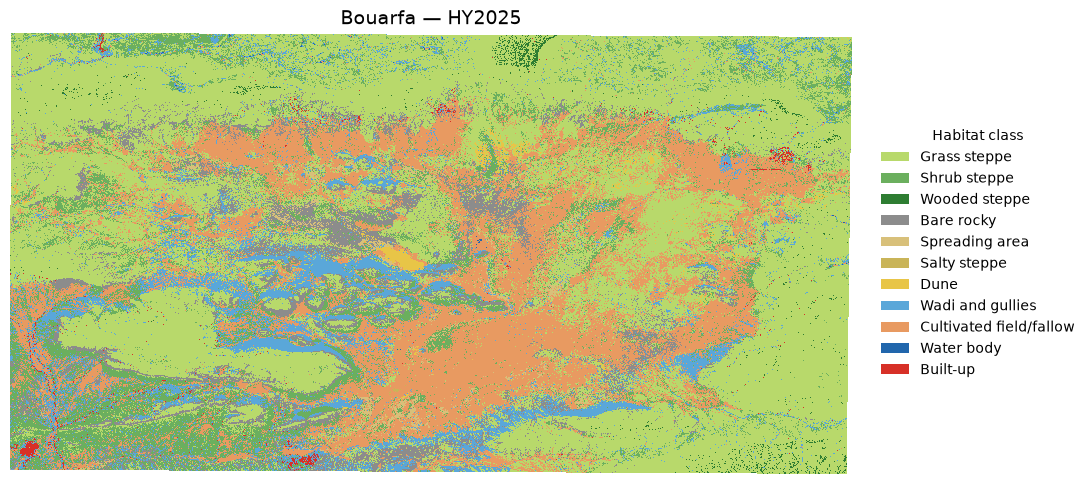

In [87]:
plot_habitat_map(
    RASTER_DIR /
    "Bouarfa_Habitat_RF_HY2025_masked.tif",

    title="Bouarfa — HY2025"
)

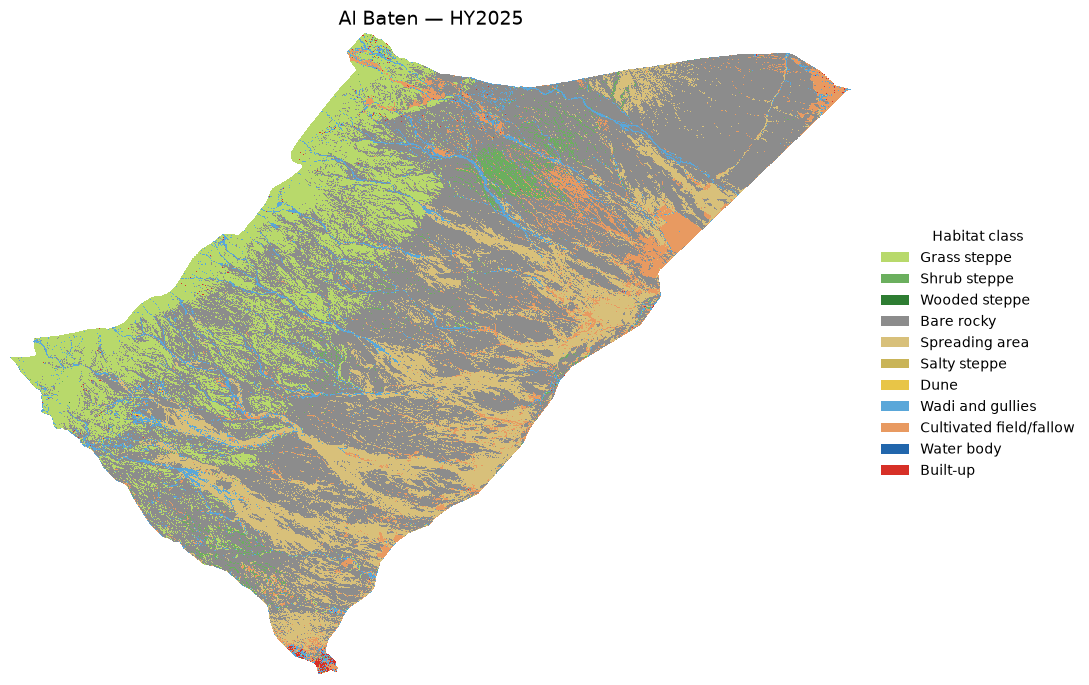

In [90]:
plot_habitat_map(
    RASTER_DIR /
    "Al_Baten_Habitat_RF_HY2025_masked.tif",

    title="Al Baten — HY2025"
)

# Reusable Yearly Habitat Classification Pipeline: Python

```Text
Eastern_Morocco_RF_Samples_HY2025_5px
            │
            │ reuse directly
            ▼
17,175 × 14 predictor sample table
            │
            ├── local grouped 5-fold CV
            │
            ▼
GEE SmileRF classifier
500 trees / variablesPerSplit=6 / minLeaf=2
            │
            │ export classifier once
            ▼
Saved classifier asset
            │
      ┌─────┼─────┬───── ... ─────┐
      ▼     ▼     ▼                 ▼
    HY2018 HY2019 HY2020          HY2025
      │     │     │                 │
 annual predictor stacks using EXACT same
 predictor-generation definition as HY2025
      │     │     │                 │
      ▼     ▼     ▼                 ▼
 classify → map asset → Drive GeoTIFF

## Sentinel-2 coverage diagnostic
*Does May–August provide consistently sufficient clear observations across Eastern Morocco compared with a full habitat year?*
- **Habitat Year/HY whole year**: Sep 1 of year−1 → Aug 31 of year
- **May–August**: May 1 → Aug 31 of the target year

In [4]:
# ee.Authenticate()

Enter verification code:  4/1ATsMZqCNCDHljOeR4Ac3LBXTKEJ43qbkJ5AFo5ikd_ui6BsIqCDd7ERrU8A



Successfully saved authorization token.


In [5]:
import ee

ee.Initialize(project="rse-global-wetlands")

ASSET_ROOT = "projects/rse-global-wetlands/assets"

sample_asset = ee.FeatureCollection(
    f"{ASSET_ROOT}/Eastern_Morocco_RF_Samples_HY2025_5px"
)

print("Number of samples:")
print(sample_asset.size().getInfo())

print("\nProperties:")
print(ee.Feature(sample_asset.first()).propertyNames().getInfo())

Number of samples:
17175

Properties:
['feature_id', 'cv_fold', 'B11', 'B12', 'sample_id', 'class_id', 'NDWI', 'MSAVI', 'Slope', 'B2', 'B3', 'B4', 'Elevation', 'Eastness', 'B8', 'EVI', 'BSI', 'Northness', 'system:index']


In [92]:
predictor = ee.Image(
    "projects/rse-global-wetlands/assets/Eastern_Morocco_PredictorStack_HY2025"
)

print(predictor.bandNames().getInfo())
print(predictor.projection().getInfo())

['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'EVI', 'MSAVI', 'NDWI', 'BSI', 'Elevation', 'Slope', 'Northness', 'Eastness']
{'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [8.983152841195215e-05, 0, -5.010802654818691, 0, -8.983152841195215e-05, 34.16796082065647]}


In [4]:
import ee

ee.Initialize(project="rse-global-wetlands")
ASSET_ROOT = "projects/rse-global-wetlands/assets"
ROI_ASSET = f"{ASSET_ROOT}/Eastern_Morocco_Working_Area"

In [2]:
# =============================================================================
# SENTINEL-2 TEMPORAL COVERAGE QA
# Compare full habitat year vs May-August
# =============================================================================
EXPORT_CRS = "EPSG:32630"
EXPORT_TRANSFORM = [10, 0, 0, 0, -10, 10_000_000]
SAMPLE_SCALE = 10
MAX_PIXELS = 1e13
DRIVE_NODATA = 255

S2_COLLECTION = "COPERNICUS/S2_SR_HARMONIZED"
CLOUD_SCORE_COLLECTION = "GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED"
CLOUD_SCORE_BAND = "cs_cdf"
CLEAR_THRESHOLD = 0.60
MAX_SCENE_CLOUD_PERCENT = 10

QA_YEARS = list(range(2018, 2026))
QA_PERIODS = ["Full_HY", "May_Aug"]

# This is ONLY for coverage QA statistics.
# Final habitat classification remains 10 m.
QA_SCALE = 250

QA_THRESHOLDS = [1, 3, 5, 10]

QA_DRIVE_FOLDER = "Eastern_Morocco_S2_Coverage_QA"

# Use a relatively large tileScale for these regional reductions.
QA_TILE_SCALE = 16


def qa_period_dates(year, period):

    if period == "Full_HY":
        # Sep 1 previous year -> Sep 1 target year
        return (
            f"{year - 1}-09-01",
            f"{year}-09-01",
        )

    elif period == "May_Aug":
        # May 1 -> Sep 1 target year
        return (
            f"{year}-05-01",
            f"{year}-09-01",
        )

    else:
        raise ValueError(
            f"Unknown QA period: {period}"
        )


def get_s2_collection_between(
    start_date,
    end_date,
    roi,
):

    s2 = (
        ee.ImageCollection(S2_COLLECTION)
        .filterBounds(roi)
        .filterDate(start_date, end_date)
        .filter(
            ee.Filter.lt(
                "CLOUDY_PIXEL_PERCENTAGE",
                MAX_SCENE_CLOUD_PERCENT,
            )
        )
    )

    cloud_score = (
        ee.ImageCollection(CLOUD_SCORE_COLLECTION)
        .filterBounds(roi)
        .filterDate(start_date, end_date)
    )

    clean = (
        s2
        .linkCollection(
            cloud_score,
            [CLOUD_SCORE_BAND],
        )
        .map(prepare_s2)
    )

    return s2, clean


def build_period_qa_feature(
    year,
    period,
    roi,
):

    start_date, end_date = qa_period_dates(
        year,
        period,
    )

    raw, clean = get_s2_collection_between(
        start_date,
        end_date,
        roi,
    )

    # ---------------------------------------------------------
    # Valid clear-observation count
    # ---------------------------------------------------------

    valid_obs = (
        clean
        .select("B2")
        .count()
        .rename("valid_obs")
        .unmask(0)
        .clip(roi)
    )

    # ---------------------------------------------------------
    # Mean + percentiles
    # ONE reduction rather than separate mean/percentile calls
    # ---------------------------------------------------------

    obs_reducer = (
        ee.Reducer.mean()
        .combine(
            reducer2=ee.Reducer.percentile(
                [5, 10, 25, 50, 75, 90, 95]
            ),
            sharedInputs=True,
        )
    )

    obs_stats = valid_obs.reduceRegion(
        reducer=obs_reducer,
        geometry=roi,
        scale=QA_SCALE,
        crs=EXPORT_CRS,
        maxPixels=MAX_PIXELS,
        tileScale=QA_TILE_SCALE,
        bestEffort=True,
    )

    # ---------------------------------------------------------
    # Fraction of AOI with >= 1, 3, 5, 10 clear observations
    # ---------------------------------------------------------

    threshold_image = ee.Image.cat(
        [
            valid_obs
            .gte(threshold)
            .rename(f"ge{threshold}")
            for threshold in QA_THRESHOLDS
        ]
    ).toFloat()

    coverage_stats = threshold_image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=QA_SCALE,
        crs=EXPORT_CRS,
        maxPixels=MAX_PIXELS,
        tileScale=QA_TILE_SCALE,
        bestEffort=True,
    )

    # ---------------------------------------------------------
    # Scene/granule count
    # ---------------------------------------------------------

    scene_count = raw.size()

    # NOTE:
    # Scene count is NOT the main coverage metric because multiple
    # Sentinel-2 tiles can occur on the same acquisition date.
    # valid_obs is much more important.
    # ---------------------------------------------------------

    properties = {
        "year": year,
        "period": period,
        "start_date": start_date,
        "end_date_exclusive": end_date,

        "scene_granules": scene_count,

        "valid_obs_mean":
            obs_stats.get("valid_obs_mean"),

        "valid_obs_p05":
            obs_stats.get("valid_obs_p5"),

        "valid_obs_p10":
            obs_stats.get("valid_obs_p10"),

        "valid_obs_p25":
            obs_stats.get("valid_obs_p25"),

        "valid_obs_p50":
            obs_stats.get("valid_obs_p50"),

        "valid_obs_p75":
            obs_stats.get("valid_obs_p75"),

        "valid_obs_p90":
            obs_stats.get("valid_obs_p90"),

        "valid_obs_p95":
            obs_stats.get("valid_obs_p95"),
    }

    for threshold in QA_THRESHOLDS:

        properties[
            f"coverage_ge{threshold}_pct"
        ] = (
            ee.Number(
                coverage_stats.get(
                    f"ge{threshold}"
                )
            )
            .multiply(100)
        )

    return ee.Feature(
        None,
        properties,
    )


def export_period_qa(
    year,
    period,
    roi,
):

    feature = build_period_qa_feature(
        year,
        period,
        roi,
    )

    fc = ee.FeatureCollection(
        [feature]
    )

    name = (
        f"S2_Coverage_QA_"
        f"{period}_HY{year}"
    )

    task = ee.batch.Export.table.toDrive(
        collection=fc,
        description=name,
        folder=QA_DRIVE_FOLDER,
        fileNamePrefix=name,
        fileFormat="CSV",
    )

    task.start()

    print(
        f"Started: HY{year} | "
        f"{period} | "
        f"Task: {task.id}"
    )

    return task

In [100]:
roi = ee.FeatureCollection(
    ROI_ASSET
).geometry()

qa_tasks = {}

for year in QA_YEARS:

    for period in QA_PERIODS:

        key = f"HY{year}_{period}"

        qa_tasks[key] = export_period_qa(
            year=year,
            period=period,
            roi=roi,
        )

Started: HY2018 | Full_HY | Task: HVKVWTDZ7OFQXEEWGGUAGKDR
Started: HY2018 | May_Aug | Task: TO465ICVQZKPIBDDIQFUOWGI
Started: HY2019 | Full_HY | Task: BTFT4FK7IB3O3AUIPWFFNAYS
Started: HY2019 | May_Aug | Task: BVKOJJ6RISK2FHX4QC3L336N
Started: HY2020 | Full_HY | Task: FWU7HX3FWLEUV53EOCVAVSSC
Started: HY2020 | May_Aug | Task: EOO2LJVMDSVSUWH64YNPLUFH
Started: HY2021 | Full_HY | Task: BUEH2TAHQOEWXUNSNJ6Z2PG7
Started: HY2021 | May_Aug | Task: 4GMPICC5K7R3XCH63NRJ3KT6
Started: HY2022 | Full_HY | Task: NEIMTKE7DYQCZPTIQD3OZ25L
Started: HY2022 | May_Aug | Task: ON7XW6RKRYLJ42BNNQJIGM4I
Started: HY2023 | Full_HY | Task: 3HZ4LOZM3XSMW3Y52UTIY3AB
Started: HY2023 | May_Aug | Task: JKRFDND4IVRWSPXO7636HDXK
Started: HY2024 | Full_HY | Task: F3G7GSMUJXMFWMN2E7GJ2DK2
Started: HY2024 | May_Aug | Task: VJX3MILNC7UTD4K5SCFMJ4W3
Started: HY2025 | Full_HY | Task: BBEZ2MXW6KUNN4NDKWI6LT2N
Started: HY2025 | May_Aug | Task: 7TDH5ZCXFFDFO4XR7ODTRQ2C


In [101]:
def export_valid_obs_map(
    year,
    period,
    roi,
):

    start_date, end_date = qa_period_dates(
        year,
        period,
    )

    _, clean = get_s2_collection_between(
        start_date,
        end_date,
        roi,
    )

    valid_obs = (
        clean
        .select("B2")
        .count()
        .rename("valid_obs")
        .unmask(0)
        .clip(roi)
        .toUint16()
    )

    name = (
        f"S2_ValidObs_"
        f"{period}_HY{year}"
    )

    task = ee.batch.Export.image.toDrive(
        image=valid_obs,
        description=name,
        folder=QA_DRIVE_FOLDER,
        fileNamePrefix=name,
        region=roi,
        scale=100,
        crs=EXPORT_CRS,
        maxPixels=MAX_PIXELS,
        fileFormat="GeoTIFF",
        formatOptions={
            "cloudOptimized": True
        },
    )

    task.start()

    print(
        f"Started valid-observation map: "
        f"HY{year} {period}"
    )

    return task

In [102]:
coverage_map_tasks = []

for year in [2018, 2025]:

    for period in [
        "Full_HY",
        "May_Aug",
    ]:

        coverage_map_tasks.append(
            export_valid_obs_map(
                year,
                period,
                roi,
            )
        )

Started valid-observation map: HY2018 Full_HY
Started valid-observation map: HY2018 May_Aug
Started valid-observation map: HY2025 Full_HY
Started valid-observation map: HY2025 May_Aug


## Compare the QA reults (Down and decisions were made)
```Text
automatically find every CSV, merge them, compare Full_HY vs May_Aug year by year, identify the weakest year, and generate a few diagnostic figures.

Found 16 CSV files
S2_Coverage_QA_Full_HY_HY2018.csv
S2_Coverage_QA_Full_HY_HY2019.csv
S2_Coverage_QA_Full_HY_HY2020.csv
S2_Coverage_QA_Full_HY_HY2021.csv
S2_Coverage_QA_Full_HY_HY2022.csv
S2_Coverage_QA_Full_HY_HY2023.csv
S2_Coverage_QA_Full_HY_HY2024.csv
S2_Coverage_QA_Full_HY_HY2025.csv
S2_Coverage_QA_May_Aug_HY2018.csv
S2_Coverage_QA_May_Aug_HY2019.csv
S2_Coverage_QA_May_Aug_HY2020.csv
S2_Coverage_QA_May_Aug_HY2021.csv
S2_Coverage_QA_May_Aug_HY2022.csv
S2_Coverage_QA_May_Aug_HY2023.csv
S2_Coverage_QA_May_Aug_HY2024.csv
S2_Coverage_QA_May_Aug_HY2025.csv
FOUND CSV FILES
S2_Coverage_QA_Full_HY_HY2018.csv
S2_Coverage_QA_Full_HY_HY2019.csv
S2_Coverage_QA_Full_HY_HY2020.csv
S2_Coverage_QA_Full_HY_HY2021.csv
S2_Coverage_QA_Full_HY_HY2022.csv
S2_Coverage_QA_Full_HY_HY2023.csv
S2_Coverage_QA_Full_HY_HY2024.csv
S2_Coverage_QA_Full_HY_HY2025.csv
S2_Coverage_QA_May_Aug_HY2018.csv
S2_Coverage_QA_May_Aug_HY2019.csv
S2_Coverage_QA_May_Aug_HY2020.csv
S2_Coverage_QA_May_Aug_HY2021.csv
S2_Coverage_Q

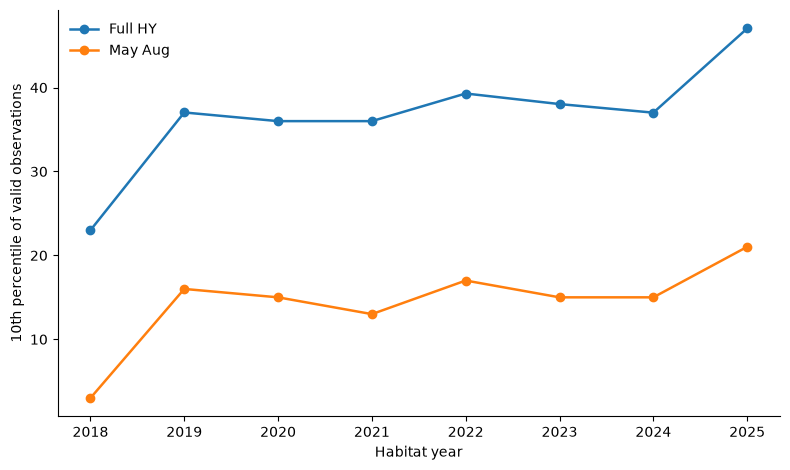

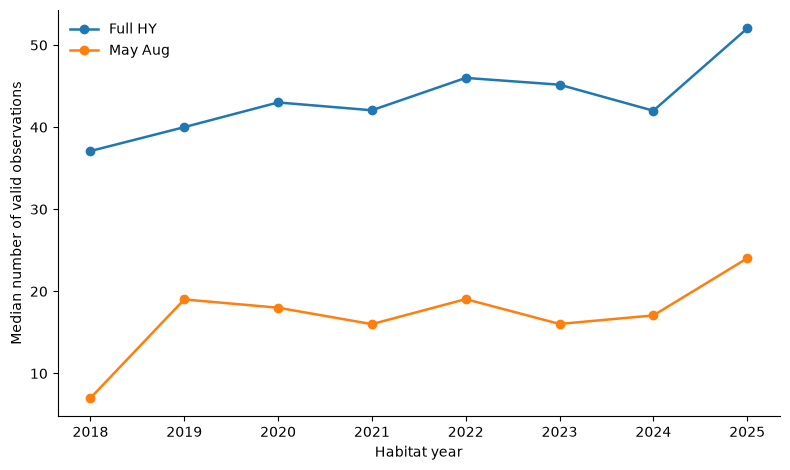

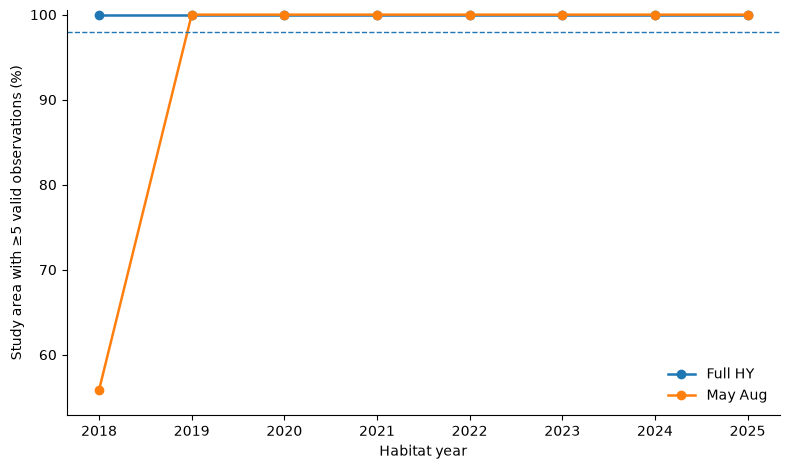

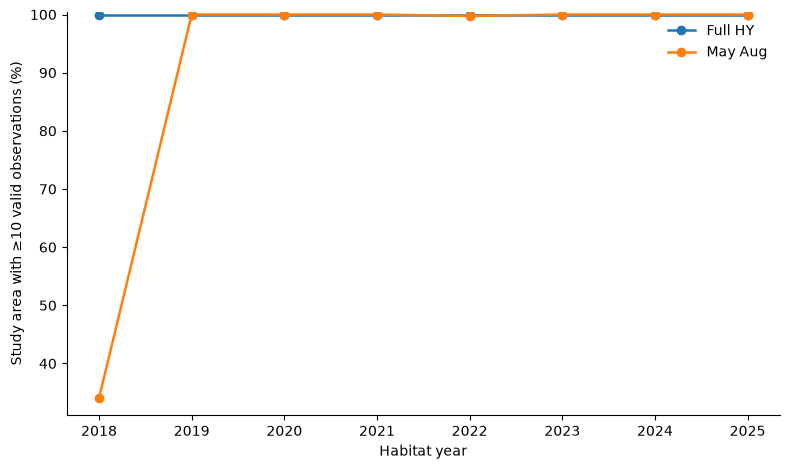


DONE
Outputs saved to:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\Eastern_Morocco_S2_Coverage_QA\Summary


In [104]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
  
# =============================================================================
# 0. USER SETTINGS
# =============================================================================

QA_DIR = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping\Eastern_Morocco_S2_Coverage_QA"
)

csv_files = sorted(QA_DIR.glob("*.csv"))

print(f"Found {len(csv_files)} CSV files")

for f in csv_files:
    print(f.name)

OUT_DIR = QA_DIR / "Summary"
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_YEARS = list(range(2018, 2026))

PERIOD_ORDER = ["Full_HY", "May_Aug"]

# Main indicators we care about
METRICS = [
    "scene_granules",
    "valid_obs_mean",
    "valid_obs_p05",
    "valid_obs_p10",
    "valid_obs_p25",
    "valid_obs_p50",
    "valid_obs_p75",
    "valid_obs_p90",
    "valid_obs_p95",
    "coverage_ge1_pct",
    "coverage_ge3_pct",
    "coverage_ge5_pct",
    "coverage_ge10_pct",
]


# =============================================================================
# 1. FIND ALL QA CSV FILES
# =============================================================================

csv_files = sorted(QA_DIR.rglob("*.csv"))

# Avoid accidentally reading output files if script is rerun
csv_files = [
    f for f in csv_files
    if OUT_DIR not in f.parents
]

print("=" * 80)
print("FOUND CSV FILES")
print("=" * 80)

for f in csv_files:
    print(f.name)

print(f"\nTotal CSV files found: {len(csv_files)}")


# =============================================================================
# 2. READ AND COMBINE CSV FILES
# =============================================================================

frames = []

for file in csv_files:

    try:
        df = pd.read_csv(file)

    except Exception as exc:
        print(f"WARNING: could not read {file.name}: {exc}")
        continue

    if df.empty:
        print(f"WARNING: empty CSV: {file.name}")
        continue

    # Earth Engine CSV exports occasionally include system columns.
    # Keep them for now; they can simply be ignored later.
    df["source_file"] = file.name

    # -------------------------------------------------------------------------
    # Recover year from filename if not already available
    # -------------------------------------------------------------------------

    if "year" not in df.columns:

        match = re.search(r"HY(\d{4})", file.name)

        if match:
            df["year"] = int(match.group(1))

    # -------------------------------------------------------------------------
    # Recover period from filename if not already available
    # -------------------------------------------------------------------------

    if "period" not in df.columns:

        if "Full_HY" in file.name:
            df["period"] = "Full_HY"

        elif "May_Aug" in file.name:
            df["period"] = "May_Aug"

    frames.append(df)


if not frames:
    raise RuntimeError(
        "No readable CSV files were found in the QA directory."
    )


qa = pd.concat(
    frames,
    ignore_index=True,
    sort=False,
)


# =============================================================================
# 3. CLEAN COLUMN TYPES
# =============================================================================

if "year" not in qa.columns:
    raise KeyError(
        "Could not find or infer a 'year' field."
    )

if "period" not in qa.columns:
    raise KeyError(
        "Could not find or infer a 'period' field."
    )


qa["year"] = pd.to_numeric(
    qa["year"],
    errors="coerce",
)

qa = qa.dropna(
    subset=["year", "period"]
).copy()

qa["year"] = qa["year"].astype(int)


# Convert QA metrics to numeric
for col in METRICS:

    if col in qa.columns:

        qa[col] = pd.to_numeric(
            qa[col],
            errors="coerce",
        )


# Keep target period names consistent
qa["period"] = (
    qa["period"]
    .astype(str)
    .str.strip()
)

qa = qa[
    qa["period"].isin(PERIOD_ORDER)
].copy()


# =============================================================================
# 4. CHECK FOR DUPLICATES
# =============================================================================

duplicate_counts = (
    qa.groupby(["year", "period"])
    .size()
    .reset_index(name="n")
)

duplicates = duplicate_counts[
    duplicate_counts["n"] > 1
]

if not duplicates.empty:

    print("\nWARNING: duplicate year-period rows were found:")
    print(duplicates.to_string(index=False))

    print(
        "\nThe script will average numeric QA fields "
        "within duplicated year-period combinations."
    )


# Aggregate in case duplicate files exist
numeric_cols = [
    c for c in METRICS
    if c in qa.columns
]

summary = (
    qa
    .groupby(
        ["year", "period"],
        as_index=False,
    )[numeric_cols]
    .mean()
)


# =============================================================================
# 5. BASIC QA: EXPECTED YEARS / PERIODS
# =============================================================================

print("\n" + "=" * 80)
print("AVAILABLE YEAR-PERIOD COMBINATIONS")
print("=" * 80)

availability = (
    summary
    .assign(value="YES")
    .pivot(
        index="year",
        columns="period",
        values="value",
    )
    .reindex(EXPECTED_YEARS)
)

print(
    availability
    .fillna("MISSING")
    .to_string()
)


# =============================================================================
# 6. MAIN COMPARISON TABLE
# =============================================================================

main_cols = [
    "year",
    "period",
]

for c in [
    "scene_granules",
    "valid_obs_mean",
    "valid_obs_p10",
    "valid_obs_p25",
    "valid_obs_p50",
    "coverage_ge3_pct",
    "coverage_ge5_pct",
    "coverage_ge10_pct",
]:

    if c in summary.columns:
        main_cols.append(c)


main_table = (
    summary[main_cols]
    .sort_values(
        ["year", "period"]
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 80)
print("FULL HY VS MAY-AUG — MAIN RESULTS")
print("=" * 80)

print(
    main_table
    .round(2)
    .to_string(index=False)
)


# =============================================================================
# 7. CREATE WIDE FULL_HY VS MAY_AUG TABLE
# =============================================================================

comparison_metrics = [
    c for c in [
        "valid_obs_mean",
        "valid_obs_p10",
        "valid_obs_p25",
        "valid_obs_p50",
        "coverage_ge3_pct",
        "coverage_ge5_pct",
        "coverage_ge10_pct",
    ]
    if c in summary.columns
]


wide = summary.pivot(
    index="year",
    columns="period",
    values=comparison_metrics,
)


# Flatten MultiIndex columns
wide.columns = [
    f"{metric}_{period}"
    for metric, period in wide.columns
]

wide = wide.reset_index()


# =============================================================================
# 8. CALCULATE MAY-AUG MINUS FULL-HY DIFFERENCES
# =============================================================================

for metric in comparison_metrics:

    full_col = f"{metric}_Full_HY"
    may_col = f"{metric}_May_Aug"

    if (
        full_col in wide.columns
        and may_col in wide.columns
    ):

        wide[f"{metric}_MayAug_minus_FullHY"] = (
            wide[may_col]
            - wide[full_col]
        )


print("\n" + "=" * 80)
print("YEAR-BY-YEAR COMPARISON")
print("May-Aug minus Full-HY")
print("=" * 80)

display_cols = ["year"]

for metric in [
    "valid_obs_p10",
    "valid_obs_p50",
    "coverage_ge5_pct",
    "coverage_ge10_pct",
]:

    for suffix in [
        "Full_HY",
        "May_Aug",
        "MayAug_minus_FullHY",
    ]:

        col = f"{metric}_{suffix}"

        if col in wide.columns:
            display_cols.append(col)


print(
    wide[display_cols]
    .round(2)
    .to_string(index=False)
)


# =============================================================================
# 9. IDENTIFY WORST YEARS
# =============================================================================

may = summary[
    summary["period"] == "May_Aug"
].copy()


print("\n" + "=" * 80)
print("MAY-AUG WORST-YEAR DIAGNOSTICS")
print("=" * 80)


def report_worst(metric, higher_is_better=True):

    if metric not in may.columns:
        return

    valid = may.dropna(
        subset=[metric]
    )

    if valid.empty:
        return

    if higher_is_better:
        row = valid.loc[
            valid[metric].idxmin()
        ]
    else:
        row = valid.loc[
            valid[metric].idxmax()
        ]

    print(
        f"{metric:<25} "
        f"worst HY = {int(row['year'])}, "
        f"value = {row[metric]:.2f}"
    )


report_worst("valid_obs_p10")
report_worst("valid_obs_p25")
report_worst("valid_obs_p50")
report_worst("coverage_ge3_pct")
report_worst("coverage_ge5_pct")
report_worst("coverage_ge10_pct")


# =============================================================================
# 10. SIMPLE COVERAGE-BASED DECISION
# =============================================================================

print("\n" + "=" * 80)
print("COVERAGE-BASED INTERPRETATION")
print("=" * 80)


required = [
    "valid_obs_p10",
    "coverage_ge5_pct",
]

if all(c in may.columns for c in required):

    min_p10 = may["valid_obs_p10"].min()

    min_cov5 = may[
        "coverage_ge5_pct"
    ].min()

    worst_p10_year = int(
        may.loc[
            may["valid_obs_p10"].idxmin(),
            "year",
        ]
    )

    worst_cov5_year = int(
        may.loc[
            may["coverage_ge5_pct"].idxmin(),
            "year",
        ]
    )

    print(
        f"Minimum May-Aug P10 valid observations: "
        f"{min_p10:.2f} "
        f"(HY{worst_p10_year})"
    )

    print(
        f"Minimum May-Aug area with >=5 observations: "
        f"{min_cov5:.2f}% "
        f"(HY{worst_cov5_year})"
    )

    print()

    # Conservative practical interpretation
    if (
        min_p10 >= 5
        and min_cov5 >= 98
    ):

        print(
            "RESULT: May-Aug has EXCELLENT clear-observation coverage "
            "across all years."
        )

        print(
            "Coverage alone provides no strong reason to use a "
            "full-year composite."
        )

        print(
            "Next step: compare May-Aug against other candidate "
            "windows using grouped RF cross-validation."
        )

    elif (
        min_p10 >= 3
        and min_cov5 >= 95
    ):

        print(
            "RESULT: May-Aug coverage appears generally adequate, "
            "but some years/areas are less strongly sampled."
        )

        print(
            "Inspect the worst-year observation-count map before "
            "selecting May-Aug."
        )

    else:

        print(
            "RESULT: May-Aug has potentially important coverage "
            "limitations in at least one year."
        )

        print(
            "A broader seasonal window should be considered."
        )

else:

    print(
        "Required fields for automatic interpretation were not found."
    )


# =============================================================================
# 11. OVERALL PERIOD STATISTICS
# =============================================================================

period_stats = (
    summary
    .groupby("period")[comparison_metrics]
    .agg(["mean", "min", "max"])
)

print("\n" + "=" * 80)
print("2018-2025 PERIOD SUMMARY")
print("=" * 80)

print(
    period_stats
    .round(2)
    .to_string()
)


# =============================================================================
# 12. SAVE TABLES
# =============================================================================

summary.to_csv(
    OUT_DIR / "S2_Coverage_QA_AllYears_Long.csv",
    index=False,
)

wide.to_csv(
    OUT_DIR / "S2_Coverage_QA_FullHY_vs_MayAug.csv",
    index=False,
)

period_stats.to_csv(
    OUT_DIR / "S2_Coverage_QA_Period_Summary.csv"
)


# Optional Excel workbook
try:

    with pd.ExcelWriter(
        OUT_DIR / "S2_Coverage_QA_Summary.xlsx",
        engine="openpyxl",
    ) as writer:

        summary.to_excel(
            writer,
            sheet_name="All_years",
            index=False,
        )

        wide.to_excel(
            writer,
            sheet_name="FullHY_vs_MayAug",
            index=False,
        )

        period_stats.to_excel(
            writer,
            sheet_name="Period_summary",
        )

    print(
        "\nSaved Excel workbook:",
        OUT_DIR / "S2_Coverage_QA_Summary.xlsx",
    )

except Exception as exc:

    print(
        "\nExcel output skipped:",
        exc,
    )


# =============================================================================
# 13. FIGURES
# =============================================================================

plot_df = summary.copy()


# -----------------------------------------------------------------------------
# Figure 1: P10 valid observations
# -----------------------------------------------------------------------------

if "valid_obs_p10" in plot_df.columns:

    fig, ax = plt.subplots(
        figsize=(8, 4.8)
    )

    for period in PERIOD_ORDER:

        temp = plot_df[
            plot_df["period"] == period
        ].sort_values("year")

        ax.plot(
            temp["year"],
            temp["valid_obs_p10"],
            marker="o",
            linewidth=1.8,
            label=period.replace("_", " "),
        )

    ax.set_xlabel("Habitat year")
    ax.set_ylabel(
        "10th percentile of valid observations"
    )

    ax.set_xticks(EXPECTED_YEARS)

    ax.legend(
        frameon=False
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    fig.savefig(
        OUT_DIR / "S2_Coverage_P10_ValidObs.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


# -----------------------------------------------------------------------------
# Figure 2: Median valid observations
# -----------------------------------------------------------------------------

if "valid_obs_p50" in plot_df.columns:

    fig, ax = plt.subplots(
        figsize=(8, 4.8)
    )

    for period in PERIOD_ORDER:

        temp = plot_df[
            plot_df["period"] == period
        ].sort_values("year")

        ax.plot(
            temp["year"],
            temp["valid_obs_p50"],
            marker="o",
            linewidth=1.8,
            label=period.replace("_", " "),
        )

    ax.set_xlabel("Habitat year")
    ax.set_ylabel(
        "Median number of valid observations"
    )

    ax.set_xticks(EXPECTED_YEARS)

    ax.legend(
        frameon=False
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    fig.savefig(
        OUT_DIR / "S2_Coverage_Median_ValidObs.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


# -----------------------------------------------------------------------------
# Figure 3: Area with >= 5 valid observations
# -----------------------------------------------------------------------------

if "coverage_ge5_pct" in plot_df.columns:

    fig, ax = plt.subplots(
        figsize=(8, 4.8)
    )

    for period in PERIOD_ORDER:

        temp = plot_df[
            plot_df["period"] == period
        ].sort_values("year")

        ax.plot(
            temp["year"],
            temp["coverage_ge5_pct"],
            marker="o",
            linewidth=1.8,
            label=period.replace("_", " "),
        )

    ax.axhline(
        98,
        linestyle="--",
        linewidth=1,
    )

    ax.set_xlabel("Habitat year")
    ax.set_ylabel(
        "Study area with ≥5 valid observations (%)"
    )

    ax.set_xticks(EXPECTED_YEARS)

    ax.set_ylim(
        max(
            0,
            plot_df["coverage_ge5_pct"].min() - 3,
        ),
        100.5,
    )

    ax.legend(
        frameon=False
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    fig.savefig(
        OUT_DIR / "S2_Coverage_GE5_Percent.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


# -----------------------------------------------------------------------------
# Figure 4: Area with >= 10 valid observations
# -----------------------------------------------------------------------------

if "coverage_ge10_pct" in plot_df.columns:

    fig, ax = plt.subplots(
        figsize=(8, 4.8)
    )

    for period in PERIOD_ORDER:

        temp = plot_df[
            plot_df["period"] == period
        ].sort_values("year")

        ax.plot(
            temp["year"],
            temp["coverage_ge10_pct"],
            marker="o",
            linewidth=1.8,
            label=period.replace("_", " "),
        )

    ax.set_xlabel("Habitat year")
    ax.set_ylabel(
        "Study area with ≥10 valid observations (%)"
    )

    ax.set_xticks(EXPECTED_YEARS)

    ax.set_ylim(
        max(
            0,
            plot_df["coverage_ge10_pct"].min() - 3,
        ),
        100.5,
    )

    ax.legend(
        frameon=False
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    fig.savefig(
        OUT_DIR / "S2_Coverage_GE10_Percent.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


# =============================================================================
# 14. DONE
# =============================================================================

print("\n" + "=" * 80)
print("DONE")
print("=" * 80)

print(
    "Outputs saved to:"
)
print(OUT_DIR)

```Text
Sentinel-2 observation availability is sufficiently dense from 2019 onward 
that temporal-window selection can be driven primarily 
by ecological and classification considerations rather than cloud availability. 
HY2018 is the notable exception under the May–August window.

The coverage QA test has successfully answered the first:
Question 1 — Is Sentinel-2 availability sufficient?
For 2019–2025:
Definitely yes.

For May–August 2018:
No.
Therefore we should test a slightly wider fixed seasonal window.

Question 2 — Which temporal window produces the best habitat classification?
Coverage cannot answer this.

For next step, the workflow designs is
same 17,175 locations → same class_id → same feature_id → same cv_fold → same 14 predictors → same RF → only the Sentinel-2 temporal window changes.

Existing 17,175 RF points
        ↓
keep 1 existing point / polygon
        ↓
~3,435 points total
        ↓
build one temporal composite
        ↓
sample predictors
        ↓
BATCH export to small GEE table asset
        ↓
download MATERIALIZED table
        ↓
local sklearn
        ↓
ONE fixed holdout
        ↓
compare preliminary accuracy

                        May-Aug   Apr-Aug   difference
Balanced Accuracy          .434      .425      +.009
Macro-F1                   .477      .459      +.018
Kappa                      .541      .533      +.008
OA                         .630      .624      +.006

In [1]:
# %run compare_s2_temporal_windows_pilot.py

## Continues

```Text
Decision: May–Aug has the best classification signal, Apr–Aug looks like the likely best compromise for the full 2018–2025 series, and Full-HY no longer looks necessary.

Macro-F1:
May-Aug  .477
Apr-Aug  .459
Mar-Aug  .456
Full HY  .444

Now use the MAY-AUG to produce the annual habitat map

Existing 17,175 RF points
Existing terrain asset
        │
        ▼
HY2025 Apr-Aug S2 composite
        │
        ├── SAVE spectral/index image as GEE asset
        │
        ▼
sample stored image at existing 17,175 points
        │
        ├── SAVE training table as GEE asset
        │
        ▼
train 500-tree Smile RF once
        │
        ├── SAVE classifier as GEE asset
        │
        ▼
2018 ── build Apr-Aug spectral asset once ── classify ── save map
2019 ── build Apr-Aug spectral asset once ── classify ── save map
...
2025 ── REUSE training-year spectral asset ─ classify ── save map

In [5]:
import importlib
import sentinel2_annual_habitat_classification_v2 as s2c

s2c = importlib.reload(s2c)

In [6]:
print("Temporal window:", s2c.TEMPORAL_WINDOW)
print("Years:", s2c.HABITAT_YEARS)
print("Training year:", s2c.TRAINING_YEAR)

print("Training samples:")
print(s2c.training_sample_asset_id())

print("Classifier:")
print(s2c.classifier_asset_id())

Temporal window: Apr_Aug
Years: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Training year: 2025
Training samples:
projects/rse-global-wetlands/assets/Eastern_Morocco_S2_RF_Samples_AprAug_HY2025_Fixed5Pts
Classifier:
projects/rse-global-wetlands/assets/Eastern_Morocco_S2_RF_Classifier_AprAug_HY2025_T500


In [ ]:
s2c.main()

2026-09-16 17:14:23,041 | INFO | Earth Engine initialized with project 'rse-global-wetlands'.
2026-09-16 17:14:23,042 | INFO | Saved run configuration: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\Annual_Classification\Sentinel2\AprAug\Manifest\S2_Run_Configuration.json
2026-09-16 17:14:45,258 | INFO | Existing RF points: 17175
2026-09-16 17:14:45,259 | INFO | Existing source polygons: 3435
2026-09-16 17:14:46,623 | INFO | Authoritative upstream assets passed preflight QA.
2026-09-16 17:14:46,624 | INFO | ================================================================================
2026-09-16 17:14:46,624 | INFO | TRAINING-YEAR SETUP | HY2025 | Apr_Aug
2026-09-16 17:14:48,165 | INFO | HY2025 | Apr_Aug | filtered S2 granules: 583
2026-09-16 17:14:48,486 | INFO | Started HY2025 spectral-asset export: 7SK3QSDRQN2RIDNCKWCSG6C3
2026-09-16 17:14:48,616 | INFO | Task S2 spectral AprAug HY2025                          READY
2026-09-16 17:15:18,736 | INFO

In [ ]:
TEMPORAL_WINDOW = "Apr_Aug" #"May_Aug";"Mar_Aug";"Full_HY"

REBUILD_SPECTRAL_ASSETS = False
REBUILD_TRAINING_SAMPLE_ASSET = False
RETRAIN_CLASSIFIER = False
OVERWRITE_MAP_ASSETS = False

EXPORT_MAPS_TO_ASSET = True
EXPORT_MAPS_TO_DRIVE = True

SAMPLE_TILE_SCALE = 16

In [6]:
# ============================================================
# Check recent Earth Engine tasks
# ============================================================

import ee

ee.Initialize(project="rse-global-wetlands")

for task in ee.batch.Task.list()[:50]:
    status = task.status()

    print(
        f"{status.get('state', ''):10s}",
        "|",
        status.get("description", ""),
        "|",
        status.get("error_message", "")
    )

COMPLETED  | Eastern_Morocco_Habitat_S2_RF_AprAug_HY2025_T500 | 
COMPLETED  | Eastern_Morocco_Habitat_S2_RF_AprAug_HY2024_T500_Drive | 
COMPLETED  | Eastern_Morocco_Habitat_S2_RF_AprAug_HY2024_T500 | 
COMPLETED  | Eastern_Morocco_S2_Spectral_AprAug_HY2024 | 
COMPLETED  | Eastern_Morocco_Habitat_S2_RF_AprAug_HY2023_T500_Drive | 
COMPLETED  | Eastern_Morocco_Habitat_S2_RF_AprAug_HY2023_T500 | 
COMPLETED  | Eastern_Morocco_S2_Spectral_AprAug_HY2023 | 
COMPLETED  | Eastern_Morocco_Habitat_S2_RF_AprAug_HY2022_T500_Drive | 
COMPLETED  | Eastern_Morocco_Habitat_S2_RF_AprAug_HY2022_T500 | 
COMPLETED  | Eastern_Morocco_S2_Spectral_AprAug_HY2022 | 
COMPLETED  | Eastern_Morocco_Habitat_S2_RF_AprAug_HY2021_T500_Drive | 
COMPLETED  | Eastern_Morocco_Habitat_S2_RF_AprAug_HY2021_T500 | 
COMPLETED  | Eastern_Morocco_S2_Spectral_AprAug_HY2021 | 
COMPLETED  | Eastern_Morocco_Habitat_S2_RF_AprAug_HY2020_T500_Drive | 
COMPLETED  | Eastern_Morocco_Habitat_S2_RF_AprAug_HY2020_T500 | 
COMPLETED  | Eastern_Mo

## Mask the Nodata values

In [10]:
# ============================================================
# Mask annual habitat-map series and calculate area summary
# ============================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

from rasterio.features import geometry_mask


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

RASTER_DIR = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping\GEE_result_map\Sentinel2_AprAug"
)

MASKED_DIR = (
    RASTER_DIR /
    "Sentinel2_AprAug_masked"
)

MASKED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


BOUNDARY_PATH = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Morocco two study areas"
    r"\Eastern_Morocco_Working_Area.shp"
)


NODATA_VALUE = 255


CLASS_MAP = {
    0: "Grass steppe",
    1: "Shrub steppe",
    2: "Wooded steppe",
    3: "Bare rocky",
    4: "Spreading area",
    5: "Salty steppe",
    6: "Dune",
    7: "Wadi and gullies",
    8: "Cultivated field/fallow",
    9: "Water body",
    10: "Built-up",
}

In [12]:
# ============================================================
# Mask one categorical habitat raster
# ============================================================

def mask_habitat_raster(
    raster_path,
    boundary_path,
    output_path,
    nodata=255,
    overwrite=False,
):

    raster_path = Path(raster_path)
    boundary_path = Path(boundary_path)
    output_path = Path(output_path)


    # --------------------------------------------------------
    # Reuse existing output
    # --------------------------------------------------------

    if output_path.exists() and not overwrite:

        print(
            "Existing masked raster:",
            output_path.name
        )

        return output_path


    # --------------------------------------------------------
    # Read raster
    # --------------------------------------------------------

    with rasterio.open(raster_path) as src:

        data = src.read(1)

        profile = src.profile.copy()

        raster_crs = src.crs

        transform = src.transform


        # ----------------------------------------------------
        # Read boundary and match CRS
        # ----------------------------------------------------

        boundary = gpd.read_file(
            boundary_path
        )

        if boundary.crs != raster_crs:

            boundary = boundary.to_crs(
                raster_crs
            )


        # ----------------------------------------------------
        # True = inside study area
        # ----------------------------------------------------

        inside = geometry_mask(
            geometries=boundary.geometry,
            out_shape=(
                src.height,
                src.width
            ),
            transform=transform,
            invert=True,
        )


        # ----------------------------------------------------
        # Preserve valid classes 0-10
        # Outside boundary -> 255
        # ----------------------------------------------------

        output = data.copy()

        output[~inside] = nodata

        output = output.astype(
            np.uint8
        )


        # ----------------------------------------------------
        # Update metadata
        # ----------------------------------------------------

        profile.update(
            dtype="uint8",
            nodata=nodata,
            compress="deflate",
        )


        # ----------------------------------------------------
        # Write output
        # ----------------------------------------------------

        with rasterio.open(
            output_path,
            "w",
            **profile
        ) as dst:

            dst.write(
                output,
                1
            )


    print(
        "Saved:",
        output_path.name
    )

    return output_path

In [52]:
# ============================================================
# Mask annual Sentinel-2 habitat maps
# ============================================================

RASTER_PATTERN = (
    "Eastern_Morocco_Habitat_S2_RF_AprAug_HY*_T500.tif"
)


annual_rasters = sorted(
    RASTER_DIR.glob(
        RASTER_PATTERN
    )
)


print(
    "Annual rasters found:",
    len(annual_rasters)
)


masked_rasters = []


for raster_path in annual_rasters:

    output_path = (
        MASKED_DIR /
        f"{raster_path.stem}_masked.tif"
    )


    print("\n" + "=" * 70)
    print(
        "Input:",
        raster_path.name
    )


    masked_path = mask_habitat_raster(
        raster_path=raster_path,
        boundary_path=BOUNDARY_PATH,
        output_path=output_path,
        nodata=NODATA_VALUE,
        overwrite=False,
    )


    masked_rasters.append(
        masked_path
    )


print(
    "\nMasked rasters:",
    len(masked_rasters)
)

Annual rasters found: 7

Input: Eastern_Morocco_Habitat_S2_RF_AprAug_HY2018_T500.tif
Existing masked raster: Eastern_Morocco_Habitat_S2_RF_AprAug_HY2018_T500_masked.tif

Input: Eastern_Morocco_Habitat_S2_RF_AprAug_HY2019_T500.tif
Existing masked raster: Eastern_Morocco_Habitat_S2_RF_AprAug_HY2019_T500_masked.tif

Input: Eastern_Morocco_Habitat_S2_RF_AprAug_HY2020_T500.tif
Existing masked raster: Eastern_Morocco_Habitat_S2_RF_AprAug_HY2020_T500_masked.tif

Input: Eastern_Morocco_Habitat_S2_RF_AprAug_HY2021_T500.tif
Existing masked raster: Eastern_Morocco_Habitat_S2_RF_AprAug_HY2021_T500_masked.tif

Input: Eastern_Morocco_Habitat_S2_RF_AprAug_HY2022_T500.tif
Existing masked raster: Eastern_Morocco_Habitat_S2_RF_AprAug_HY2022_T500_masked.tif

Input: Eastern_Morocco_Habitat_S2_RF_AprAug_HY2023_T500.tif
Existing masked raster: Eastern_Morocco_Habitat_S2_RF_AprAug_HY2023_T500_masked.tif

Input: Eastern_Morocco_Habitat_S2_RF_AprAug_HY2024_T500.tif
Existing masked raster: Eastern_Morocco_Habit

In [14]:
# ============================================================
# QC masked rasters
# ============================================================

for raster_path in masked_rasters:

    with rasterio.open(
        raster_path
    ) as src:

        data = src.read(1)

        values = np.unique(
            data
        )


    print(
        raster_path.name,
        "->",
        values
    )

Eastern_Morocco_Habitat_S2_RF_AprAug_HY2018_T500_masked.tif -> [  0   1   2   3   4   5   6   7   8   9  10 255]
Eastern_Morocco_Habitat_S2_RF_AprAug_HY2019_T500_masked.tif -> [  0   1   2   3   4   5   6   7   8   9  10 255]
Eastern_Morocco_Habitat_S2_RF_AprAug_HY2020_T500_masked.tif -> [  0   1   2   3   4   5   6   7   8   9  10 255]
Eastern_Morocco_Habitat_S2_RF_AprAug_HY2021_T500_masked.tif -> [  0   1   2   3   4   5   6   7   8   9  10 255]
Eastern_Morocco_Habitat_S2_RF_AprAug_HY2022_T500_masked.tif -> [  0   1   2   3   4   5   6   7   8   9  10 255]
Eastern_Morocco_Habitat_S2_RF_AprAug_HY2023_T500_masked.tif -> [  0   1   2   3   4   5   6   7   8   9  10 255]
Eastern_Morocco_Habitat_S2_RF_AprAug_HY2024_T500_masked.tif -> [  0   1   2   3   4   5   6   7   8   9  10 255]


## Annual habitat-area summary
```Text
Downloaded the annual habitat map from Google Drive:
Eastern_Morocco_Habitat_S2_AprAug_Annual, https://drive.google.com/drive/folders/1wEHaaqN6ohityx2t80fz0fA22qCuhDpY
To local repository: 
'C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\GEE_result_map\Sentinel2_AprAug'

In [15]:
# ============================================================
# Annual habitat-area summary
# ============================================================

from pathlib import Path
import rasterio
import numpy as np
import pandas as pd


CLASS_MAP = {
    0: "Grass steppe",
    1: "Shrub steppe",
    2: "Wooded steppe",
    3: "Bare rocky",
    4: "Spreading area",
    5: "Salty steppe",
    6: "Dune",
    7: "Wadi and gullies",
    8: "Cultivated field/fallow",
    9: "Water body",
    10: "Built-up",
}


MAP_DIR = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard"
    r"\01_Data\Habitat mapping\GEE_result_map\Sentinel2_AprAug\Sentinel2_AprAug_masked"
)


records = []

for raster_path in sorted(
    MAP_DIR.glob(
        "Eastern_Morocco_Habitat_S2_RF_AprAug_HY*_T500_masked.tif"
    )
):

    year = int(
        raster_path.stem
        .split("_HY")[1]
        .split("_")[0]
    )

    with rasterio.open(raster_path) as src:

        arr = src.read(
            1,
            masked=True
        )

        pixel_area_m2 = abs(
            src.transform.a *
            src.transform.e
        )

        for class_id, habitat in CLASS_MAP.items():

            n_pixels = np.sum(
                arr == class_id
            )

            area_km2 = (
                n_pixels *
                pixel_area_m2 /
                1e6
            )

            records.append({
                "year": year,
                "class_id": class_id,
                "habitat": habitat,
                "n_pixels": int(n_pixels),
                "area_km2": area_km2,
            })


area_df = pd.DataFrame(records)

display(
    area_df.head(20)
)

area_df.to_csv(
    MAP_DIR /
    "Sentinel2_AprAug_Annual_Habitat_Area_2018_2025.csv",
    index=False
)

,year,class_id,habitat,n_pixels,area_km2
0,2018,0,Grass steppe,270291995,27029.1995
1,2018,1,Shrub steppe,80089927,8008.9927
2,2018,2,Wooded steppe,893945,89.3945
3,2018,3,Bare rocky,32768782,3276.8782
4,2018,4,Spreading area,5727147,572.7147
5,2018,5,Salty steppe,310002,31.0002
6,2018,6,Dune,3089678,308.9678
7,2018,7,Wadi and gullies,56160564,5616.0564
8,2018,8,Cultivated field/fallow,45757922,4575.7922
9,2018,9,Water body,244124,24.4124


In [16]:
area_wide = (
    area_df
    .pivot(
        index="year",
        columns="habitat",
        values="area_km2"
    )
)

display(
    area_wide.round(2)
)

habitat,Bare rocky,Built-up,Cultivated field/fallow,Dune,Grass steppe,Salty steppe,Shrub steppe,Spreading area,Wadi and gullies,Water body,Wooded steppe
year,,,,,,,,,,,
2018,3276.88,640.79,4575.79,308.97,27029.20,31.00,8008.99,572.71,5616.06,24.41,89.39
2019,3214.34,618.12,6057.62,174.17,24683.00,48.74,7368.09,541.43,7301.22,49.21,118.27
2020,3129.73,700.74,4002.54,138.42,28439.87,30.19,7759.59,546.34,5284.10,30.97,111.72
2021,3208.47,693.63,4295.97,326.34,26141.02,16.93,9495.97,547.87,5337.43,21.07,89.50
2022,3324.13,681.24,2821.10,503.28,28016.37,28.34,10153.17,783.61,3664.49,15.25,183.22
2023,3265.63,634.96,3185.66,342.58,28270.80,16.59,9701.09,651.88,3892.95,17.24,194.80
2024,3502.06,878.26,2533.26,500.85,27215.32,13.60,10851.54,803.08,3757.34,11.17,107.73


In [27]:
print(area_df.columns.tolist())
print(area_wide.columns.tolist())

['year', 'class_id', 'habitat', 'n_pixels', 'area_km2']
['Bare rocky', 'Built-up', 'Cultivated field/fallow', 'Dune', 'Grass steppe', 'Salty steppe', 'Shrub steppe', 'Spreading area', 'Wadi and gullies', 'Water body', 'Wooded steppe']


In [29]:
# ============================================================
# Check total mapped habitat area for each year
# ============================================================

mapped_area_check = (
    area_wide
    .sum(axis=1)
    .rename("mapped_area_km2")
    .reset_index()
    .sort_values("year")
)

# Difference relative to the first year
baseline_area = (
    mapped_area_check
    .iloc[0]["mapped_area_km2"]
)

mapped_area_check["difference_km2"] = (
    mapped_area_check["mapped_area_km2"]
    - baseline_area
)

mapped_area_check["difference_pct"] = (
    mapped_area_check["difference_km2"]
    / baseline_area
    * 100
)

display(
    mapped_area_check.round(3)
)

,year,mapped_area_km2,difference_km2,difference_pct
0,2018,50174.202,0.0,0.0
1,2019,50174.202,0.0,0.0
2,2020,50174.202,0.0,0.0
3,2021,50174.202,0.0,0.0
4,2022,50174.202,0.0,0.0
5,2023,50174.202,0.0,0.0
6,2024,50174.202,0.0,0.0


In [31]:
# ============================================================
# Plot habitat area through time
# ============================================================

import matplotlib.pyplot as plt


CLASS_MAP = {
    0: "Grass steppe",
    1: "Shrub steppe",
    2: "Wooded steppe",
    3: "Bare rocky",
    4: "Spreading area",
    5: "Salty steppe",
    6: "Dune",
    7: "Wadi and gullies",
    8: "Cultivated field/fallow",
    9: "Water body",
    10: "Built-up",
}


CLASS_PALETTE = {
    0: "#B8D96B",
    1: "#6BAF5E",
    2: "#2E7D32",
    3: "#8C8C8C",
    4: "#D8C07A",
    5: "#C9B458",
    6: "#E8C547",
    7: "#5AA7D9",
    8: "#E89A61",
    9: "#2166AC",
    10: "#D73027",
}


HABITAT_ORDER = [
    CLASS_MAP[i]
    for i in sorted(CLASS_MAP)
]


HABITAT_COLORS = {
    CLASS_MAP[i]: CLASS_PALETTE[i]
    for i in CLASS_MAP
}

In [32]:
def plot_habitat_areas_over_years(
    area_wide,
    habitats=None,
    title="Annual habitat extent in Eastern Morocco",
    figsize=(11, 6.5),
    save_path=None,
    dpi=300,
):
    """
    Plot annual habitat area trajectories.

    Parameters
    ----------
    area_wide : pandas.DataFrame
        Index = year
        Columns = habitat classes
        Values = area_km2

    habitats : list or None
        Optional subset of habitat classes.

    title : str
        Figure title.

    figsize : tuple
        Figure size.

    save_path : str or Path or None
        Optional output path.
    """

    df = area_wide.copy()

    # Ensure numeric year and chronological order
    df.index = pd.to_numeric(
        df.index
    )

    df = df.sort_index()


    # --------------------------------------------------------
    # Order classes consistently with CLASS_MAP
    # --------------------------------------------------------

    available_habitats = [
        habitat
        for habitat in HABITAT_ORDER
        if habitat in df.columns
    ]

    df = df[
        available_habitats
    ]


    # Optional subset
    if habitats is not None:

        habitats = [
            habitat
            for habitat in habitats
            if habitat in df.columns
        ]

        df = df[
            habitats
        ]


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=figsize
    )


    for habitat in df.columns:

        ax.plot(
            df.index,
            df[habitat],
            marker="o",
            markersize=4.5,
            linewidth=1.8,
            color=HABITAT_COLORS[habitat],
            label=habitat,
        )


    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_xlabel(
        "Habitat year",
        fontsize=11
    )

    ax.set_ylabel(
        "Mapped habitat area (km²)",
        fontsize=11
    )

    ax.set_xticks(
        df.index
    )

    ax.tick_params(
        axis="both",
        labelsize=10
    )

    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )

    ax.grid(
        axis="y",
        alpha=0.25,
        linewidth=0.6
    )

    ax.set_title(
        title,
        fontsize=13,
        pad=12
    )


    ax.legend(
        title="Habitat class",
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        frameon=False,
        fontsize=9,
        title_fontsize=10,
    )


    plt.tight_layout()


    if save_path is not None:

        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight"
        )

        print(
            "Saved:",
            save_path
        )


    plt.show()

    return df

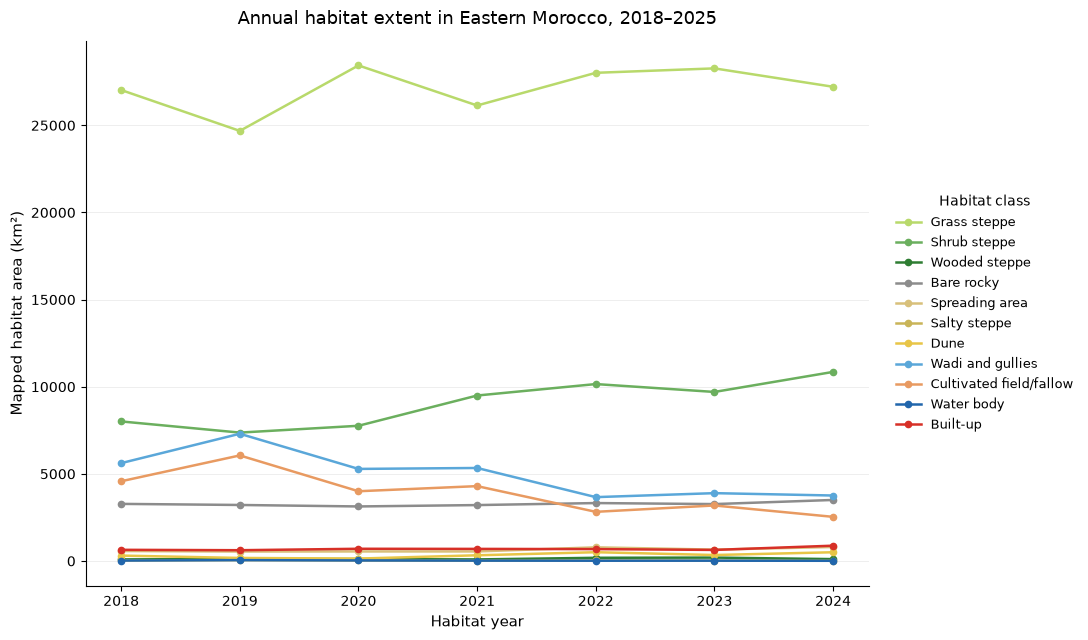

In [33]:
plot_df = plot_habitat_areas_over_years(
    area_wide,
    title=(
        "Annual habitat extent in Eastern Morocco, "
        "2018–2025"
    )
)

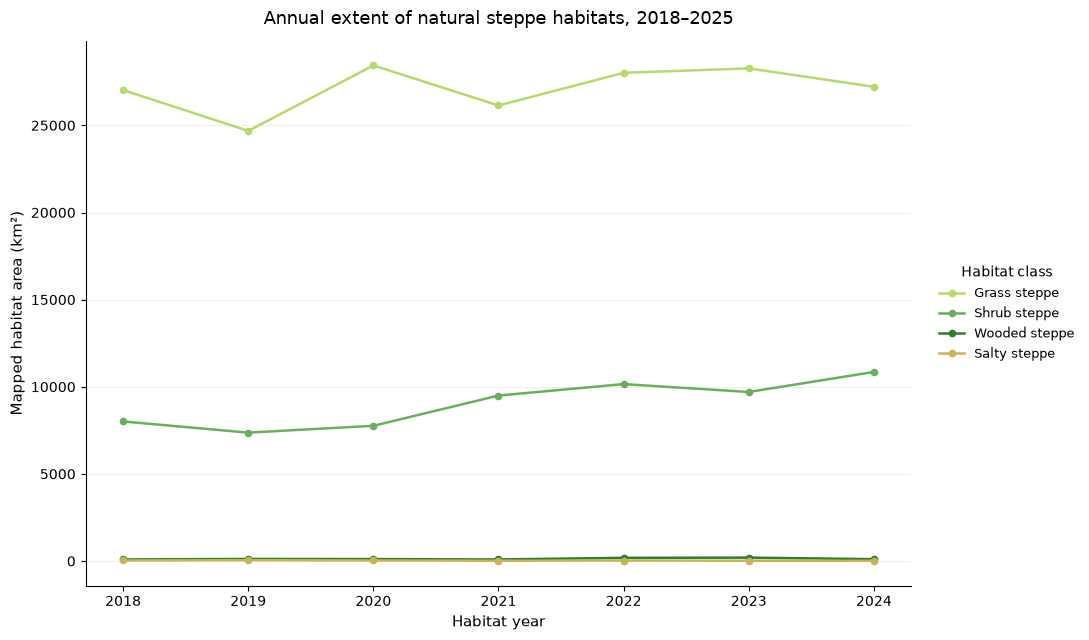

habitat,Grass steppe,Shrub steppe,Wooded steppe,Salty steppe
year,,,,
2018,27029.1995,8008.9927,89.3945,31.0002
2019,24683.0010,7368.0887,118.2685,48.7434
2020,28439.8684,7759.5856,111.7152,30.1917
2021,26141.0212,9495.9664,89.4960,16.9323
2022,28016.3707,10153.1684,183.2159,28.3404
2023,28270.8047,9701.0950,194.8046,16.5916
2024,27215.3204,10851.5368,107.7329,13.5967


In [35]:
STEPPE_CLASSES = [
    "Grass steppe",
    "Shrub steppe",
    "Wooded steppe",
    "Salty steppe",
]


plot_habitat_areas_over_years(
    area_wide,
    habitats=STEPPE_CLASSES,
    title=(
        "Annual extent of natural steppe habitats, "
        "2018–2025"
    )
)

In [36]:
# ============================================================
# Natural-steppe area summary
# ============================================================

STEPPE_CLASSES = [
    "Grass steppe",
    "Shrub steppe",
    "Wooded steppe",
    "Salty steppe",
]

steppe_df = (
    area_wide[STEPPE_CLASSES]
    .copy()
)

steppe_df["Natural steppe total"] = (
    steppe_df.sum(axis=1)
)

steppe_df["Natural steppe percent"] = (
    steppe_df["Natural steppe total"]
    / 50174.202
    * 100
)

display(
    steppe_df.round(2)
)

habitat,Grass steppe,Shrub steppe,Wooded steppe,Salty steppe,Natural steppe total,Natural steppe percent
year,,,,,,
2018,27029.20,8008.99,89.39,31.00,35158.59,70.07
2019,24683.00,7368.09,118.27,48.74,32218.10,64.21
2020,28439.87,7759.59,111.72,30.19,36341.36,72.43
2021,26141.02,9495.97,89.50,16.93,35743.42,71.24
2022,28016.37,10153.17,183.22,28.34,38381.10,76.50
2023,28270.80,9701.09,194.80,16.59,38183.30,76.10
2024,27215.32,10851.54,107.73,13.60,38188.19,76.11


In [37]:
# ============================================================
# Change relative to HY2018
# ============================================================

baseline_year = steppe_df.index.min()

baseline_area = (
    steppe_df.loc[
        baseline_year,
        "Natural steppe total"
    ]
)

steppe_df["Change_km2"] = (
    steppe_df["Natural steppe total"]
    - baseline_area
)

steppe_df["Change_pct"] = (
    steppe_df["Change_km2"]
    / baseline_area
    * 100
)

display(
    steppe_df.round(2)
)

habitat,Grass steppe,Shrub steppe,Wooded steppe,Salty steppe,Natural steppe total,Natural steppe percent,Change_km2,Change_pct
year,,,,,,,,
2018,27029.20,8008.99,89.39,31.00,35158.59,70.07,0.00,0.00
2019,24683.00,7368.09,118.27,48.74,32218.10,64.21,-2940.49,-8.36
2020,28439.87,7759.59,111.72,30.19,36341.36,72.43,1182.77,3.36
2021,26141.02,9495.97,89.50,16.93,35743.42,71.24,584.83,1.66
2022,28016.37,10153.17,183.22,28.34,38381.10,76.50,3222.51,9.17
2023,28270.80,9701.09,194.80,16.59,38183.30,76.10,3024.71,8.60
2024,27215.32,10851.54,107.73,13.60,38188.19,76.11,3029.60,8.62


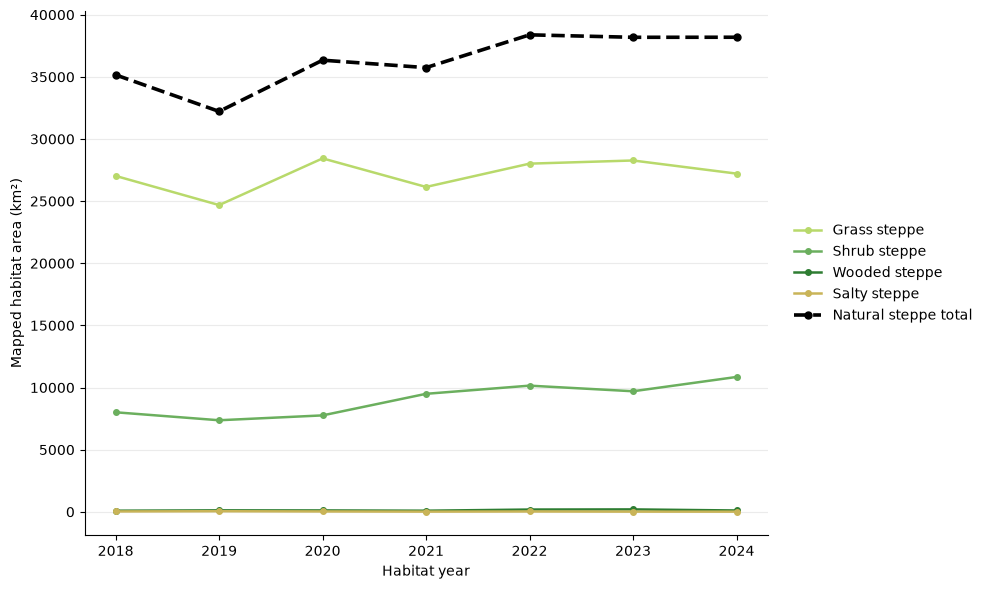

In [38]:
# ============================================================
# Plot natural-steppe habitat areas
# ============================================================

import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(10, 6)
)


for habitat in STEPPE_CLASSES:

    ax.plot(
        steppe_df.index,
        steppe_df[habitat],
        marker="o",
        linewidth=1.8,
        markersize=4,
        color=HABITAT_COLORS[habitat],
        label=habitat,
    )


# Natural-steppe total
ax.plot(
    steppe_df.index,
    steppe_df["Natural steppe total"],
    marker="o",
    linewidth=2.6,
    markersize=5,
    linestyle="--",
    color="black",
    label="Natural steppe total",
)


ax.set_xlabel(
    "Habitat year"
)

ax.set_ylabel(
    "Mapped habitat area (km²)"
)

ax.set_xticks(
    steppe_df.index
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend(
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=False,
)

plt.tight_layout()
plt.show()

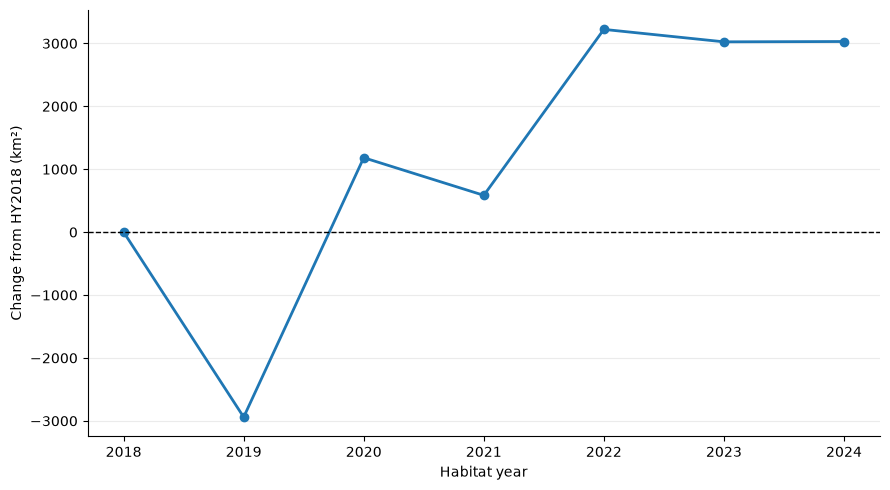

In [39]:
# ============================================================
# Plot change in natural-steppe area
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    steppe_df.index,
    steppe_df["Change_km2"],
    marker="o",
    linewidth=2,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    color="black",
)

ax.set_xlabel(
    "Habitat year"
)

ax.set_ylabel(
    f"Change from HY{baseline_year} (km²)"
)

ax.set_xticks(
    steppe_df.index
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

## Mapping

In [47]:
# ============================================================
# Reusable habitat-map plotting function
# ============================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import rasterio

from rasterio.plot import plotting_extent
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


CLASS_MAP = {
    0: "Grass steppe",
    1: "Shrub steppe",
    2: "Wooded steppe",
    3: "Bare rocky",
    4: "Spreading area",
    5: "Salty steppe",
    6: "Dune",
    7: "Wadi and gullies",
    8: "Cultivated field/fallow",
    9: "Water body",
    10: "Built-up",
}


CLASS_PALETTE = {
    0: "#B8D96B",
    1: "#6BAF5E",
    2: "#2E7D32",
    3: "#8C8C8C",
    4: "#D8C07A",
    5: "#C9B458",
    6: "#E8C547",
    7: "#5AA7D9",
    8: "#E89A61",
    9: "#2166AC",
    10: "#D73027",
}


def plot_habitat_map(
    raster_path,
    title=None,
    figsize=(11, 9),
    save_path=None,
    dpi=300,
    show_legend=True,
):
    """
    Plot a categorical habitat raster.

    Expected values:
        0-10 = habitat classes
        255  = NoData
    """

    raster_path = Path(raster_path)

    # --------------------------------------------------------
    # Categorical color map
    # --------------------------------------------------------

    colors = [
        CLASS_PALETTE[i]
        for i in range(11)
    ]

    cmap = ListedColormap(colors)

    # Make masked/NoData transparent
    cmap.set_bad(alpha=0)

    boundaries = np.arange(
        -0.5,
        11.5,
        1
    )

    norm = BoundaryNorm(
        boundaries,
        cmap.N
    )


    # --------------------------------------------------------
    # Read raster
    # --------------------------------------------------------

    with rasterio.open(raster_path) as src:

        data = src.read(
            1,
            masked=True
        )

        extent = plotting_extent(
            src
        )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=figsize
    )

    ax.imshow(
        data,
        cmap=cmap,
        norm=norm,
        extent=extent,
        interpolation="nearest"
    )


    # --------------------------------------------------------
    # Title
    # --------------------------------------------------------

    if title is None:
        title = raster_path.stem

    ax.set_title(
        title,
        fontsize=14,
        pad=10
    )


    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    if show_legend:

        handles = [
            Patch(
                facecolor=CLASS_PALETTE[i],
                edgecolor="none",
                label=CLASS_MAP[i]
            )
            for i in range(11)
        ]

        ax.legend(
            handles=handles,
            title="Habitat class",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            fontsize=9,
            title_fontsize=10,
        )


    ax.set_axis_off()

    plt.tight_layout()


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    if save_path is not None:

        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight"
        )

        print(
            "Saved:",
            save_path
        )


    plt.show()

    return fig, ax

In [50]:
masked_rasters

[WindowsPath('C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/GEE_result_map/Sentinel2_AprAug/Sentinel2_AprAug_masked/Eastern_Morocco_Habitat_S2_RF_AprAug_HY2018_T500_masked.tif'),
 WindowsPath('C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/GEE_result_map/Sentinel2_AprAug/Sentinel2_AprAug_masked/Eastern_Morocco_Habitat_S2_RF_AprAug_HY2019_T500_masked.tif'),
 WindowsPath('C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/GEE_result_map/Sentinel2_AprAug/Sentinel2_AprAug_masked/Eastern_Morocco_Habitat_S2_RF_AprAug_HY2020_T500_masked.tif'),
 WindowsPath('C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/GEE_result_map/Sentinel2_AprAug/Sentinel2_AprAug_masked/Eastern_Morocco_Habitat_S2_RF_AprAug_HY2021_T500_masked.tif'),
 WindowsPath('C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/GEE_result_map/Sentinel2_AprAug/Sentinel2_Ap

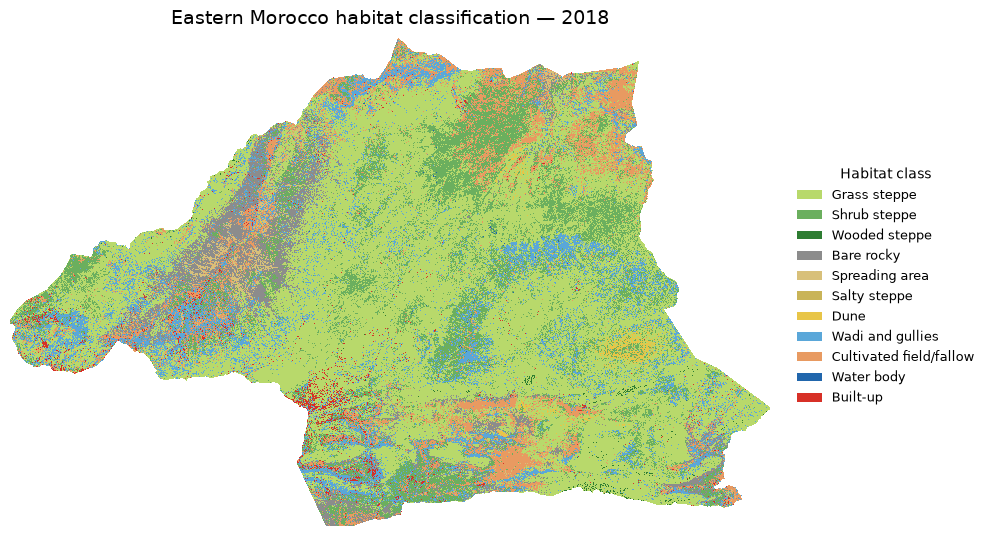

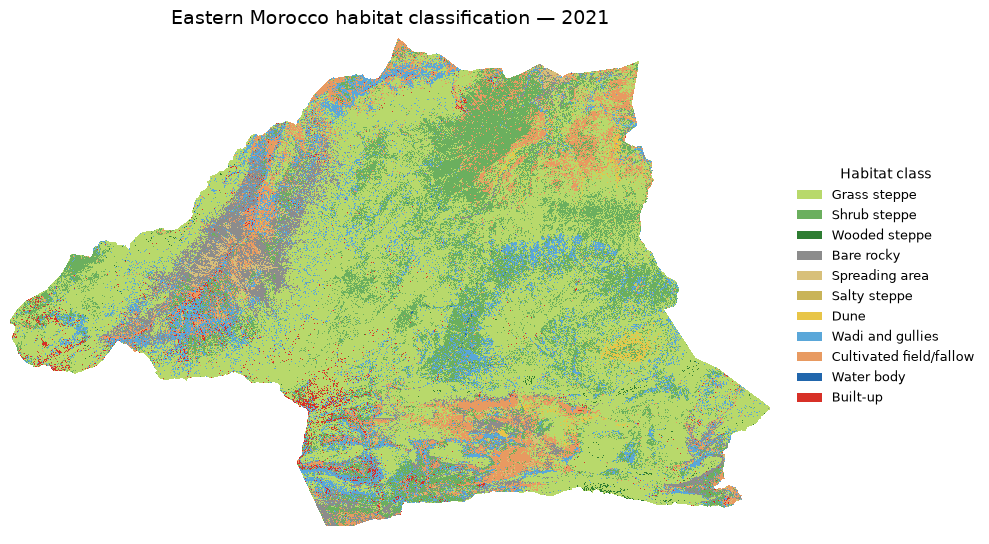

In [48]:
QC_YEARS = [
    2018,
    2021,
    2025,
]


for raster_path in masked_rasters:

    match = re.search(
        r"HY(\d{4})",
        raster_path.name
    )

    if match is None:
        continue

    year = int(
        match.group(1)
    )

    if year not in QC_YEARS:
        continue


    plot_habitat_map(
        raster_path,
        title=(
            f"Eastern Morocco habitat classification — {year}"
        ),
        figsize=(10, 8)
    )

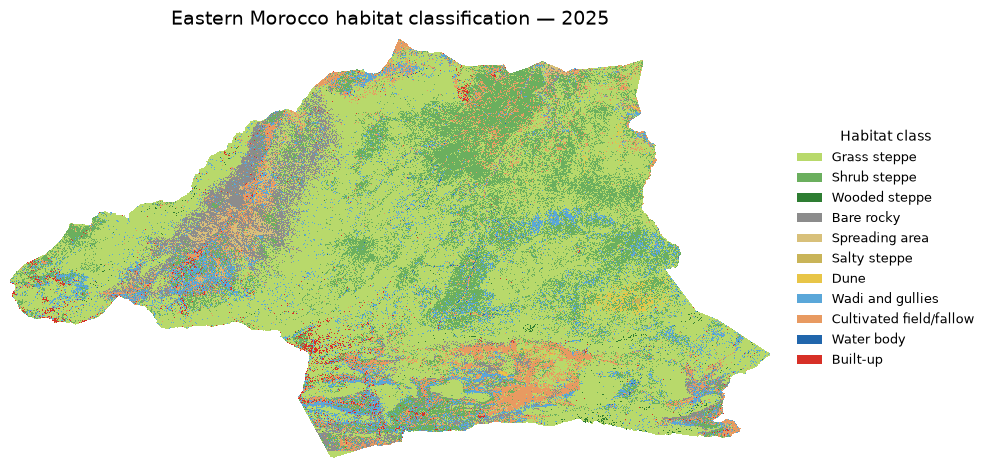

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Eastern Morocco habitat classification — 2025'}>)

In [55]:
raster_path = MASKED_DIR / "Eastern_Morocco_Habitat_RF_HY2025_masked.tif"

plot_habitat_map(
        raster_path,
        title=(
            f"Eastern Morocco habitat classification — 2025"
        ),
        figsize=(10, 8)
    )

# Change detection

```Text
                   ANNUAL HABITAT MAPS
                   2008–2025
                         │
        ┌────────────────┴─────────────────┐
        │                                  │
Categorical dynamics               Spectral dynamics
        │                                  │
extent                             LandTrendr
transitions                        breakpoint year
persistence                        magnitude
fragmentation                      duration
        │                          recovery
        └────────────────┬─────────────────┘
                         │
                Persistent change
                         │
              Anthropogenic pressure
              + climate + topography